# XGB Predictions -> Clustering

Este notebook carrega CSVs gerados pelo notebook de XGBoost (ex: `xgb_test_with_proba_10.csv` ou `xgb_train_with_proba_10.csv`) e executa clustering (Kmedoids) sobre as features/probabilidades selecionadas.
- Ajuste os caminhos de entrada na célula de parâmetros.
- Saídas: `databases/STROKE/clusters_reports/xgboost/` (csv, images, pdf).

In [ ]:
# Configuração - EDITE AQUI para apontar os arquivos desejados

from pathlib import Path
# caminhos de exemplo (substitua conforme necessário)
CSV_TEST_PATH  = Path('/scratch2/helton.oliveira/master.v2../STROKE/model_reports/xgboost/basico/csv/X_test_basic_full.csv')
CSV_TRAIN_PATH = Path('/scratch2/helton.oliveira/master.v2../STROKE/model_reports/xgboost/basico/csv/X_train_basic_full.csv')

# datasets de entrada 
X_TRAIN        = None #Dados brutos de Treino
X_TEST         = None #Dados brutos de Test
X_TRAIN_NORM   = None #Dados NORMALIZADOS de Treino
X_TEST_NORM    = None #Dados NORMALIZADOS de Test
DF_GLOBAL       = None #Dados brutos Globais
DF_GLOBAL_NORM  = None #Dados NORMALIZADOS Globais
DF_GLOBAL_C0       = None #Dados brutos Globais C0
DF_GLOBAL_C1       = None #Dados brutos Globais C1
DF_GLOBAL_NORM_C0  = None #Dados NORMALIZADOS Globais  C0
DF_GLOBAL_NORM_C1  = None #Dados NORMALIZADOS Globais  C1

# Saídas
OUT_BASE = Path('../clusters_reports/xgboost')
OUT_CSV = OUT_BASE / 'csv'
OUT_IMG = OUT_BASE / 'images'
OUT_PDF = OUT_BASE / 'pdf'

for d in [OUT_BASE, OUT_CSV, OUT_IMG, OUT_PDF]:
    d.mkdir(parents=True, exist_ok=True)

# Parâmetros de clustering
RANDOM_STATE = 42   
N_CLUSTERS_ELBOW = {0:5, 1:3}
N_CLUSTERS_ELBOW_RECOMENDED = None
N_CLUSTERS = {0:5, 1:3} # Numero de clusters definido por classe (0 e 1)
N_CLUSTERS_SILHUET = None
SILHUET = N_CLUSTERS # Informe aqui a definição da quantidade de clusters por classe e utilize SILHUET como padrao no codigo 
THRESHOLD = 0.5
DPI = 800
# Colunas que NÃO devem entrar como features (serão sempre excluídas das features de clustering/PCA)
EXCLUDE_COLUMNS = ['__cls_tmp__', 'y', 'orig_index', 'diagnosis','id', 'ID', 'patient_id', 'pid', 'fold', 'y_train', 'prob_0', 'prob_1', 'y_proba', 'y_pred']
TARGET_COLUMN = 'y_pred'  # ajustar se necessário
DATASET_NORMALIZED = False  # se False, assume que os dados estão em escala original (não normalizados)  
NORMALIZED_METHOD = 'robust scale'  # 'minmax' ou 'standard scale', robust scale 
DISCRETIZE_VARIABLES = {'stroke': {0:0, 1:1}}  # exemplo de mapeamento

# Removido controle de inclusão das EXCLUDE_COLUMNS: elas nunca participarão das features.
PRINT_FEATURE_SELECTION = True  # exibir listas de colunas usadas/retiradas

print('CSV_TEST_PATH exists:', CSV_TEST_PATH.exists(), 'CSV_TRAIN_PATH exists:', CSV_TRAIN_PATH.exists())


CSV_TEST_PATH exists: True CSV_TRAIN_PATH exists: True


In [2]:
# Carregar CSV_TEST_PATH e CSV_TRAIN_PATH, normalizar se necessário, salvar arquivos normalizados e global no diretório configurado
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
import os
from pathlib import Path

# Função para normalizar um DataFrame, exceto colunas excluídas
def normalize_df(df, exclude_columns, method):
    cols_to_normalize = [col for col in df.columns if col not in exclude_columns and pd.api.types.is_numeric_dtype(df[col])]
    if method.lower() in ['standard scale','standard','standardscale','zscore','z-score']:
        scaler = StandardScaler()
    elif method.lower() in ['minmax','min-max','minmaxscale']:
        scaler = MinMaxScaler()
    elif method.lower() in ['robust','robust scale','robustscale']:
        scaler = RobustScaler()
    else:
        raise ValueError(f"Método de normalização desconhecido: {method}")
    df_NORM = df.copy()
    if cols_to_normalize:
        df_NORM[cols_to_normalize] = scaler.fit_transform(df[cols_to_normalize])
    return df_NORM

# Helper para converter Path/str
def to_str(x):
    return str(x) if not isinstance(x, str) else x

CSV_TEST_PATH  = to_str(CSV_TEST_PATH)
CSV_TRAIN_PATH = to_str(CSV_TRAIN_PATH)

# Diretório de saída para CSVs
out_csv_dir = Path(OUT_CSV) if 'OUT_CSV' in globals() else Path('./')
out_csv_dir.mkdir(parents=True, exist_ok=True)

# Carregar datasets (mantém colunas originais)
X_TEST = pd.read_csv(CSV_TEST_PATH , index_col=0)
X_TRAIN = pd.read_csv(CSV_TRAIN_PATH, index_col=0)

# Normalização condicional
if not DATASET_NORMALIZED:
    X_TEST_NORM = normalize_df(X_TEST, EXCLUDE_COLUMNS, NORMALIZED_METHOD)
    X_TRAIN_NORM = normalize_df(X_TRAIN, EXCLUDE_COLUMNS, NORMALIZED_METHOD)
else:
    X_TEST_NORM = X_TEST.copy()
    X_TRAIN_NORM = X_TRAIN.copy()

# Garantir que variáveis em DISCRETIZE_VARIABLES estejam numéricas (pelo menos normalizadas se forem numéricas)
if isinstance(DISCRETIZE_VARIABLES, dict):
    discretize_vars = list(DISCRETIZE_VARIABLES.keys())
else:
    discretize_vars = list(DISCRETIZE_VARIABLES) if DISCRETIZE_VARIABLES is not None else []

for var in discretize_vars:
    if var in X_TEST_NORM.columns and not np.issubdtype(X_TEST_NORM[var].dtype, np.number):
        # Tentativa: se categórica, aplicar codificação simples (factorize) antes de escalar
        codes, _ = pd.factorize(X_TEST_NORM[var])
        X_TEST_NORM[var] = codes.astype(float)
    if var in X_TRAIN_NORM.columns and not np.issubdtype(X_TRAIN_NORM[var].dtype, np.number):
        codes, _ = pd.factorize(X_TRAIN_NORM[var])
        X_TRAIN_NORM[var] = codes.astype(float)

# Reaplicar normalização apenas nessas variáveis discretizadas recém numéricas se dataset não era normalizado
if not DATASET_NORMALIZED and discretize_vars:
    inter_test = X_TEST_NORM[discretize_vars]
    inter_train = X_TRAIN_NORM[discretize_vars]
    # Escalar somente as discretize vars que não estão excluídas
    vars_to_scale = [v for v in discretize_vars if v not in EXCLUDE_COLUMNS and v in X_TEST_NORM.columns]
    if vars_to_scale:
        # Escolher scaler consistente com método
        if NORMALIZED_METHOD.lower() in ['standard scale','standard','standardscale','zscore','z-score']:
            scaler2 = StandardScaler()
        elif NORMALIZED_METHOD.lower() in ['minmax','min-max','minmaxscale']:
            scaler2 = MinMaxScaler()
        elif NORMALIZED_METHOD.lower() in ['robust','robust scale','robustscale']:
            scaler2 = RobustScaler()
        else:
            raise ValueError(f"Método de normalização desconhecido: {NORMALIZED_METHOD}")
        X_TRAIN_NORM[vars_to_scale] = scaler2.fit_transform(X_TRAIN_NORM[vars_to_scale])
        X_TEST_NORM[vars_to_scale] = scaler2.transform(X_TEST_NORM[vars_to_scale])

# Construir caminhos de saída
CSV_TEST_NORMALIZED = out_csv_dir / 'csv_teste_normalizado.csv'
CSV_TRAIN_NORMALIZED = out_csv_dir / 'csv_train_normalizado.csv'
CSV_GLOBAL_NORMALIZED = out_csv_dir / 'csv_global_normalizado.csv'
CSV_GLOBAL            = out_csv_dir / 'csv_global_cru.csv'

# Salvar arquivos
X_TEST_NORM.to_csv(CSV_TEST_NORMALIZED, index=False)
X_TRAIN_NORM.to_csv(CSV_TRAIN_NORMALIZED, index=False)
DF_GLOBAL_NORM = pd.concat([X_TRAIN_NORM, X_TEST_NORM], axis=0, ignore_index=True)
DF_GLOBAL_NORM.to_csv(CSV_GLOBAL_NORMALIZED, index=False)
DF_GLOBAL = pd.concat([X_TRAIN, X_TEST], axis=0, ignore_index=True)
DF_GLOBAL.to_csv(CSV_GLOBAL, index=False)

print('Arquivos normalizados salvos:')
print('  Teste Normalizado :', CSV_TEST_NORMALIZED)
print('  Treino Normalizado:', CSV_TRAIN_NORMALIZED)
print('  Global Normalizado:', CSV_GLOBAL_NORMALIZED)
print('  Global Cru:', CSV_GLOBAL)

Arquivos normalizados salvos:
  Teste Normalizado : ../clusters_reports/xgboost/csv/csv_teste_normalizado.csv
  Treino Normalizado: ../clusters_reports/xgboost/csv/csv_train_normalizado.csv
  Global Normalizado: ../clusters_reports/xgboost/csv/csv_global_normalizado.csv
  Global Cru: ../clusters_reports/xgboost/csv/csv_global_cru.csv


In [3]:
# Geração de arquivos por classe predita (TARGET_COLUMN) usando dataset GLOBAL NORMALIZADO
import pandas as pd
from pathlib import Path

# 1. Garantir diretório de saída
out_csv_dir = Path(OUT_CSV) if 'OUT_CSV' in globals() else Path('./')
out_csv_dir.mkdir(parents=True, exist_ok=True)

# 2. Garantir DF_GLOBAL_NORM carregado (preferir CSV_GLOBAL_NORMALIZED)
if 'DF_GLOBAL_NORM' not in globals():
    loaded = False
    if 'CSV_GLOBAL_NORMALIZED' in globals():
        try:
            DF_GLOBAL_NORM = pd.read_csv(CSV_GLOBAL_NORMALIZED)
            print(f'DF_GLOBAL_NORM carregado de CSV_GLOBAL_NORMALIZED: {CSV_GLOBAL_NORMALIZED}')
            loaded = True
        except Exception as e:
            print(f'Falha ao carregar CSV_GLOBAL_NORMALIZED ({CSV_GLOBAL_NORMALIZED}): {e}')
    if not loaded:
        # fallback: tentar concatenar train/test normalizados
        try:
            if 'CSV_TRAIN_NORMALIZED' in globals() and 'CSV_TEST_NORMALIZED' in globals():
                df_train_tmp = pd.read_csv(CSV_TRAIN_NORMALIZED)
                df_test_tmp = pd.read_csv(CSV_TEST_NORMALIZED)
                DF_GLOBAL_NORM = pd.concat([df_train_tmp, df_test_tmp], axis=0, ignore_index=True)
                print('DF_GLOBAL_NORM reconstruído via concat train/test normalizados.')
                loaded = True
        except Exception as e:
            print('Falha ao reconstruir via concat train/test:', e)
    if not loaded:
        raise RuntimeError('Não foi possível obter DF_GLOBAL_NORM (nem arquivo global nem concat).')

# 3. Validar TARGET_COLUMN
if TARGET_COLUMN not in DF_GLOBAL_NORM.columns:
    raise KeyError(f"TARGET_COLUMN '{TARGET_COLUMN}' não existe em DF_GLOBAL_NORM. Colunas disponíveis: {list(DF_GLOBAL_NORM.columns)}")

# 4. Listar classes
values = DF_GLOBAL_NORM[TARGET_COLUMN].dropna().unique()
print(f'Classes encontradas em {TARGET_COLUMN}:', values)

# 5. Gerar arquivos por classe
summary_rows = []  # irá acumular {'class_value','n_rows','path'}
per_class_paths = {}
for val in values:
    subset = DF_GLOBAL_NORM[DF_GLOBAL_NORM[TARGET_COLUMN] == val]
    # Nome de arquivo seguro
    safe_val = str(val).replace('/','_').replace(' ','_')
    out_path = out_csv_dir / f'xgb_predictions_final_{TARGET_COLUMN}_{safe_val}.csv'
    subset.to_csv(out_path, index=False)
    per_class_paths[val] = out_path
    summary_rows.append({'class_value': val, 'n_rows': int(len(subset)), 'path': str(out_path)})
    print(f'Salvo arquivo classe={val} linhas={len(subset)} -> {out_path}')

# Carrega os dados normalizados em DF_GLOBAL_NORM_C0 , DF_GLOBAL_NORM_C1
for val in values:
    safe_val = str(val).replace('/', '_').replace(' ', '_')
    out_path = out_csv_dir / f'xgb_predictions_final_{TARGET_COLUMN}_{safe_val}.csv'
    globals()[f"DF_GLOBAL_NORM_C{safe_val}"] = pd.read_csv(out_path, index_col=0)

# Carrega os dados cru em DF_GLOBAL_C0 , DF_GLOBAL_C1
for val in values:
    # Cria DF_GLOBAL_C{val} dinamicamente (ex.: DF_GLOBAL_C0, DF_GLOBAL_C1)
    mask = DF_GLOBAL[TARGET_COLUMN].astype(int) == int(val)
    globals()[f"DF_GLOBAL_C{int(val)}"] = DF_GLOBAL[mask].copy()

# 6. Salvar resumo
if summary_rows:
    summary_df = pd.DataFrame(summary_rows).sort_values('class_value').reset_index(drop=True)
else:
    summary_df = pd.DataFrame(columns=['class_value','n_rows','path'])
summary_file = out_csv_dir / f'xgb_predictions_final_{TARGET_COLUMN}_summary.csv'
summary_df.to_csv(summary_file, index=False)
print('Resumo salvo em:', summary_file)

# 7. Expor variáveis auxiliares para células posteriores
XGB_PER_CLASS_PATHS = per_class_paths
XGB_PER_CLASS_SUMMARY_FILE = summary_file
XGB_PER_CLASS_SUMMARY_DF = summary_df
summary_df.head()

Classes encontradas em y_pred: [1 0]
Salvo arquivo classe=1 linhas=209 -> ../clusters_reports/xgboost/csv/xgb_predictions_final_y_pred_1.csv
Salvo arquivo classe=0 linhas=360 -> ../clusters_reports/xgboost/csv/xgb_predictions_final_y_pred_0.csv
Resumo salvo em: ../clusters_reports/xgboost/csv/xgb_predictions_final_y_pred_summary.csv


,class_value,n_rows,path
0,0,360,../clusters_reports/xgboost/csv/xgb_prediction...
1,1,209,../clusters_reports/xgboost/csv/xgb_prediction...


In [7]:
# ==== Análise Elbow: clusters por Elbow (usuário e recomendado) ====
# Este bloco é SOMENTE ELBOW (sem silhueta).
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances
from sklearn_extra.cluster import KMedoids

RESULTS_DIR = str(OUT_CSV)
IMG_DIR = str(OUT_IMG) if 'OUT_IMG' in globals() else os.path.join(RESULTS_DIR, 'images')
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(IMG_DIR, exist_ok=True)

# ---------- util ----------
def run_kmedoids_exemplars(X, k, metric="euclidean", random_state=0):
    if len(X) < 3 or k is None or k < 2 or k > len(X) - 1:
        return np.array([]), np.array([]), np.nan, None
    model = KMedoids(n_clusters=int(k), metric=metric, random_state=random_state)
    labels = model.fit_predict(X)
    meds = model.medoid_indices_
    cost = getattr(model, "inertia_", np.nan)
    return meds, labels, float(cost), model

def compute_elbow_df(X, k_min=2, k_max=15, metric="euclidean", random_state=0):
    n = len(X)
    if n < 3:
        return pd.DataFrame(columns=["k", "cost", "sse"])
    k_min_eff = max(2, int(k_min))
    k_max_eff = min(int(k_max), n - 1)
    rows = []
    for k in range(k_min_eff, k_max_eff + 1):
        meds, labels, cost, model = run_kmedoids_exemplars(X, k, metric=metric, random_state=random_state)
        if meds.size == 0:
            continue
        Dist = pairwise_distances(X, X[meds], metric=metric)
        min_dist_sq = (np.min(Dist, axis=1) ** 2).sum()
        rows.append({"k": k, "cost": cost, "sse": float(min_dist_sq)})
    return pd.DataFrame(rows)

def recommend_k_elbow(df_costs, y_col="sse"):
    if df_costs is None or df_costs.empty or y_col not in df_costs.columns:
        return {"recommended": None, "details": None}
    df_costs = df_costs.dropna(subset=["k", y_col])
    if df_costs.empty or df_costs.shape[0] < 3:
        return {"recommended": None, "details": None}
    df_costs = df_costs.sort_values("k")
    ks = df_costs["k"].to_numpy()
    yy = df_costs[y_col].to_numpy(dtype=float)
    max_dist = -1
    best_k = None
    for k, y in zip(ks[1:-1], yy[1:-1]):
        idx = np.where(ks == k)[0][0]
        x1 = ks[0]; y1 = yy[0]
        x2 = ks[-1]; y2 = yy[-1]
        num = abs((y2 - y1) * k - (x2 - x1) * y + x2 * y1 - y2 * x1)
        den = np.sqrt((y2 - y1) ** 2 + (x2 - x1) ** 2)
        dist = num / den if den else 0
        if dist > max_dist:
            max_dist = dist
            best_k = k
    return {"recommended": int(best_k) if best_k is not None else None, "details": df_costs}
# ========= Preparação dos dados =========
if 'DF_GLOBAL_NORM' not in globals() or DF_GLOBAL_NORM is None:
    raise RuntimeError("DF_GLOBAL_NORM não encontrado. Execute a célula de carregamento/normalização primeiro.")

available_columns = set(DF_GLOBAL_NORM.columns)
missing_columns = sorted(set(EXCLUDE_COLUMNS) - available_columns)
if missing_columns:
    warnings.warn(
        f"As colunas ausentes {missing_columns} foram removidas da análise de clusters.",
        RuntimeWarning,
        stacklevel=2
    )
cluster_columns = [col for col in EXCLUDE_COLUMNS if col in available_columns]
if not cluster_columns:
    raise KeyError("Nenhuma coluna válida disponível em DF_GLOBAL_NORM para EXCLUDE_COLUMNS.")

X0_np = DF_GLOBAL_NORM.loc[DF_GLOBAL_NORM[TARGET_COLUMN] == 0, cluster_columns].to_numpy()
X1_np = DF_GLOBAL_NORM.loc[DF_GLOBAL_NORM[TARGET_COLUMN] == 1, cluster_columns].to_numpy()

k0_user = N_CLUSTERS.get(0, None) if isinstance(N_CLUSTERS, dict) else None
k1_user = N_CLUSTERS.get(1, None) if isinstance(N_CLUSTERS, dict) else None

silhouette_kwargs = dict(metric="euclidean", random_state=RANDOM_STATE)

df_sil0_var = compute_elbow_df(X0_np, k_min=2, k_max=12, **silhouette_kwargs) if X0_np.size else pd.DataFrame()
df_sil1_var = compute_elbow_df(X1_np, k_min=2, k_max=12, **silhouette_kwargs) if X1_np.size else pd.DataFrame()

rec0 = recommend_k_elbow(df_sil0_var) if not df_sil0_var.empty else {"recommended": None}
rec1 = recommend_k_elbow(df_sil1_var) if not df_sil1_var.empty else {"recommended": None}
k0_best = rec0.get("recommended")
k1_best = rec1.get("recommended")

labels0_best = np.array([])
labels1_best = np.array([])
labels0_user = np.array([])
labels1_user = np.array([])

if X0_np.size and k0_best is not None:
    _, labels0_best, _, _ = run_kmedoids_exemplars(X0_np, k0_best, **silhouette_kwargs)
if X1_np.size and k1_best is not None:
    _, labels1_best, _, _ = run_kmedoids_exemplars(X1_np, k1_best, **silhouette_kwargs)
if X0_np.size and k0_user is not None:
    _, labels0_user, _, _ = run_kmedoids_exemplars(X0_np, k0_user, **silhouette_kwargs)
if X1_np.size and k1_user is not None:
    _, labels1_user, _, _ = run_kmedoids_exemplars(X1_np, k1_user, **silhouette_kwargs)

def _resumo_classe_silhouette(class_id, X_np, labels_usados, k_usado, k_sugerido, df_curve):
    if labels_usados.size == 0:
        return {
            "classe": class_id,
            "k_usado": k_usado,
            "silhueta_usada": np.nan,
            "silhueta_sugerida": np.nan,
            "k_sugerido": k_sugerido
        }
    from sklearn.metrics import silhouette_score
    sil_usado = silhouette_score(X_np, labels_usados, metric="euclidean")
    if df_curve is not None and not df_curve.empty:
        df_curve = df_curve.sort_values('k')
        row = df_curve[df_curve['k'] == k_sugerido]
        sil_sugerido = row["sse"].iloc[0] if not row.empty else np.nan
    else:
        sil_sugerido = np.nan
    return {
        "classe": class_id,
        "k_usado": k_usado,
        "silhueta_usada": sil_usado,
        "silhueta_sugerida": sil_sugerido,
        "k_sugerido": k_sugerido
    }

res_l_best = []
res_l_user = []

if X0_np.size:
    res_l_best.append(_resumo_classe_silhouette(0, X0_np, labels0_best, k0_best, k0_best, df_sil0_var))
    res_l_user.append(_resumo_classe_silhouette(0, X0_np, labels0_user, k0_user, k0_best, df_sil0_var))

if X1_np.size:
    res_l_best.append(_resumo_classe_silhouette(1, X1_np, labels1_best, k1_best, k1_best, df_sil1_var))
    res_l_user.append(_resumo_classe_silhouette(1, X1_np, labels1_user, k1_user, k1_best, df_sil1_var))

df_resumo_silhueta_best = pd.DataFrame(res_l_best)
df_resumo_silhueta_user = pd.DataFrame(res_l_user)

if not df_resumo_silhueta_user.empty:
    def _perc_diff(row):
        su = row.get('silhueta_usada', np.nan)
        ss = row.get('silhueta_sugerida', np.nan)
        if ss is None or np.isnan(ss) or ss == 0:
            return np.nan
        return 100.0 * (su - ss) / ss
    df_resumo_silhueta_user['perc_diff_silhueta_usada_vs_sugerida'] = df_resumo_silhueta_user.apply(_perc_diff, axis=1)

df_resumo_silhueta = pd.concat([
    df_resumo_silhueta_best.assign(tipo='recomendado'),
    df_resumo_silhueta_user.assign(tipo='usuario')
], ignore_index=True)

if not df_resumo_silhueta_best.empty:
    df_resumo_silhueta_best.to_csv(os.path.join(RESULTS_DIR, 'resumo_silhueta_usado_vs_sugerido_recomendado.csv'), index=False, encoding='utf-8')
if not df_resumo_silhueta_user.empty:
    df_resumo_silhueta_user.to_csv(os.path.join(RESULTS_DIR, 'resumo_silhueta_usado_vs_sugerido_usuario.csv'), index=False, encoding='utf-8')
if not df_resumo_silhueta.empty:
    df_resumo_silhueta.to_csv(os.path.join(RESULTS_DIR, 'resumo_silhueta_usado_vs_sugerido.csv'), index=False, encoding='utf-8')

if 'display' in globals():
    if not df_resumo_silhueta_best.empty:
        display(df_resumo_silhueta_best)
    if not df_resumo_silhueta_user.empty:
        display(df_resumo_silhueta_user)

/home/pos/helton.oliveira/miniconda3/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3699: RuntimeWarning: As colunas ausentes ['ID', '__cls_tmp__', 'fold', 'orig_index', 'patient_id', 'pid', 'prob_0', 'prob_1', 'y_train'] foram removidas da análise de clusters.
  exec(code_obj, self.user_global_ns, self.user_ns)


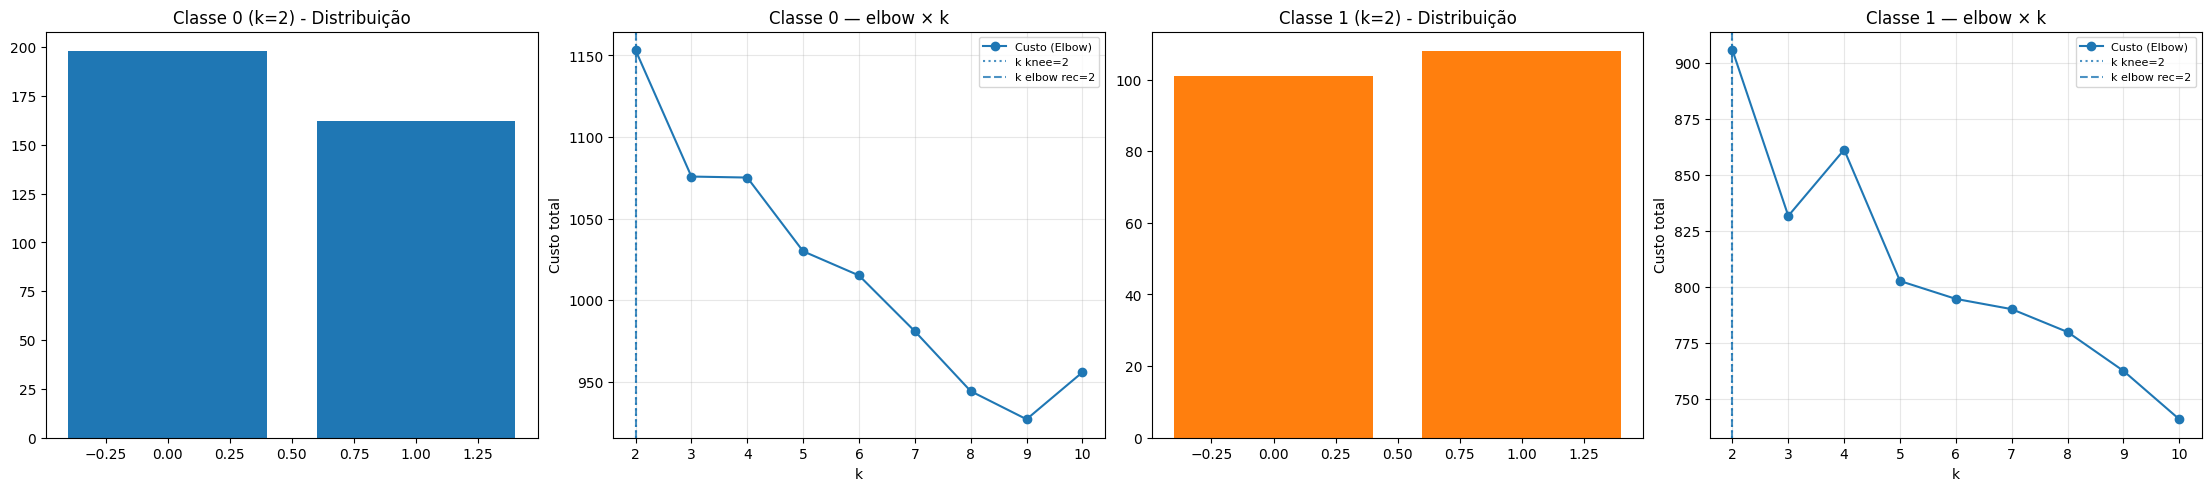

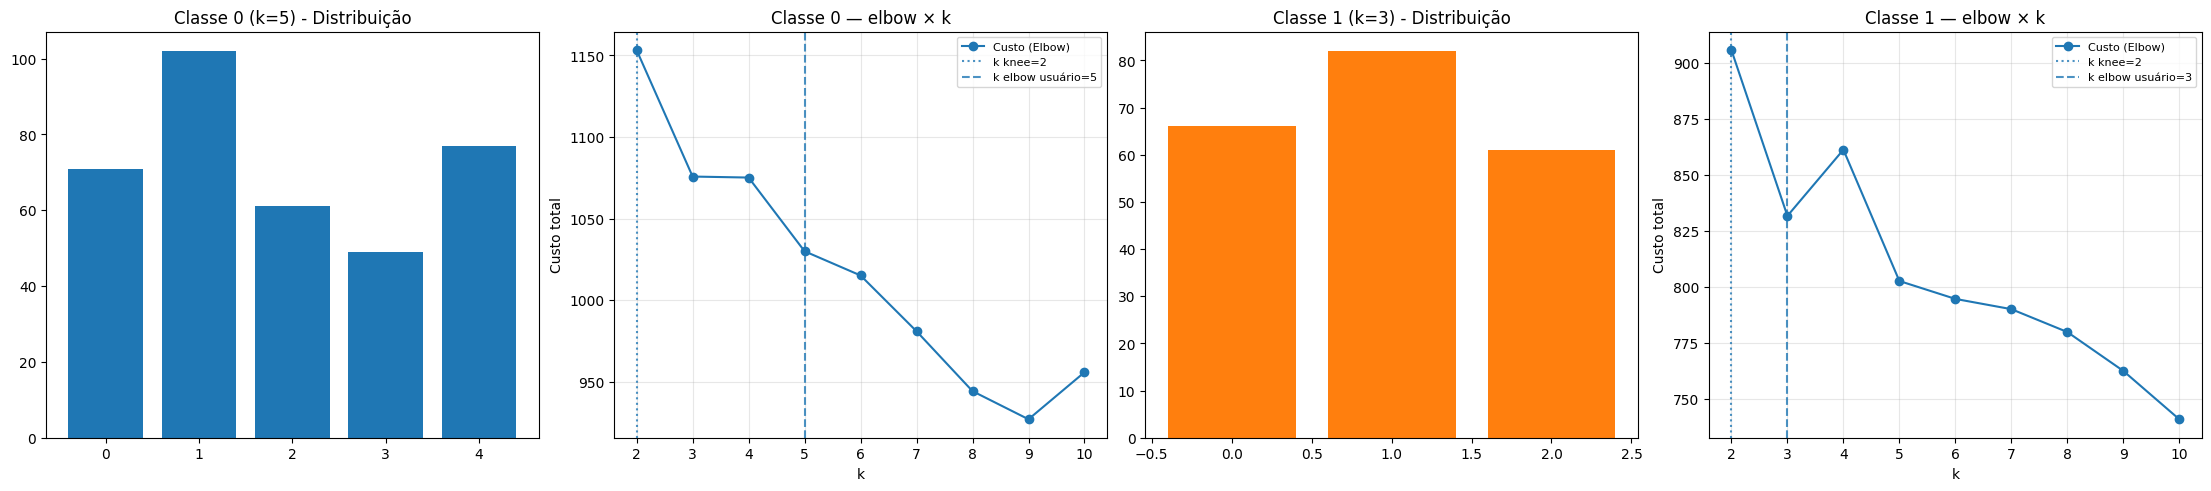

In [8]:
# ==== Análise Elbow: clusters por Elbow (usuário e recomendado) ====
# Este bloco é SOMENTE ELBOW (sem silhueta).
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances
from sklearn_extra.cluster import KMedoids

RESULTS_DIR = str(OUT_CSV)
IMG_DIR = str(OUT_IMG) if 'OUT_IMG' in globals() else os.path.join(RESULTS_DIR, 'images')
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(IMG_DIR, exist_ok=True)

# ---------- util ----------
def run_kmedoids_exemplars(X, k, metric="euclidean", random_state=0):
    if len(X) < 3 or k is None or k < 2 or k > len(X) - 1:
        return np.array([]), np.array([]), np.nan, None
    model = KMedoids(n_clusters=int(k), metric=metric, random_state=random_state)
    labels = model.fit_predict(X)
    meds = model.medoid_indices_
    cost = getattr(model, "inertia_", np.nan)
    return meds, labels, float(cost), model

def compute_elbow_df(X, k_min=2, k_max=15, metric="euclidean", random_state=0):
    n = len(X)
    if n < 3:
        return pd.DataFrame(columns=["k", "cost", "sse"])
    k_min_eff = max(2, int(k_min))
    k_max_eff = min(int(k_max), n - 1)
    if k_min_eff > k_max_eff:
        return pd.DataFrame(columns=["k", "cost", "sse"])
    rows = []
    for k in range(k_min_eff, k_max_eff + 1):
        meds, labels, cost, _ = run_kmedoids_exemplars(X, k, metric=metric, random_state=random_state)
        if metric == "euclidean" and labels.size and np.size(meds) > 0:
            D = pairwise_distances(X, X[meds], metric=metric)
            sse = float(np.sum((D[np.arange(len(X)), labels]) ** 2))
        else:
            sse = np.nan
        rows.append({"k": int(k), "cost": cost, "sse": sse})
    return pd.DataFrame(rows)

def _knee_point_k(df, y_col="cost"):
    if df is None or df.empty or df.shape[0] < 3:
        return None
    xs = df["k"].to_numpy(dtype=float)
    ys = df[y_col].to_numpy(dtype=float)
    x0, x1 = xs.min(), xs.max()
    y0, y1 = np.nanmin(ys), np.nanmax(ys)
    if x1 == x0 or not np.isfinite(y0) or not np.isfinite(y1) or y1 == y0:
        return None
    xn = (xs - x0) / (x1 - x0)
    yn = (ys - y0) / (y1 - y0)
    a = np.array([0.0, 0.0]); b = np.array([1.0, 1.0])
    ba = b - a
    ba_norm = np.linalg.norm(ba)
    pts = np.stack([xn, yn], axis=1)
    cross = np.abs(pts[:, 0] * ba[1] - pts[:, 1] * ba[0])
    dists = cross / (ba_norm + 1e-12)
    idx = int(np.nanargmax(dists))
    return int(xs[idx])

def recommend_k_elbow(df, y_col="cost", low_gain_alpha=0.5):
    if df is None or df.empty:
        return {"k_knee": None, "k_lowgain": None, "recommended": None}
    k_knee = _knee_point_k(df, y_col=y_col)
    ks = df["k"].to_numpy()
    ys = df[y_col].to_numpy(dtype=float)
    gains = -np.diff(ys)
    ks_g = ks[1:]
    if gains.size > 0 and np.isfinite(np.nanmean(gains)):
        mean_gain = np.nanmean(gains)
        thresh = low_gain_alpha * mean_gain
        idxs = np.where(gains < thresh)[0]
        k_lowgain = int(ks_g[idxs[0]]) if idxs.size > 0 else None
    else:
        k_lowgain = None
    if k_knee is not None:
        k_rec = k_knee
    elif k_lowgain is not None:
        k_rec = k_lowgain
    else:
        k_rec = int(ks[-1])
    return {"k_knee": k_knee, "k_lowgain": k_lowgain, "recommended": k_rec}

def plot_elbow_vs_k_axis(ax, df, titulo, k_line=None, line_label="k usado"):
    if df is None or df.empty:
        ax.text(0.5, 0.5, "Sem dados suficientes", ha="center", va="center")
        ax.set_axis_off()
        return
    ax.plot(df["k"], df["cost"], marker="o", label="Custo (Elbow)")
    ax.set_title(titulo)
    ax.set_xlabel("k")
    ax.set_ylabel("Custo total")
    ax.grid(alpha=0.3)
    k_star = _knee_point_k(df, y_col="cost")
    if k_star is not None:
        ax.axvline(k_star, linestyle=":", alpha=0.8, label=f"k knee={k_star}")
    if k_line is not None:
        ax.axvline(int(k_line), linestyle="--", alpha=0.8, label=f"{line_label}={k_line}")
    ax.set_xticks(df["k"].tolist())
    ax.legend(fontsize=8)

def plot_elbow_1x4(
    labels0, k0_show,
    labels1, k1_show,
    df_elb0_var, df_elb1_var,
    fname="elbow_1x4.png",
    k_line0=None, k_line1=None, line_label="k usado"
    ):
    fig, axes = plt.subplots(1, 4, figsize=(22, 4.8), constrained_layout=True)
    ax0, ax1, ax2, ax3 = axes
    ax0.hist(labels0, bins=np.arange(k0_show + 1) - 0.5, rwidth=0.8)
    ax0.set_title(f"Classe 0 (k={k0_show}) - Distribuição")
    plot_elbow_vs_k_axis(ax1, df_elb0_var, "Classe 0 — elbow × k", k_line=k_line0, line_label=line_label)
    ax2.hist(labels1, bins=np.arange(k1_show + 1) - 0.5, color="tab:orange", rwidth=0.8)
    ax2.set_title(f"Classe 1 (k={k1_show}) - Distribuição")
    plot_elbow_vs_k_axis(ax3, df_elb1_var, "Classe 1 — elbow × k", k_line=k_line1, line_label=line_label)
    fig.savefig(os.path.join(IMG_DIR, fname), dpi=150, bbox_inches="tight", pad_inches=0)
    plt.show()

def _sanitize_k(X_np, k_desired):
    n = len(X_np)
    if n < 3 or k_desired is None:
        return None
    return max(2, min(int(k_desired), n - 1))

def _cluster_counts(labels, k):
    labels = np.asarray(labels).ravel()
    if labels.size == 0 or k is None:
        return []
    return [int(x) for x in np.bincount(labels.astype(int), minlength=int(k))[:int(k)]]

def _cost_at_k(df_elb_var: pd.DataFrame, k: int):
    if df_elb_var is None or df_elb_var.empty or k is None:
        return np.nan
    row = df_elb_var.loc[df_elb_var["k"] == int(k), "cost"]
    if row.empty:
        return np.nan
    return float(row.iloc[0])

# ---------- dados por classe (usando DF_GLOBAL_NORM_C0 e DF_GLOBAL_NORM_C1) ----------
features_c0 = [col for col in DF_GLOBAL_NORM_C0.columns if col not in EXCLUDE_COLUMNS and col != TARGET_COLUMN and pd.api.types.is_numeric_dtype(DF_GLOBAL_NORM_C0[col])]
features_c1 = [col for col in DF_GLOBAL_NORM_C1.columns if col not in EXCLUDE_COLUMNS and col != TARGET_COLUMN and pd.api.types.is_numeric_dtype(DF_GLOBAL_NORM_C1[col])]
X0_np = DF_GLOBAL_NORM_C0[features_c0].to_numpy() if not DF_GLOBAL_NORM_C0.empty else np.empty((0, 0))
X1_np = DF_GLOBAL_NORM_C1[features_c1].to_numpy() if not DF_GLOBAL_NORM_C1.empty else np.empty((0, 0))

# ---------- curvas de Elbow ----------
K_MIN, K_MAX = 2, 10
df_elb0_var = compute_elbow_df(X0_np, k_min=K_MIN, k_max=K_MAX, metric="euclidean", random_state=RANDOM_STATE) if X0_np.size else pd.DataFrame(columns=["k","cost","sse"])
df_elb1_var = compute_elbow_df(X1_np, k_min=K_MIN, k_max=K_MAX, metric="euclidean", random_state=RANDOM_STATE) if X1_np.size else pd.DataFrame(columns=["k","cost","sse"])
if not df_elb0_var.empty:
    df_elb0_var.to_csv(os.path.join(RESULTS_DIR, "elbow_curve_class_0.csv"), index=False)
if not df_elb1_var.empty:
    df_elb1_var.to_csv(os.path.join(RESULTS_DIR, "elbow_curve_class_1.csv"), index=False)

# ---------- k recomendado (algoritmo) ----------
k0_elbow_rec = recommend_k_elbow(df_elb0_var, y_col="cost")["recommended"] if not df_elb0_var.empty else None
k1_elbow_rec = recommend_k_elbow(df_elb1_var, y_col="cost")["recommended"] if not df_elb1_var.empty else None

k0_elbow_rec = _sanitize_k(X0_np, k0_elbow_rec) if k0_elbow_rec is not None else None
k1_elbow_rec = _sanitize_k(X1_np, k1_elbow_rec) if k1_elbow_rec is not None else None

N_CLUSTERS_ELBOW_RECOMENDED = {0: k0_elbow_rec, 1: k1_elbow_rec}

if 'N_CLUSTERS_ELBOW' not in globals() or not isinstance(N_CLUSTERS_ELBOW, dict):
    N_CLUSTERS_ELBOW = {
        0: k0_elbow_rec if k0_elbow_rec is not None else 2,
        1: k1_elbow_rec if k1_elbow_rec is not None else 2,
    }

k0_user = _sanitize_k(X0_np, N_CLUSTERS_ELBOW.get(0))
k1_user = _sanitize_k(X1_np, N_CLUSTERS_ELBOW.get(1))

if k0_elbow_rec is not None and X0_np.size:
    _, labels0_rec, cost0_rec, _ = run_kmedoids_exemplars(X0_np, k0_elbow_rec, metric="euclidean", random_state=RANDOM_STATE)
else:
    labels0_rec, cost0_rec = np.array([]), np.nan

if k1_elbow_rec is not None and X1_np.size:
    _, labels1_rec, cost1_rec, _ = run_kmedoids_exemplars(X1_np, k1_elbow_rec, metric="euclidean", random_state=RANDOM_STATE)
else:
    labels1_rec, cost1_rec = np.array([]), np.nan

if k0_user is not None and X0_np.size:
    _, labels0_user, cost0_user, _ = run_kmedoids_exemplars(X0_np, k0_user, metric="euclidean", random_state=RANDOM_STATE)
else:
    labels0_user, cost0_user = np.array([]), np.nan

if k1_user is not None and X1_np.size:
    _, labels1_user, cost1_user, _ = run_kmedoids_exemplars(X1_np, k1_user, metric="euclidean", random_state=RANDOM_STATE)
else:
    labels1_user, cost1_user = np.array([]), np.nan

# ---------- plots ----------
plot_elbow_1x4(
    labels0_rec, k0_elbow_rec if k0_elbow_rec is not None else 0,
    labels1_rec, k1_elbow_rec if k1_elbow_rec is not None else 0,
    df_elb0_var, df_elb1_var,
    fname="elbow_1x4_k_recomendado.png",
    k_line0=k0_elbow_rec, k_line1=k1_elbow_rec, line_label="k elbow rec" )

plot_elbow_1x4(
    labels0_user, k0_user if k0_user is not None else 0,
    labels1_user, k1_user if k1_user is not None else 0,
    df_elb0_var, df_elb1_var,
    fname="elbow_1x4_k_usuario.png",
    k_line0=k0_user, k_line1=k1_user, line_label="k elbow usuário" )

def _resumo_classe_elbow(class_id, X_np, k_usado, df_elb_var, labels_usados):
    custo_usado = _cost_at_k(df_elb_var, k_usado)
    if not np.isfinite(custo_usado):
        _, _, custo_usado, _ = run_kmedoids_exemplars(X_np, k_usado, metric="euclidean", random_state=RANDOM_STATE)
    tam_usado = _cluster_counts(labels_usados, k_usado) if labels_usados.size else []
    k_sug = recommend_k_elbow(df_elb_var, y_col="cost")["recommended"] if (df_elb_var is not None and not df_elb_var.empty) else None
    custo_sugerido = _cost_at_k(df_elb_var, k_sug) if k_sug is not None else np.nan
    if k_sug is not None and len(X_np) >= (k_sug + 1):
        _, labels_sug, _, _ = run_kmedoids_exemplars(X_np, k_sug, metric="euclidean", random_state=RANDOM_STATE)
        tam_sug = _cluster_counts(labels_sug, k_sug)
    else:
        tam_sug = []
    return {
        "classe": int(class_id),
        "k_usado_diagrama": int(k_usado) if k_usado is not None else None,
        "custo_usado": float(custo_usado) if np.isfinite(custo_usado) else np.nan,
        "k_sugerido_curva": int(k_sug) if k_sug is not None else None,
        "custo_sugerido": float(custo_sugerido) if np.isfinite(custo_sugerido) else np.nan,
        "tam_clusters_usado": tam_usado,
        "tam_clusters_k_sugerido": tam_sug,
    }

res_l_rec = []
if k0_elbow_rec is not None:
    res_l_rec.append(_resumo_classe_elbow(0, X0_np, k0_elbow_rec, df_elb0_var, labels0_rec))
if k1_elbow_rec is not None:
    res_l_rec.append(_resumo_classe_elbow(1, X1_np, k1_elbow_rec, df_elb1_var, labels1_rec))
df_resumo_elbow_rec = pd.DataFrame(res_l_rec)
if not df_resumo_elbow_rec.empty:
    df_resumo_elbow_rec.to_csv(os.path.join(RESULTS_DIR, "resumo_elbow_usado_vs_sugerido_recomendado.csv"), index=False, encoding="utf-8")

res_l_user = []
if k0_user is not None:
    res_l_user.append(_resumo_classe_elbow(0, X0_np, k0_user, df_elb0_var, labels0_user))
if k1_user is not None:
    res_l_user.append(_resumo_classe_elbow(1, X1_np, k1_user, df_elb1_var, labels1_user))
df_resumo_elbow_user = pd.DataFrame(res_l_user)

def _calc_perc_diff_elbow(row):
    c_usado = row.get("custo_usado", np.nan)
    c_sugerido = row.get("custo_sugerido", np.nan)
    if c_sugerido is None or not np.isfinite(c_sugerido) or c_sugerido == 0:
        return np.nan
    return 100.0 * (c_usado - c_sugerido) / c_sugerido

if not df_resumo_elbow_user.empty:
    df_resumo_elbow_user["perc_diff_custo_usado_vs_sugerido"] = df_resumo_elbow_user.apply(_calc_perc_diff_elbow, axis=1)
    df_resumo_elbow_user.to_csv(os.path.join(RESULTS_DIR, "resumo_elbow_usado_vs_sugerido_usuario.csv"), index=False, encoding="utf-8")

if 'display' in globals():
    if not df_resumo_elbow_rec.empty:
        display(df_resumo_elbow_rec)
    if not df_resumo_elbow_user.empty:
        display(df_resumo_elbow_user)

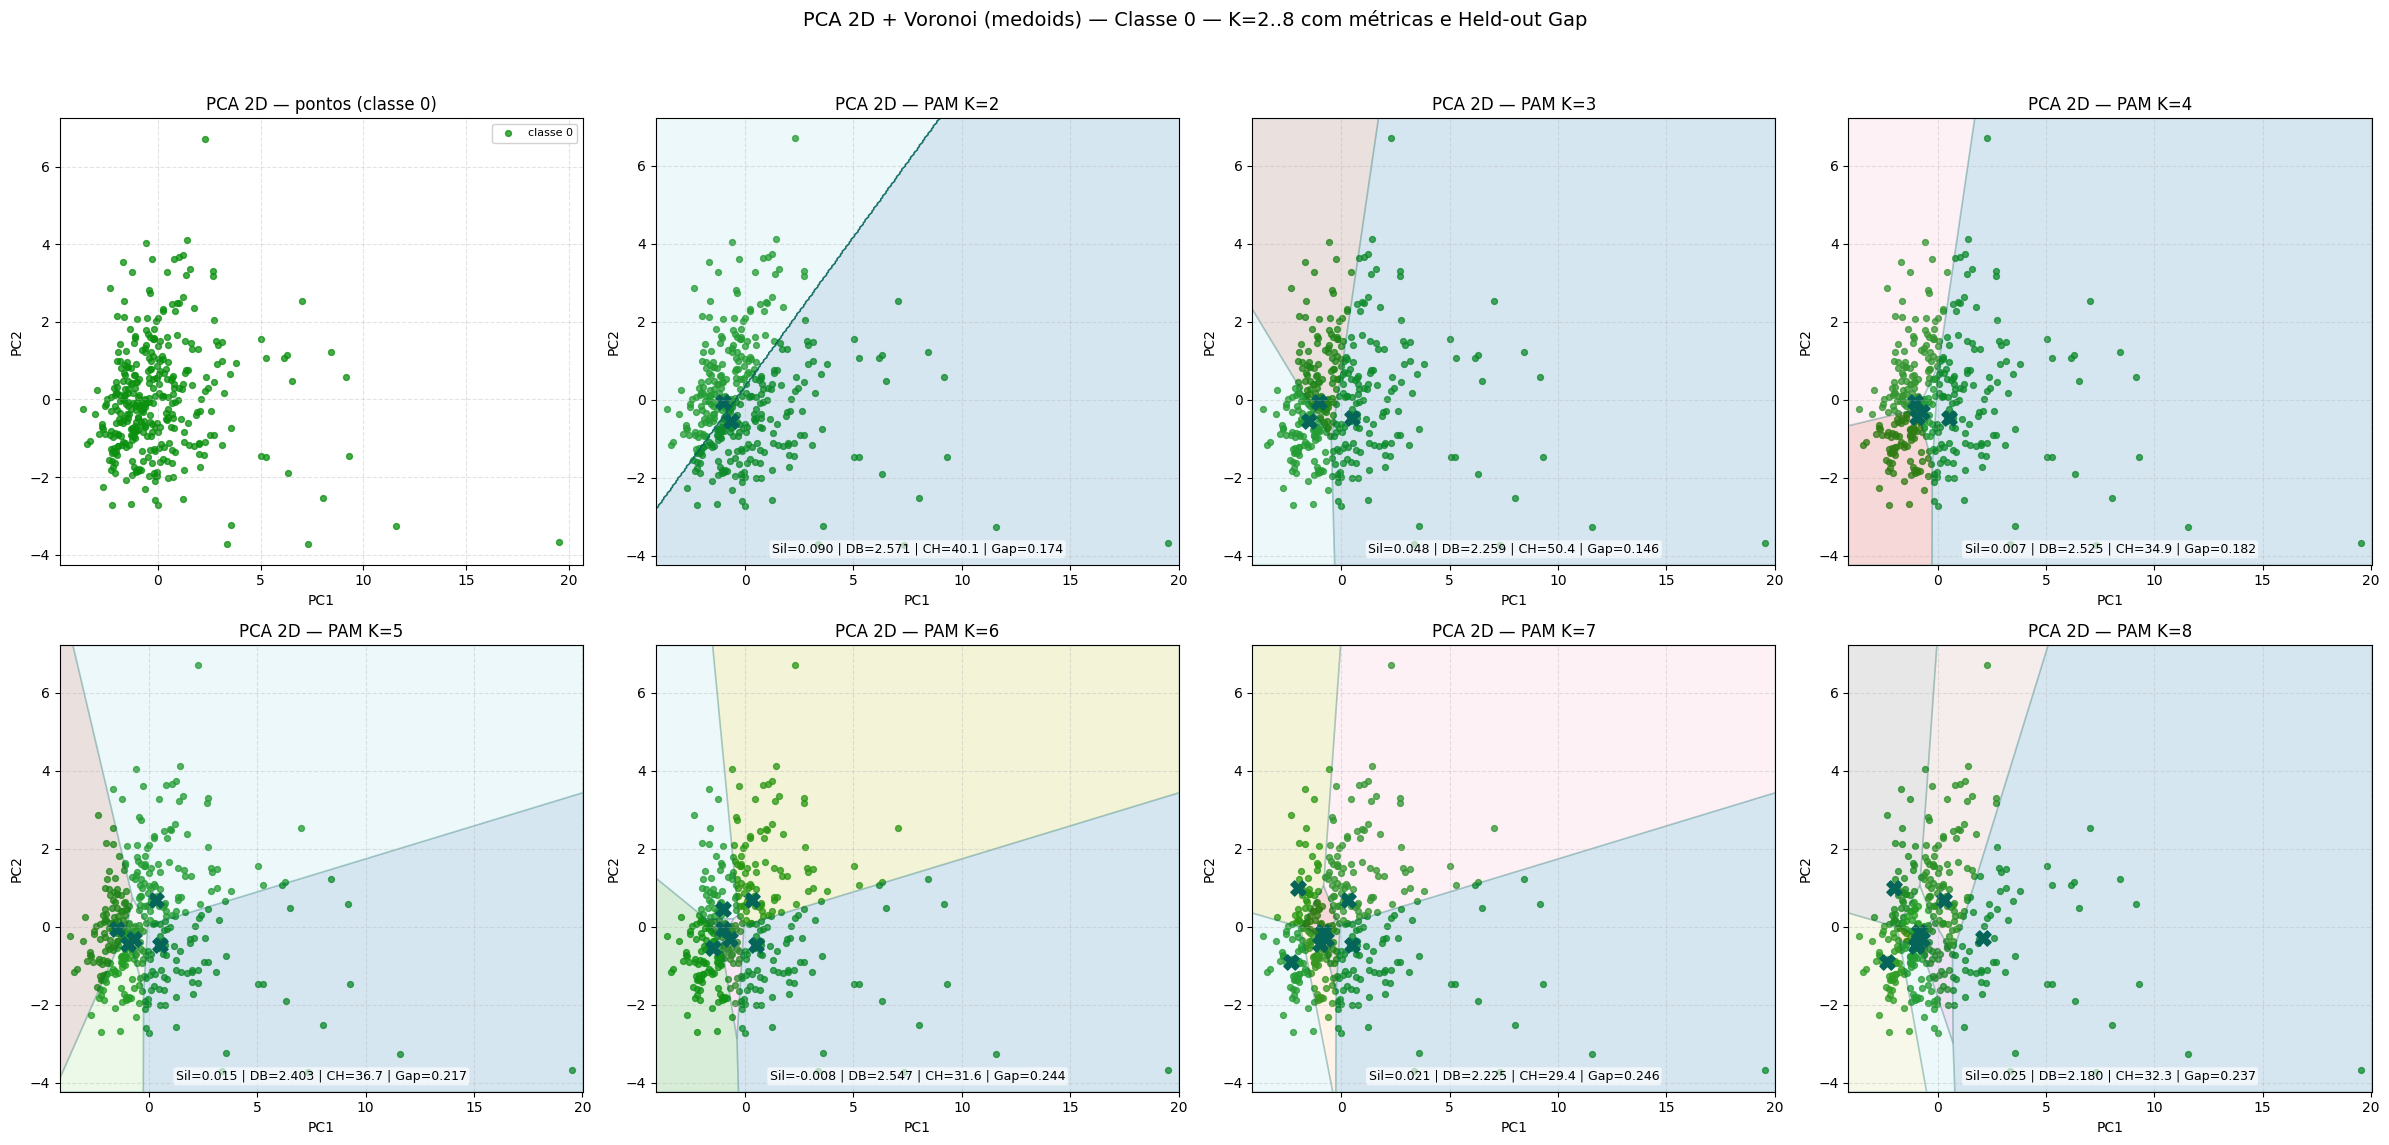

[Classe 0] Figura salva em: ../clusters_reports/xgboost/images/pca2d_voronoi_k2a8_classe0.png


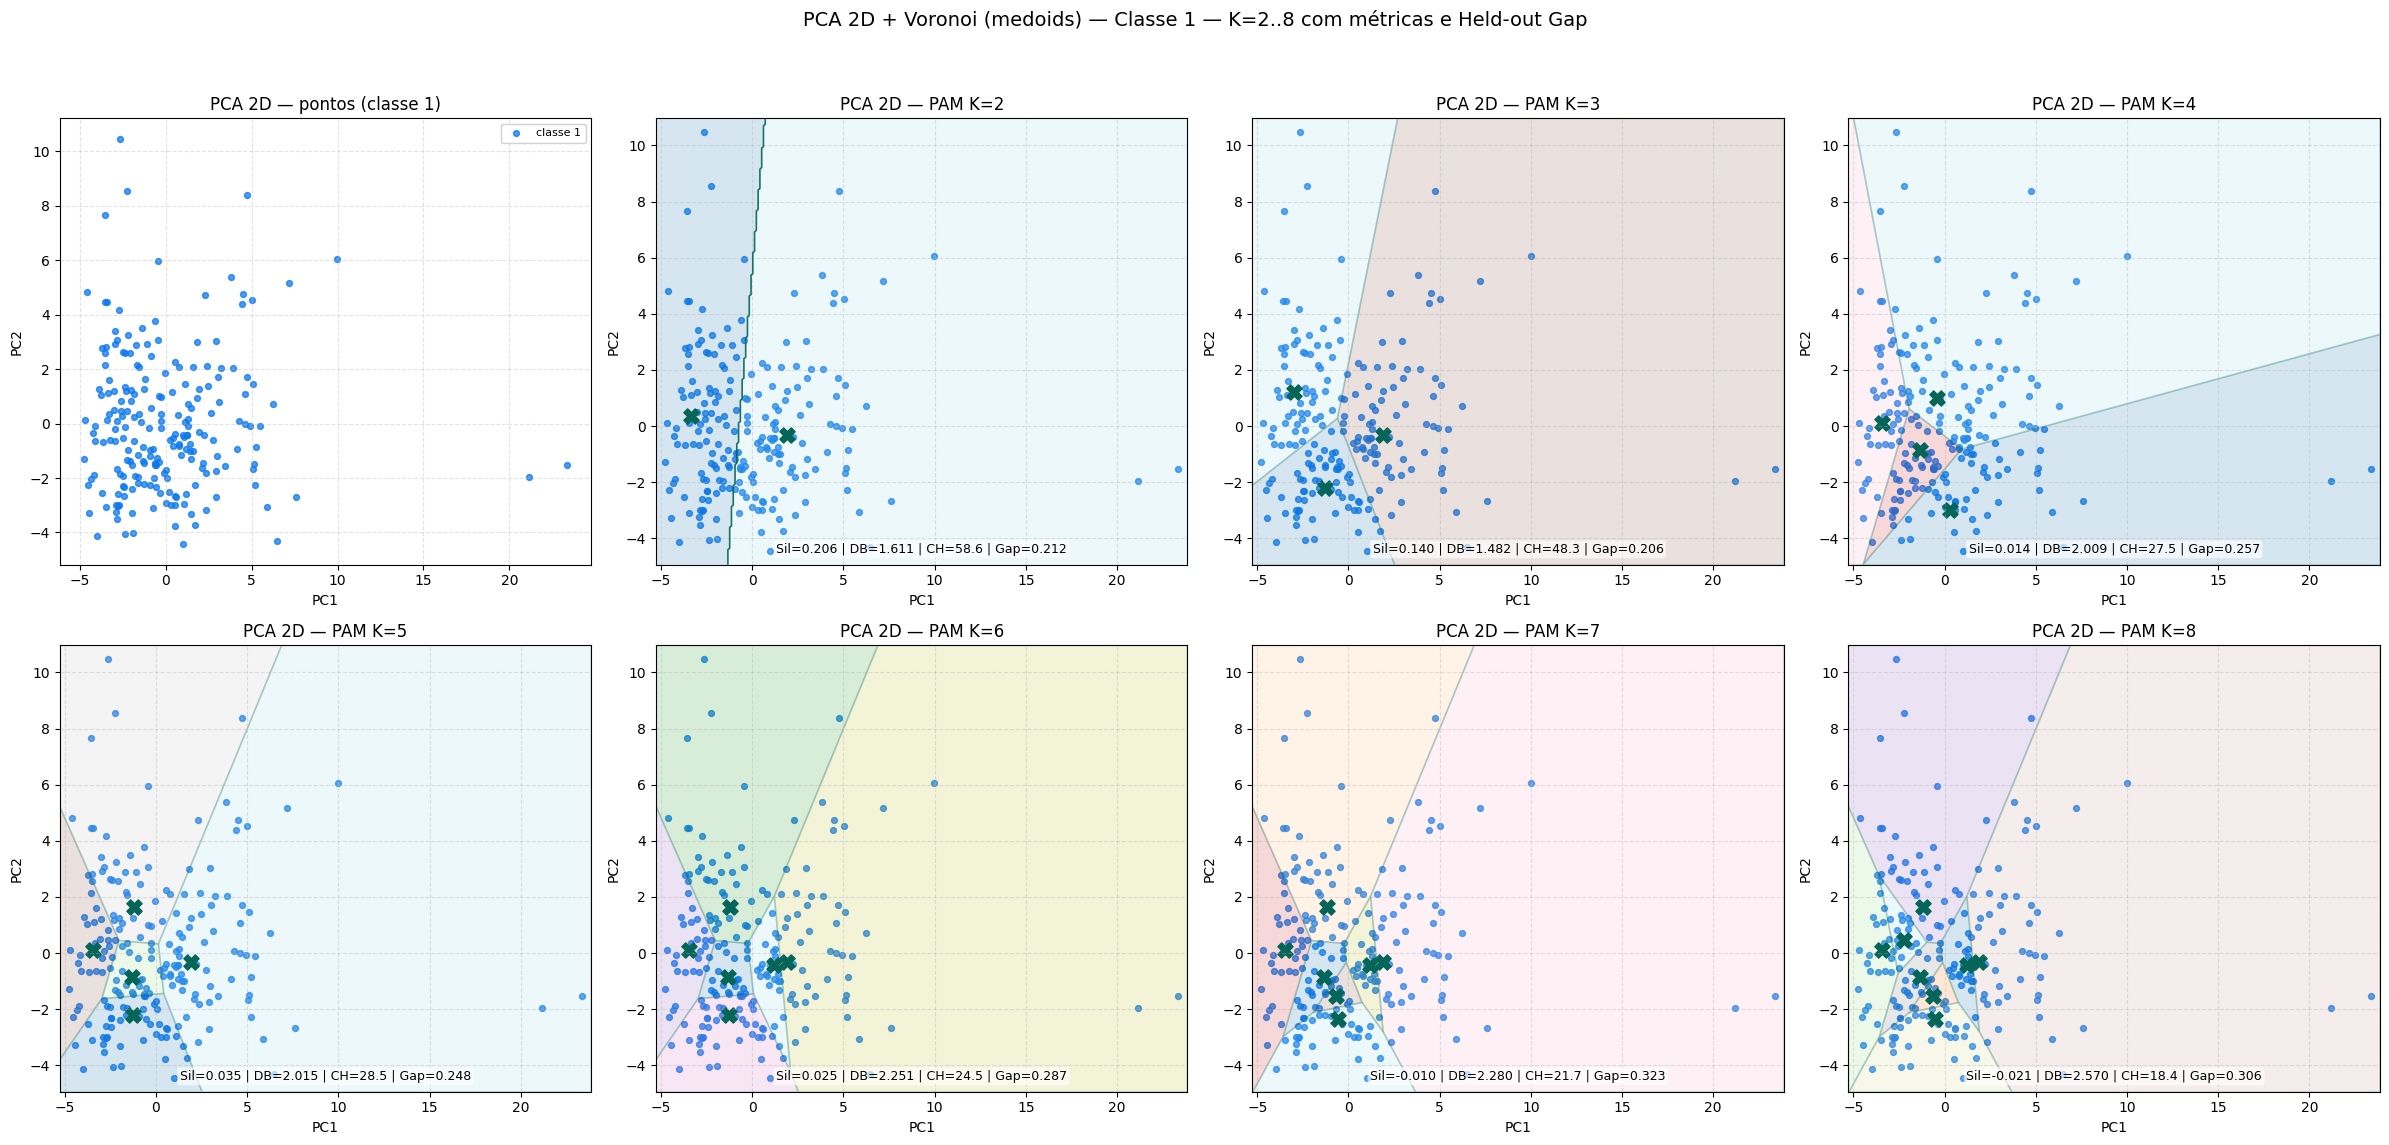

[Classe 1] Figura salva em: ../clusters_reports/xgboost/images/pca2d_voronoi_k2a8_classe1.png


In [9]:
# === PCA 2D + Voronoi (medoids) com Fallback — K=2..8 (Held-out Gap) — SEPARADO POR CLASSE (y_pred) ===
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import pairwise_distances
from matplotlib.colors import ListedColormap
from matplotlib.patches import Polygon

try:
    from scipy.spatial import Voronoi
    HAS_SCIPY = True
except Exception:
    Voronoi = None
    HAS_SCIPY = False

RESULTS_DIR = str(OUT_IMG) if 'OUT_IMG' in globals() else 'resultados_explainable_clustering'
os.makedirs(RESULTS_DIR, exist_ok=True)

CMAP_CLUSTERS      = plt.cm.tab20
CLUSTER_BG_ALPHA   = 0.18
CLUSTER_LINE_COLOR = "#056559"
MEDOID_COLOR       = "#056559"
POINT_COLORS       = {0: "#0B900F", 1: "#0C78EC"}

def _voronoi_finite_polygons_2d(vor, radius: float = None):
    if vor.points.shape[1] != 2:
        raise ValueError("Suporta apenas Voronoi 2D.")
    new_regions = []
    new_vertices = vor.vertices.tolist()
    center = vor.points.mean(axis=0)
    if radius is None:
        radius = vor.points.ptp().max() * 2
    all_ridges = {}
    for (p1, p2), (v1, v2) in zip(vor.ridge_points, vor.ridge_vertices):
        all_ridges.setdefault(p1, []).append((p2, v1, v2))
        all_ridges.setdefault(p2, []).append((p1, v1, v2))
    for p1, region_idx in enumerate(vor.point_region):
        region = vor.regions[region_idx]
        if -1 not in region and len(region) > 0:
            new_regions.append(region)
            continue
        ridges = all_ridges.get(p1, [])
        new_region = [v for v in region if v >= 0]
        for p2, v1, v2 in ridges:
            if v2 < 0 or v1 < 0:
                t = vor.points[p2] - vor.points[p1]
                nrm = np.linalg.norm(t)
                if nrm == 0:
                    continue
                t /= nrm
                n = np.array([-t[1], t[0]])
                midpoint = (vor.points[p1] + vor.points[p2]) / 2
                direction = np.sign(np.dot(midpoint - center, n)) * n
                base = vor.vertices[v1 if v1 >= 0 else v2]
                far_point = base + direction * radius
                new_vertices.append(far_point.tolist())
                new_region.append(len(new_vertices) - 1)
        vs = np.asarray([new_vertices[v] for v in new_region])
        if vs.size == 0:
            new_regions.append([])
            continue
        c = vs.mean(axis=0)
        angles = np.arctan2(vs[:,1] - c[1], vs[:,0] - c[0])
        new_region = [v for _, v in sorted(zip(angles, new_region))]
        new_regions.append(new_region)
    return new_regions, np.asarray(new_vertices)

def _clip_poly_to_bbox(poly_xy: np.ndarray, bbox):
    x_min, x_max, y_min, y_max = bbox
    def clip_edge(points, inside_fn, intersect_fn):
        if len(points) == 0:
            return []
        out = []
        S = points[-1]
        for E in points:
            if inside_fn(E):
                if inside_fn(S):
                    out.append(E)
                else:
                    out.append(intersect_fn(S, E))
                    out.append(E)
            else:
                if inside_fn(S):
                    out.append(intersect_fn(S, E))
            S = E
        return out
    def inside_left(p):   return p[0] >= x_min
    def inside_right(p):  return p[0] <= x_max
    def inside_bottom(p): return p[1] >= y_min
    def inside_top(p):    return p[1] <= y_max
    def intersect_left(S, E):
        dx, dy = E[0] - S[0], E[1] - S[1]
        if dx == 0: return np.array([x_min, S[1]])
        t = (x_min - S[0]) / dx
        return np.array([x_min, S[1] + t * dy])
    def intersect_right(S, E):
        dx, dy = E[0] - S[0], E[1] - S[1]
        if dx == 0: return np.array([x_max, S[1]])
        t = (x_max - S[0]) / dx
        return np.array([x_max, S[1] + t * dy])
    def intersect_bottom(S, E):
        dx, dy = E[0] - S[0], E[1] - S[1]
        if dy == 0: return np.array([S[0], y_min])
        t = (y_min - S[1]) / dy
        return np.array([S[0] + t * dx, y_min])
    def intersect_top(S, E):
        dx, dy = E[0] - S[0], E[1] - S[1]
        if dy == 0: return np.array([S[0], y_max])
        t = (y_max - S[1]) / dy
        return np.array([S[0] + t * dx, y_max])
    pts = [np.array(p) for p in poly_xy]
    pts = clip_edge(pts, inside_left,   intersect_left)
    pts = clip_edge(pts, inside_right,  intersect_right)
    pts = clip_edge(pts, inside_bottom, intersect_bottom)
    pts = clip_edge(pts, inside_top,    intersect_top)
    return np.array(pts)

def _is_degenerate(points2d: np.ndarray) -> bool:
    if not HAS_SCIPY:
        return True
    if points2d.shape[0] < 3:
        return True
    if np.unique(points2d, axis=0).shape[0] < 3:
        return True
    return np.linalg.matrix_rank(points2d - points2d.mean(axis=0)) < 2

def _draw_voronoi_or_nn(ax, med2d: np.ndarray, bbox, colors, line_color, alpha, radius=None):
    x_min, x_max, y_min, y_max = bbox
    nK = med2d.shape[0]
    cmap_disc = ListedColormap(colors)
    diag = np.hypot(x_max - x_min, y_max - y_min)
    radius_eff = (10.0 * diag) if (radius is None) else float(radius)
    try:
        if _is_degenerate(med2d):
            raise RuntimeError("Degenerate or SciPy unavailable")
        vor = Voronoi(med2d)
        regions, vertices = _voronoi_finite_polygons_2d(vor, radius=radius_eff)
        for i, region in enumerate(regions):
            if not region:
                continue
            poly_xy = vertices[region]
            poly_clip = _clip_poly_to_bbox(poly_xy, (x_min, x_max, y_min, y_max))
            if isinstance(poly_clip, np.ndarray) and len(poly_clip) >= 3:
                poly = Polygon(poly_clip, closed=True,
                               facecolor=colors[i % len(colors)],
                               edgecolor=line_color, linewidth=1.2, alpha=alpha)
                ax.add_patch(poly)
    except Exception:
        RES = 300
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, RES), np.linspace(y_min, y_max, RES))
        grid2d = np.c_[xx.ravel(), yy.ravel()]
        Zk = pairwise_distances(grid2d, med2d, metric="euclidean").argmin(axis=1).reshape(xx.shape)
        levels = np.arange(-0.5, nK + 0.5, 1.0)
        ax.contourf(xx, yy, Zk, levels=levels, cmap=cmap_disc, alpha=alpha)
        ax.contour(xx, yy, Zk, levels=levels, colors=line_color, linewidths=1.2, alpha=0.9)

from sklearn_extra.cluster import KMedoids

def run_kmedoids_exemplars(X, k, metric="euclidean", random_state=0):
    if len(X) < 3 or k < 2 or k > len(X)-1:
        return np.array([]), np.array([]), np.nan, None
    model = KMedoids(n_clusters=k, metric=metric, random_state=random_state)
    labels = model.fit_predict(X)
    meds = model.medoid_indices_
    cost = model.inertia_
    return meds, labels, cost, model

def heldout_gap_kmedoids(X_np, K, metric="euclidean", test_size=0.3, n_repeats=3, random_state=42):
    rng = np.random.default_rng(random_state)
    gaps = []
    n = len(X_np)
    if n < 4:
        return np.nan
    for r in range(n_repeats):
        idx = np.arange(n)
        rng.shuffle(idx)
        split = max(1, int(n * (1 - test_size)))
        tr_idx, va_idx = idx[:split], idx[split:]
        if len(va_idx) == 0 or len(tr_idx) < 2:
            continue
        Xtr, Xva = X_np[tr_idx], X_np[va_idx]
        meds_tr, labels_tr, cost_tr, D_tr = run_kmedoids_exemplars(
            Xtr, K, metric="euclidean", random_state=int(random_state + r)
        )
        P = Xtr[meds_tr]
        train_cost = pairwise_distances(Xtr, P, metric=metric).min(axis=1).mean()
        val_cost   = pairwise_distances(Xva, P, metric=metric).min(axis=1).mean()
        gaps.append(val_cost - train_cost)
    return float(np.mean(gaps)) if gaps else np.nan

def annotate_metrics_inside(ax, sil, db, ch, gap):
    txt = f"Sil={sil:.3f} | DB={db:.3f} | CH={ch:.1f} | Gap={gap:.3f}"
    ax.text(0.5, 0.02, txt, transform=ax.transAxes, ha="center", va="bottom",
            fontsize=9, bbox=dict(boxstyle="round,pad=0.2",
                                  facecolor="white", alpha=0.65, edgecolor="none"))

def draw_panel(ax, title, X_2d, labels_k=None, medoids_idx_k=None, plot_color="tab:blue", add_legend=False):
    ax.scatter(X_2d[:,0], X_2d[:,1], s=18, alpha=0.75, c=plot_color,
               label="amostras" if add_legend else None)
    if (medoids_idx_k is not None) and (len(medoids_idx_k) > 0):
        meds_idx = np.asarray(medoids_idx_k, dtype=int)
        med2d = X_2d[meds_idx]
        if np.unique(med2d, axis=0).shape[0] < med2d.shape[0]:
            rng = np.random.default_rng(0)
            med2d = med2d + 1e-9 * rng.standard_normal(med2d.shape)
        PAD = 0.5
        x_min, x_max = X_2d[:,0].min()-PAD, X_2d[:,0].max()+PAD
        y_min, y_max = X_2d[:,1].min()-PAD, X_2d[:,1].max()+PAD
        ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)
        nK = med2d.shape[0]
        colors = [CMAP_CLUSTERS(i / max(1, nK-1)) for i in range(nK)]
        diag = np.hypot(x_max - x_min, y_max - y_min)
        bbox = (x_min, x_max, y_min, y_max)
        _draw_voronoi_or_nn(ax, med2d, bbox, colors, CLUSTER_LINE_COLOR, CLUSTER_BG_ALPHA, radius=10.0 * diag)
        ax.scatter(med2d[:,0], med2d[:,1], s=120, marker="X", c=MEDOID_COLOR,
                   label="medoids" if add_legend else None)
    ax.set_title(title)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.grid(True, linestyle="--", alpha=0.35)
    if add_legend:
        ax.legend(ncol=1, fontsize=8, framealpha=0.9)

def painel_por_classe(X_sub: pd.DataFrame, class_id: int, filename: str, point_color="tab:blue"):
    if len(X_sub) < 3:
        print(f"[Classe {class_id}] poucos dados ({len(X_sub)}); painel não gerado.")
        return
    pca = PCA(n_components=2, random_state=42)
    X_2d = pca.fit_transform(X_sub.values)
    X_np = X_sub.values
    K_row1 = [2, 3, 4]
    K_row2 = [5, 6, 7, 8]
    maxK = max(2, len(X_sub) - 1)
    K_row1 = [k for k in K_row1 if k <= maxK]
    K_row2 = [k for k in K_row2 if k <= maxK]
    pam_runs = {}
    metrics_by_K = {}
    for K in (K_row1 + K_row2):
        meds_k, labels_k, cost_k, D_k = run_kmedoids_exemplars(X_np, K, metric="euclidean", random_state=42)
        pam_runs[K] = (labels_k, meds_k)
        sil = silhouette_score(X_np, labels_k, metric="euclidean")
        db  = davies_bouldin_score(X_np, labels_k)
        ch  = calinski_harabasz_score(X_np, labels_k)
        gap = heldout_gap_kmedoids(X_np, K, metric="euclidean", test_size=0.3, n_repeats=3, random_state=123)
        metrics_by_K[K] = (sil, db, ch, gap)
    fig, axes = plt.subplots(2, 4, figsize=(24, 12), squeeze=False)
    ax00 = axes[0,0]
    ax00.scatter(X_2d[:,0], X_2d[:,1], s=18, alpha=0.75, c=point_color, label=f"classe {class_id}")
    ax00.set_title(f"PCA 2D — pontos (classe {class_id})")
    ax00.set_xlabel("PC1"); ax00.set_ylabel("PC2"); ax00.grid(True, linestyle="--", alpha=0.35)
    ax00.legend(ncol=1, fontsize=8, framealpha=0.9)
    for j, K in enumerate(K_row1, start=1):
        ax = axes[0, j]
        labels_k, meds_k = pam_runs[K]
        draw_panel(ax, f"PCA 2D — PAM K={K}", X_2d, labels_k=labels_k, medoids_idx_k=meds_k, plot_color=point_color)
        sil, db, ch, gap = metrics_by_K[K]
        annotate_metrics_inside(ax, sil, db, ch, gap)
    for j, K in enumerate(K_row2):
        ax = axes[1, j]
        labels_k, meds_k = pam_runs[K]
        draw_panel(ax, f"PCA 2D — PAM K={K}", X_2d, labels_k=labels_k, medoids_idx_k=meds_k, plot_color=point_color)
        sil, db, ch, gap = metrics_by_K[K]
        annotate_metrics_inside(ax, sil, db, ch, gap)
    for j in range(len(K_row2), 4):
        axes[1, j].axis("off")
    plt.suptitle(f"PCA 2D + Voronoi (medoids) — Classe {class_id} — K=2..8 com métricas e Held-out Gap", fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    outpath = os.path.join(RESULTS_DIR, filename)
    plt.savefig(outpath, dpi=150)
    plt.show()
    print(f"[Classe {class_id}] Figura salva em: {outpath}")

# --- Seleção de dados por classe prevista ---
# Corrigido: Usando DF_GLOBAL_NORM_C0 e DF_GLOBAL_NORM_C1 para separar por classe
# Agora removendo colunas de EXCLUDE_COLUMNS apenas no DataFrame derivado
X_by_class = {
    0: DF_GLOBAL_NORM_C0.copy(),
    1: DF_GLOBAL_NORM_C1.copy(),
}
for class_id, X_df in X_by_class.items():
    X_df_proc = X_df.drop(columns=EXCLUDE_COLUMNS, errors='ignore')
    painel_por_classe(X_df_proc, class_id=class_id, filename=f"pca2d_voronoi_k2a8_classe{class_id}.png", point_color=POINT_COLORS.get(class_id, "tab:blue"))


In [10]:
# PCA 3D Voronoi usando DF_GLOBAL_NORM_C0 e DF_GLOBAL_NORM_C1 (sempre gera novo HTML)
import os
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from IPython.display import HTML, display

# 1. Seleção dos DataFrames por classe já carregados
df_c0 = DF_GLOBAL_NORM_C0.copy()
df_c1 = DF_GLOBAL_NORM_C1.copy()

# 2. Seleção de features numéricas (excluindo EXCLUDE_COLUMNS e TARGET_COLUMN)
exclude = set(EXCLUDE_COLUMNS + [TARGET_COLUMN])
cols_num_c0 = [c for c in df_c0.select_dtypes(include=[np.number]).columns if c not in exclude]
cols_num_c1 = [c for c in df_c1.select_dtypes(include=[np.number]).columns if c not in exclude]

# 3. Unificar para PCA global (mantendo apenas colunas comuns)
cols_common = list(set(cols_num_c0) & set(cols_num_c1))
df_c0_proc = df_c0[cols_common]
df_c1_proc = df_c1[cols_common]
df_all = pd.concat([df_c0_proc, df_c1_proc], axis=0, ignore_index=True)

# 4. PCA 3D global
X_np = df_all.values
scaler = StandardScaler().fit(X_np)
X_scaled = scaler.transform(X_np)
pca = PCA(n_components=3, random_state=42).fit(X_scaled)
X_3d = pca.transform(X_scaled)

# 5. Separar projeções por classe
n0 = len(df_c0_proc)
X3_c0 = X_3d[:n0]
X3_c1 = X_3d[n0:]

GRID_RES     = 28
PLANE_PCTS   = (5, 95)
POINT_SIZE   = 3
MEDOID_SIZE  = 5
SURF_OPACITY     = 0.6
SURF_OPACITY_K1  = 0.5
PALETTE = ["#e41a1c","#377eb8","#4daf4a","#984ea3","#ff7f00",
           "#ffff33","#a65628","#f781bf","#999999","#66c2a5"]

def colorscale_discrete(colors):
    n = len(colors)
    if n == 1:
        return [[0.0, colors[0]], [1.0, colors[0]]]
    return [[i/(n-1), c] for i, c in enumerate(colors)]

def get_k_for_class(cid: int) -> int:
    if 'SILHUET' in globals() and SILHUET is not None:
        if isinstance(SILHUET, dict) and (str(cid) in SILHUET):
            try:
                return max(1, int(SILHUET[str(cid)]))
            except Exception:
                pass
        if isinstance(SILHUET, dict) and (cid in SILHUET):
            try:
                return max(1, int(SILHUET[cid]))
            except Exception:
                pass
    if 'N_CLUSTERS' in globals() and isinstance(N_CLUSTERS, dict):
        return max(1, int(N_CLUSTERS.get(cid, 1)))
    return 1

def add_classe_voronoi(fig, X_cls, X3_cls, class_id: int, col: int, point_color='red'):
    Kc = get_k_for_class(class_id)
    if len(X_cls) < 1:
        print(f"[Classe {class_id}] sem pontos. Pulando.")
        return
    if Kc >= 2 and len(X_cls) < Kc:
        print(f"[Classe {class_id}] poucos dados ({len(X_cls)}) para k={Kc} (forçado). Pulando.")
        return
    from sklearn_extra.cluster import KMedoids
    meds_k, labels_k, _, _ = run_kmedoids_exemplars(X_cls, Kc, metric="euclidean", random_state=42)
    labels_k = np.asarray(labels_k).astype(int)
    med3d = X3_cls[np.asarray(meds_k, int)]
    fig.add_trace(
        go.Scatter3d(
            x=X3_cls[:,0], y=X3_cls[:,1], z=X3_cls[:,2],
            mode='markers', name=f'classe {class_id}',
            marker=dict(size=POINT_SIZE, color=point_color, opacity=0.85)
        ),
        row=1, col=col
    )
    fig.add_trace(
        go.Scatter3d(
            x=med3d[:,0], y=med3d[:,1], z=med3d[:,2],
            mode='markers+text', name=f'medoids c{class_id}',
            marker=dict(size=MEDOID_SIZE, symbol='x', color='black',
                        opacity=1.0, line=dict(width=1, color='white')),
            text=[f"M{class_id}-{i}" for i in range(len(med3d))],
            textposition='top center', textfont=dict(size=10, color='black')
        ),
        row=1, col=col
    )
    PAD = 0.5
    xs = np.linspace(X3_cls[:,0].min()-PAD, X3_cls[:,0].max()+PAD, GRID_RES)
    ys = np.linspace(X3_cls[:,1].min()-PAD, X3_cls[:,1].max()+PAD, GRID_RES)
    z0, z1 = np.percentile(X3_cls[:,2], PLANE_PCTS)
    if np.isclose(z0, z1):
        z1 = z1 + 1e-6
    CS = colorscale_discrete(PALETTE[:max(1, Kc)])
    def surface_voronoi(zplane, surf_name):
        XX, YY = np.meshgrid(xs, ys, indexing='ij')
        grid3 = np.c_[XX.ravel(), YY.ravel(), np.full(XX.size, zplane)]
        diff = grid3[:, None, :] - med3d[None, :, :]
        d2 = np.sum(diff*diff, axis=2)
        pred = np.argmin(d2, axis=1)
        pred_img = pred.reshape(XX.shape).astype(float)
        return go.Surface(
            x=XX, y=YY, z=np.full_like(XX, zplane),
            surfacecolor=pred_img,
            cmin=0, cmax=max(1, Kc-1),
            colorscale=CS, showscale=False, opacity=SURF_OPACITY, name=surf_name
        )
    if Kc >= 2:
        fig.add_trace(surface_voronoi(z0, f"plano z@{PLANE_PCTS[0]}%"), row=1, col=col)
        fig.add_trace(surface_voronoi(z1, f"plano z@{PLANE_PCTS[1]}%"), row=1, col=col)
    else:
        XX, YY = np.meshgrid(xs, ys, indexing='ij')
        const0 = np.zeros_like(XX, dtype=float)
        for zplane, name in [(z0, f"plano z@{PLANE_PCTS[0]}%"), (z1, f"plano z@{PLANE_PCTS[1]}%")]:
            fig.add_trace(
                go.Surface(
                    x=XX, y=YY, z=np.full_like(XX, zplane),
                    surfacecolor=const0, cmin=0, cmax=1,
                    colorscale=CS, showscale=False, opacity=SURF_OPACITY_K1, name=name
                ),
                row=1, col=col
)

k0 = get_k_for_class(0)
k1 = get_k_for_class(1)
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type':'scene'}, {'type':'scene'}]],
    horizontal_spacing=0.0,
    column_widths=[0.5, 0.5],
    subplot_titles=(
        f"Classe 0 · k={k0} · Voronoi (medoides)",
        f"Classe 1 · k={k1} · Voronoi (medoides)"
    )
)
add_classe_voronoi(fig, df_c0_proc.values, X3_c0, 0, col=1, point_color='#0B900F')
add_classe_voronoi(fig, df_c1_proc.values, X3_c1, 1, col=2, point_color='#0C78EC')
fig.update_layout(
    title="PCA 3D · Regiões por Voronoi (medoides) — classes lado a lado",
    autosize=True,
    width=None,
    height=560,
    margin=dict(l=0, r=0, t=34, b=0, pad=0),
    legend=dict(bgcolor="rgba(255,255,255,0.85)")
)
fig.update_layout(
    scene = dict(
        domain=dict(x=[0.00, 0.50], y=[0, 1]),
        xaxis_title="PC1", yaxis_title="PC2", zaxis_title="PC3",
        xaxis=dict(backgroundcolor="rgb(245,245,245)"),
        yaxis=dict(backgroundcolor="rgb(245,245,245)"),
        zaxis=dict(backgroundcolor="rgb(245,245,245)")
    ),
    scene2 = dict(
        domain=dict(x=[0.50, 1.00], y=[0, 1]),
        xaxis_title="PC1", yaxis_title="PC2", zaxis_title="PC3",
        xaxis=dict(backgroundcolor="rgb(245,245,245)"),
        yaxis=dict(backgroundcolor="rgb(245,245,245)"),
        zaxis=dict(backgroundcolor="rgb(245,245,245)")
    )
)
out_html = str(OUT_IMG / "pca3d_voronoi_duas_colunas.html")
fig.write_html(
    out_html,
    include_plotlyjs="cdn",
    full_html=True,
    config={"responsive": True}
)
print(f"✅ HTML salvo em: {out_html}")
try:
    pio.renderers.default = "plotly_mimetype"
    fig.show()
except Exception:
    display(HTML(fig.to_html(include_plotlyjs="cdn", full_html=False)))


✅ HTML salvo em: ../clusters_reports/xgboost/images/pca3d_voronoi_duas_colunas.html


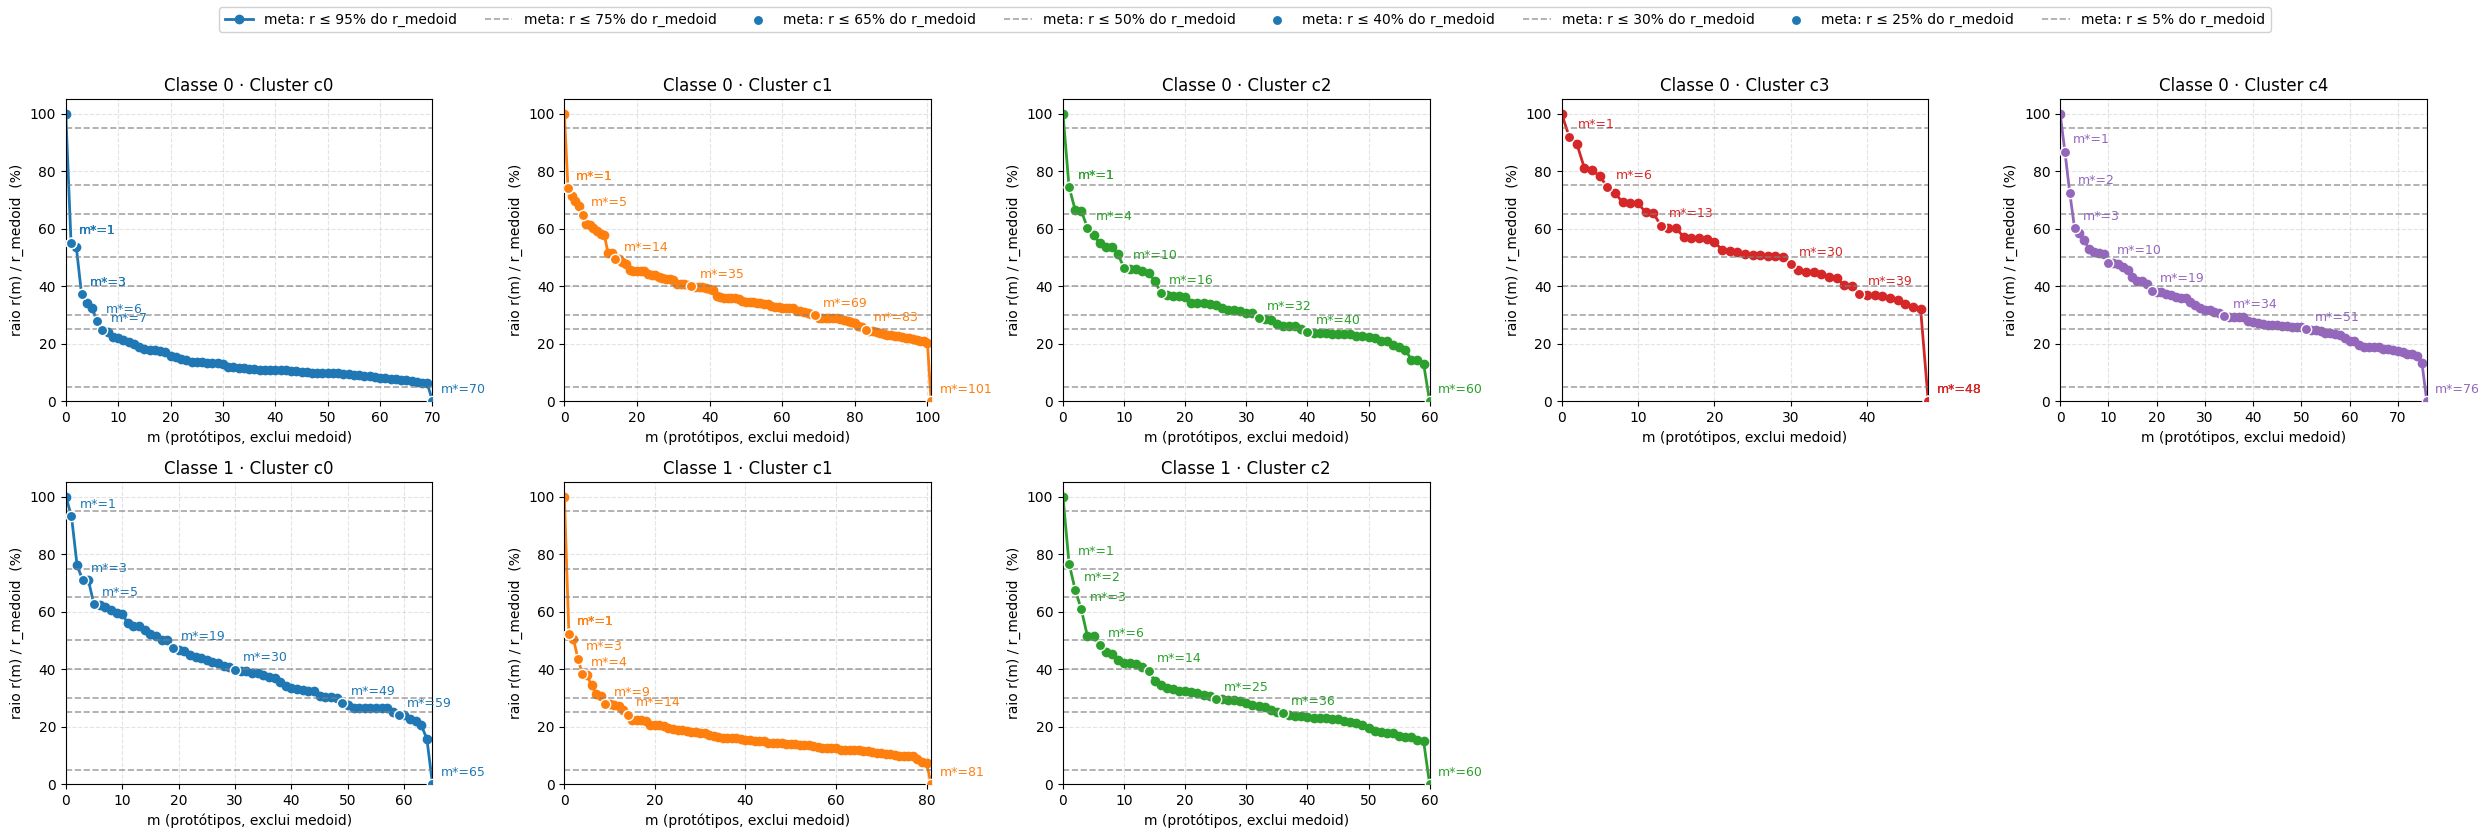

✅ Figura salva em: ../clusters_reports/xgboost/images/kcenter_curva_raio_vs_m_por_cluster_duas_linhas.png
✅ Tabela salva em: ../clusters_reports/xgboost/csv/kcenter_m_necessario_por_cluster_por_meta.csv
   classe  cluster  n_pontos_cluster   r_medoid  alvo_frac  \
0       0        0                71  20.995171       0.05   
1       0        0                71  20.995171       0.25   
2       0        0                71  20.995171       0.30   
3       0        0                71  20.995171       0.40   
4       0        0                71  20.995171       0.50   

   m_necessario_excl_medoid  representantes_total_incl_medoid  \
0                        70                                71   
1                         7                                 8   
2                         6                                 7   
3                         3                                 4   
4                         3                                 4   

   raio_resultante  raio_resultan

In [11]:
# COTOVELO (por cluster) — usa a variável **SILHUET** para definir K por classe
# ======================================================================
# Ex.: SILHUET = {0: 5, 1: 3}
# Depois de definir K_BY_CLASS a partir de SILHUET, o restante calcula
# as curvas r(m)/r_medoid por cluster (k-center style) e gera as tabelas.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances

RESULTS_DIR = str(OUT_CSV) if 'OUT_CSV' in globals() else globals().get('RESULTS_DIR', 'resultados_explainable_clustering')
os.makedirs(RESULTS_DIR, exist_ok=True)

# Metas de fração do raio inicial (m=0 => só medoid). Ex: 0.25 => reduzir 75%.
TARGET_FRACS = [0.95, 0.75, 0.65, 0.50, 0.40, 0.30, 0.25, 0.05]
PALETTE = plt.cm.tab10

assert 'run_kmedoids_exemplars' in globals(), 'Defina run_kmedoids_exemplars antes.'
RANDOM_STATE = globals().get('RANDOM_STATE', 42)

# ----------------- Preparar dados base / classes -----------------
if 'XGB_PER_CLASS_PATHS' not in globals():
    raise RuntimeError('XGB_PER_CLASS_PATHS não encontrado. Execute as células de preparação de dados antes.')

per_class_paths = globals()['XGB_PER_CLASS_PATHS']
frames = []
for cls_val, path in per_class_paths.items():
    df_tmp = pd.read_csv(path)
    df_tmp['__cls_tmp__'] = int(cls_val)  # força classe
    frames.append(df_tmp)
if not frames:
    raise RuntimeError('Nenhum CSV por classe encontrado em XGB_PER_CLASS_PATHS.')
X_test = pd.concat(frames, axis=0, ignore_index=True)
y_pred = X_test['__cls_tmp__'].to_numpy().astype(int)

# Filtrar somente colunas numéricas válidas para distância, excluindo EXCLUDE_COLUMNS
exclude = set(EXCLUDE_COLUMNS) if 'EXCLUDE_COLUMNS' in globals() else set()
num_cols = [c for c in X_test.columns if c not in exclude and pd.api.types.is_numeric_dtype(X_test[c])]
if '__cls_tmp__' in num_cols:
    num_cols.remove('__cls_tmp__')
X_num = X_test[num_cols].to_numpy(dtype=float, copy=True)

# ----------------- K_BY_CLASS vindo de SILHUET -----------------
if 'SILHUET' not in globals() or not isinstance(SILHUET, dict) or not SILHUET:
    raise RuntimeError("A variável SILHUET não está definida como dict não-vazio (ex.: {0:5, 1:3}).")

def _sanitize_k_for_class(n_pts_class: int, k_desired: int):
    """Garante 2 <= k <= n-1 quando possível; caso contrário retorna None."""
    if n_pts_class < 3 or k_desired is None:
        return None
    k_desired = int(k_desired)
    return max(2, min(k_desired, n_pts_class - 1))

# constrói K_BY_CLASS a partir de SILHUET, já sanitizando por classe
K_BY_CLASS = {}
for cls in sorted(np.unique(y_pred).tolist()):
    n_cls = int((y_pred == cls).sum())
    k_raw = SILHUET.get(int(cls), None)
    K_BY_CLASS[int(cls)] = _sanitize_k_for_class(n_cls, k_raw)

# ----------------- Helpers -----------------
def _r_sequence_kcenter_farthest(D_cluster: np.ndarray, seed_pos: int):
    """Sequência de raios r(m) (m=0..n-1) por farthest-first (k-center). m=0 usa o medoid como semente."""
    n = D_cluster.shape[0]
    radii = []
    centers = [int(seed_pos)]
    dist_to_centers = D_cluster[seed_pos].copy()
    radii.append(float(dist_to_centers.max()))
    for m in range(1, n):
        cand = int(np.argmax(dist_to_centers))
        centers.append(cand)
        dist_to_centers = np.minimum(dist_to_centers, D_cluster[cand])
        radii.append(float(dist_to_centers.max()))
    return np.array(radii, dtype=float)

# ----------------- Construir curvas por cluster -----------------
classes = sorted(np.unique(y_pred).tolist())
per_class_cluster_curves = {}
summary_rows = []

for cls in classes:
    mask = (y_pred == cls)
    idx_glob = np.where(mask)[0]
    if idx_glob.size == 0:
        continue

    Xc = X_num[mask]
    Kc = K_BY_CLASS.get(int(cls), None)

    if (Kc is None) or (Xc.shape[0] < max(3, Kc)):
        print(f"[Classe {cls}] poucos pontos para K={Kc}. Pulando.")
        continue

    meds_loc, labels_loc, _, _ = run_kmedoids_exemplars(Xc, Kc, metric='euclidean', random_state=RANDOM_STATE)
    meds_loc   = np.asarray(meds_loc, dtype=int)
    labels_loc = np.asarray(labels_loc, dtype=int)
    D_cls = pairwise_distances(Xc, metric='euclidean')

    per_class_cluster_curves[cls] = {}
    for c in np.sort(np.unique(labels_loc)):
        idxs_loc = np.where(labels_loc == c)[0]
        if len(idxs_loc) <= 1:
            continue

        # medoid local (fallback para o verdadeiro medoid do subcluster, se índice exceder)
        if c < len(meds_loc):
            med_loc = int(meds_loc[c])
        else:
            sub = D_cls[np.ix_(idxs_loc, idxs_loc)]
            med_loc = int(idxs_loc[np.argmin(sub.sum(axis=1))])

        # seed dentro do subcluster
        seed_pos = int(np.where(idxs_loc == med_loc)[0][0])

        # distância interna do cluster
        D_sub = D_cls[np.ix_(idxs_loc, idxs_loc)]

        # sequência de raios por farthest-first
        radii = _r_sequence_kcenter_farthest(D_sub, seed_pos=seed_pos)

        r_medoid = radii[0]
        r_norm = (radii / r_medoid) if r_medoid > 0 else np.zeros_like(radii)
        m_vals = np.arange(len(radii))
        n_pts = int(len(idxs_loc))

        # metas de redução do raio
        m_hits = {}
        for frac in TARGET_FRACS:
            thr = frac * r_medoid
            ok = np.where(radii <= thr)[0]
            m_star = int(ok[0]) if ok.size > 0 else int(m_vals[-1])
            m_hits[frac] = m_star

            pct_protos = 100.0 * m_star / n_pts               # exclui medoid
            pct_repr   = 100.0 * (m_star + 1) / n_pts         # inclui medoid

            summary_rows.append({
                'classe': int(cls),
                'cluster': int(c),
                'n_pontos_cluster': n_pts,
                'r_medoid': float(r_medoid),
                'alvo_frac': float(frac),
                'm_necessario_excl_medoid': int(m_star),
                'representantes_total_incl_medoid': int(m_star + 1),
                'raio_resultante': float(radii[m_star]),
                'raio_resultante_rel_medoid': float(r_norm[m_star]),
                'pct_prototipos_necessarios_%': float(pct_protos),
                'pct_representantes_incl_medoid_%': float(pct_repr),
            })

        per_class_cluster_curves[cls][int(c)] = dict(
            m_vals=m_vals, r_norm=r_norm, r_abs=radii, m_hits=m_hits
        )

# ----------------- Plot -----------------
if per_class_cluster_curves:
    ncols = max([len(per_class_cluster_curves.get(c, {})) for c in classes]) or 1
    fig, axes = plt.subplots(len(classes), ncols, figsize=(5*ncols, 4.2*len(classes)), squeeze=False)

    for r, cls in enumerate(classes):
        clusters = sorted(per_class_cluster_curves.get(cls, {}).keys())
        for j in range(ncols):
            ax = axes[r, j]
            if j >= len(clusters):
                ax.axis('off')
                continue
            c = clusters[j]
            data = per_class_cluster_curves[cls][c]
            m_vals = data['m_vals']; r_norm = data['r_norm']
            color = PALETTE(j % PALETTE.N)

            ax.plot(m_vals, r_norm*100.0, marker='o', linewidth=2.0, color=color, label=f'c{c}')

            for frac in TARGET_FRACS:
                ax.axhline(y=100.0*frac, linestyle='--', linewidth=1.2, color='gray', alpha=0.7)
                m_star = data['m_hits'][frac]
                ax.scatter([m_star], [100.0*(data['r_abs'][m_star]/data['r_abs'][0])],
                           s=55, zorder=5, color=color, edgecolor='white')
                ax.annotate(f"m*={m_star}",
                            (m_star, 100.0*(data['r_abs'][m_star]/data['r_abs'][0])),
                            textcoords='offset points', xytext=(6,6), fontsize=9, color=color)

            ax.set_xlabel('m (protótipos, exclui medoid)')
            ax.set_ylabel('raio r(m) / r_medoid  (%)')
            ax.set_title(f'Classe {cls} · Cluster c{c}')
            ax.set_ylim(0, 105); ax.set_xlim(0, max(m_vals))
            ax.grid(True, linestyle='--', alpha=0.35)

    labels_targets = [f"meta: r ≤ {int(frac*100)}% do r_medoid" for frac in TARGET_FRACS]
    fig.legend(labels_targets, loc='upper center', ncol=len(TARGET_FRACS), framealpha=0.9)
    plt.tight_layout(rect=[0,0,1,0.93])

    out_png = os.path.join(OUT_IMG, 'kcenter_curva_raio_vs_m_por_cluster_duas_linhas.png')
    plt.savefig(out_png, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Figura salva em: {out_png}')
else:
    print('Nenhuma curva gerada (verifique dados / clusters).')

# ----------------- Tabela resumo -----------------
df_m_needed = pd.DataFrame(summary_rows).sort_values(['classe','cluster','alvo_frac']).reset_index(drop=True)
out_csv = os.path.join(RESULTS_DIR, 'kcenter_m_necessario_por_cluster_por_meta.csv')
df_m_needed.to_csv(out_csv, index=False)
print(f'✅ Tabela salva em: {out_csv}')
print(df_m_needed.head())

# Estruturas auxiliares
cols_keep = ['classe','cluster','n_pontos_cluster','m_necessario_excl_medoid',
             'representantes_total_incl_medoid','pct_prototipos_necessarios_%',
             'pct_representantes_incl_medoid_%','raio_resultante_rel_medoid']

requirements_by_target = {}
for frac in TARGET_FRACS:
    sub = df_m_needed[df_m_needed['alvo_frac'] == float(frac)].copy()
    sub = sub[cols_keep].sort_values(['classe','cluster']).reset_index(drop=True)
    requirements_by_target[float(frac)] = sub

requirements_by_target_compact = {}
for frac in TARGET_FRACS:
    sub = requirements_by_target[float(frac)]
    by_class = {}
    for cls in sorted(sub['classe'].unique()):
        sub_cls = sub[sub['classe'] == cls]
        by_class[int(cls)] = {int(r.cluster): int(r.m_necessario_excl_medoid) for r in sub_cls.itertuples(index=False)}
    requirements_by_target_compact[float(frac)] = by_class

wide_dfs_by_class = {}
df_tmp = df_m_needed.copy()
df_tmp['target_label'] = (df_tmp['alvo_frac'] * 100).round(0).astype(int).astype(str) + '%'
for cls in sorted(df_tmp['classe'].unique()):
    pivot = (df_tmp[df_tmp['classe'] == cls]
             .pivot(index='cluster', columns='target_label', values='m_necessario_excl_medoid')
             .sort_index(axis=0).sort_index(axis=1))
    wide_dfs_by_class[int(cls)] = pivot

# Exemplos de inspeção rápida
if 0.25 in requirements_by_target:
    print('\n▶ requirements_by_target[0.25]')
    print(requirements_by_target[0.25].to_string(index=False))
if 0.25 in requirements_by_target_compact:
    print('\n▶ requirements_by_target_compact[0.25]')
    print(requirements_by_target_compact[0.25])
if 1 in wide_dfs_by_class:
    print('\n▶ wide_dfs_by_class[classe=1]')
    print(wide_dfs_by_class[1].to_string())


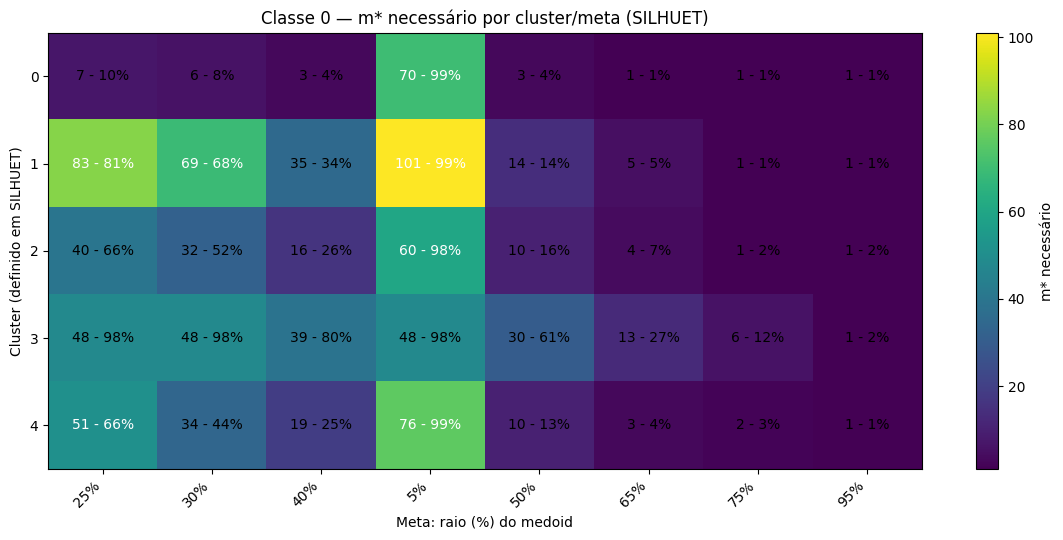

✅ Heatmap salvo em: ../clusters_reports/xgboost/images/heatmap_mstar_por_cluster_meta_classe0.png


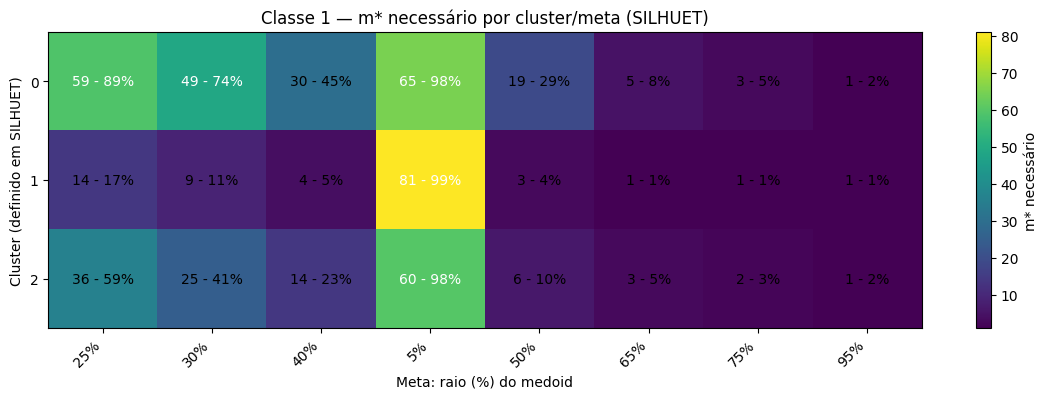

✅ Heatmap salvo em: ../clusters_reports/xgboost/images/heatmap_mstar_por_cluster_meta_classe1.png


In [12]:
# Heatmap de m* por cluster/meta para cada classe (usando SILHUET para K_BY_CLASS se disponível)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# Atualizar K_BY_CLASS para usar SILHUET se disponível
if 'SILHUET' in globals() and isinstance(SILHUET, dict) and SILHUET:
    K_BY_CLASS = {int(k): int(v) for k, v in SILHUET.items() if v is not None}

# Map (classe, cluster) -> n_pontos_cluster para cálculo do percentual
cluster_sizes = {}
if 'df_m_needed' in globals():
    tmp_sizes = df_m_needed[['classe','cluster','n_pontos_cluster']].drop_duplicates()
    for r in tmp_sizes.itertuples(index=False):
        cluster_sizes[(int(r.classe), int(r.cluster))] = int(r.n_pontos_cluster)

# Heatmap para cada classe: clusters x metas (m* necessário)
for cls in sorted(K_BY_CLASS.keys()):
    n_clusters = int(K_BY_CLASS[cls])
    df_wide = wide_dfs_by_class.get(cls)
    cluster_idx = list(range(n_clusters))
    metas = df_wide.columns if df_wide is not None else []
    if df_wide is None or df_wide.empty:
        df_wide = pd.DataFrame(np.nan, index=cluster_idx, columns=metas)
    else:
        df_wide = df_wide.reindex(index=cluster_idx, columns=metas, fill_value=np.nan)

    fig, ax = plt.subplots(figsize=(1.2*len(metas)+2, 0.7*n_clusters+2))
    im = ax.imshow(df_wide.values, cmap='viridis', aspect='auto', interpolation='nearest')
    ax.set_xticks(np.arange(len(metas)))
    ax.set_yticks(np.arange(n_clusters))
    ax.set_xticklabels(metas, rotation=45, ha='right')
    ax.set_yticklabels(cluster_idx)

    vmax = np.nanmax(df_wide.values) if np.isfinite(np.nanmax(df_wide.values)) else 0
    half = vmax/2 if vmax>0 else 0

    for i in range(n_clusters):
        for j in range(len(metas)):
            val = df_wide.values[i, j]
            if not np.isnan(val):
                n_pts = cluster_sizes.get((int(cls), int(i)))
                if n_pts and n_pts > 0:
                    pct = 100.0 * float(val) / float(n_pts)
                    label_txt = f'{int(val)} - {pct:.0f}%'
                else:
                    label_txt = f'{int(val)}'
                ax.text(j, i, label_txt, ha='center', va='center',
                        color='white' if (vmax>0 and val > half) else 'black', fontsize=10)

    ax.set_xlabel('Meta: raio (%) do medoid')
    ax.set_ylabel('Cluster (definido em SILHUET)')
    ax.set_title(f'Classe {cls} — m* necessário por cluster/meta (SILHUET)')
    fig.colorbar(im, ax=ax, label='m* necessário')
    plt.tight_layout()
    out_png = os.path.join(OUT_IMG, f'heatmap_mstar_por_cluster_meta_classe{cls}.png')
    plt.savefig(out_png, dpi=150)
    plt.show()
    print(f'✅ Heatmap salvo em: {out_png}')


In [13]:
# === [MEDOID SEED] PAM + K-CENTER — DIAGNÓSTICO  DE PROTÓTIPOS POR CLUSTER ===xxx
# Usa mesmo dataset do COTOVELO e agora calcula internamente a curva r_percent(m) por cluster
# para gerar a referência (valor de "cotovelo" aqui entendido como o valor teórico da curva para m_usado).
# OBS: r_percent_realizado_% considera medoid + protótipos (centros = medoid + m_usado).

import os
import json
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances, silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Parâmetros principais
TARGET_FRAC_FOR_REQUIREMENTS = 0.75
M_PER_CLUSTER_INPUT = requirements_by_target_compact[TARGET_FRAC_FOR_REQUIREMENTS]
K_BY_CLASS = SILHUET
RANDOM_STATE = 42
PCA_COMPONENTS = 2
RESTRICT_TO_PCA_CELL = False
ALLOW_CROSS_CELL_ON_SHORTAGE = True

RESULTS_DIR = globals().get("RESULTS_DIR", str(OUT_CSV) if 'OUT_CSV' in globals() else "resultados_explainable_clustering")
os.makedirs(RESULTS_DIR, exist_ok=True)

if 'X_test' not in globals():
    raise RuntimeError('X_test não encontrado. Execute o bloco COTOVELO antes.')
if 'EXCLUDE_COLUMNS' not in globals():
    EXCLUDE_COLUMNS = set()

def get_feature_matrix(df, exclude_cols):
    num_cols = [c for c in df.columns if c not in exclude_cols and pd.api.types.is_numeric_dtype(df[c])]
    if '__cls_tmp__' in num_cols:
        num_cols.remove('__cls_tmp__')
    return df[num_cols].to_numpy(dtype=float, copy=True), num_cols

X_df_all = X_test.copy()
X_np_all, USED_FEATURE_COLS = get_feature_matrix(X_df_all, EXCLUDE_COLUMNS)

# ----------------- Helpers -----------------
def select_prototypes_farthest(X_np, m, seed_idx=None, random_state=RANDOM_STATE):
    n = X_np.shape[0]
    if n <= 0:
        return []
    m = min(m, n)
    D = pairwise_distances(X_np, metric="euclidean")
    rng = np.random.default_rng(random_state)
    if seed_idx is None:
        seed_idx = int(rng.integers(low=0, high=n))
    selected = [int(seed_idx)]
    dist_min = D[selected[0], :].copy()
    while len(selected) < m:
        cand = int(np.argmax(dist_min))
        selected.append(cand)
        dist_min = np.minimum(dist_min, D[cand, :])
    return selected

def make_region_predicate(med2d, cluster_index):
    med2d = np.asarray(med2d)
    c = int(cluster_index)
    def _predicate(P):
        Dp = pairwise_distances(np.asarray(P), med2d, metric="euclidean")
        return np.argmin(Dp, axis=1) == c
    return _predicate

# Determina a cor/label de cada amostra
if 'y_pred' in globals():
    y_color = np.asarray(y_pred).astype(int)
else:
    probas_tmp = model.predict_proba(X_test)[:, 1]
    y_color = (probas_tmp >= 0.5).astype(int)

results_by_class = {}
resumo_rows = []
diag_rows = []

classes_to_process = sorted(set(K_BY_CLASS.keys()) & set(np.unique(y_color).tolist()))
if not classes_to_process:
    classes_to_process = sorted(K_BY_CLASS.keys())

for cls in classes_to_process:
    cls = int(cls)
    mask = (y_color == cls)
    idx_global = np.where(mask)[0]
    X_cls = X_np_all[mask]
    Kc = int(K_BY_CLASS[cls])

    if len(X_cls) < max(3, Kc):
        print(f"[Classe {cls}] poucos dados ({len(X_cls)}) para k={Kc}. Pulando.")
        continue

    medoids_local, labels_local, cost_k, _ = run_kmedoids_exemplars(
        X_cls, Kc, metric="euclidean", random_state=RANDOM_STATE
    )
    medoids_local = np.asarray(medoids_local, dtype=int)
    labels_local = np.asarray(labels_local, dtype=int)
    D_norm = pairwise_distances(X_cls, metric="euclidean")

    pca_cls = PCA(n_components=PCA_COMPONENTS, random_state=RANDOM_STATE)
    X2d_cls = pca_cls.fit_transform(X_cls)
    D_pca = pairwise_distances(X2d_cls, metric="euclidean")
    med2d = X2d_cls[medoids_local]

    protos_only_by_cluster = {}
    centers_by_cluster = {}
    protos_locais_flat = []
    clusters = np.sort(np.unique(labels_local))

    for c in clusters:
        c = int(c)
        idxs_loc = np.where(labels_local == c)[0]
        if len(idxs_loc) == 0:
            protos_only_by_cluster[c] = []
            centers_by_cluster[c] = []
            continue

        if c < len(medoids_local):
            med_loc_global = int(medoids_local[c])
        else:
            sub = D_norm[np.ix_(idxs_loc, idxs_loc)]
            med_loc_global = int(idxs_loc[np.argmin(sub.sum(axis=1))])

        if RESTRICT_TO_PCA_CELL:
            region_pred = make_region_predicate(med2d, c)
            X2d_cluster = X2d_cls[idxs_loc]
            inside_mask = region_pred(X2d_cluster)
            cand_loc_in_cluster = np.where(inside_mask)[0]
            cand_loc_in_Xcls = idxs_loc[cand_loc_in_cluster].tolist()
            obs = "modo=cell"
        else:
            cand_loc_in_Xcls = idxs_loc.tolist()
            obs = "modo=cluster"

        if med_loc_global not in cand_loc_in_Xcls:
            cand_loc_in_Xcls = [med_loc_global] + cand_loc_in_Xcls

        m_target = int(M_PER_CLUSTER_INPUT.get(cls, {}).get(c, 0))

        if RESTRICT_TO_PCA_CELL:
            falta = max(0, m_target - max(0, len(cand_loc_in_Xcls) - 1))
            if falta > 0 and ALLOW_CROSS_CELL_ON_SHORTAGE:
                cand_loc_in_Xcls = idxs_loc.tolist()
                if med_loc_global not in cand_loc_in_Xcls:
                    cand_loc_in_Xcls = [med_loc_global] + cand_loc_in_Xcls
                obs = f"modo=cell -> ampliado p/ cluster (faltavam {falta} cand.)"
            elif falta > 0:
                obs = f"modo=cell (restrito; faltaram {falta} cand.)"

        m_eff = min(m_target, max(0, len(cand_loc_in_Xcls) - 1))

        cand_array = np.asarray(cand_loc_in_Xcls, dtype=int)
        seed_pos = int(np.where(cand_array == med_loc_global)[0][0])
        ordem_full = select_prototypes_farthest(
            X_cls[cand_array],
            m=len(cand_array),
            seed_idx=seed_pos,
            random_state=RANDOM_STATE
        )
        ordem_sem_seed_subset = [j for j in ordem_full if j != seed_pos]
        ordem_protos_locais = [int(cand_array[j]) for j in ordem_sem_seed_subset]

        r_percent_curve = []
        r100_norm = float(D_norm[idxs_loc, med_loc_global].max()) if len(idxs_loc) else 0.0
        for m_tmp in range(m_eff + 1):
            centers_tmp = [med_loc_global] + ordem_protos_locais[:m_tmp]
            dmin_tmp = D_norm[np.ix_(idxs_loc, centers_tmp)].min(axis=1) if len(idxs_loc) else np.array([0.0])
            r_cover_tmp = float(dmin_tmp.max())
            r_percent_tmp = (100.0 * r_cover_tmp / r100_norm) if r100_norm > 0 else 100.0
            r_percent_curve.append(r_percent_tmp)
        r_percent_ref = r_percent_curve[m_eff] if r_percent_curve else np.nan

        protos_only_local = ordem_protos_locais[:m_eff]
        centers_by_cluster[c] = [med_loc_global] + protos_only_local
        protos_only_by_cluster[c] = protos_only_local
        protos_locais_flat.extend(protos_only_local)

        centers_loc = centers_by_cluster[c]
        dmin_norm = D_norm[np.ix_(idxs_loc, centers_loc)].min(axis=1) if len(idxs_loc) else np.array([0.0])
        r_cover_norm = float(dmin_norm.max())
        r_percent = (100.0 * r_cover_norm / r100_norm) if r100_norm > 0 else 100.0

        dmin_pca = D_pca[np.ix_(idxs_loc, centers_loc)].min(axis=1) if len(idxs_loc) else np.array([0.0])
        r100_pca = float(D_pca[idxs_loc, med_loc_global].max()) if len(idxs_loc) else 0.0
        r_cover_pca = float(dmin_pca.max())

        total_pontos = int(len(idxs_loc))
        total_selecionados = int(len(centers_loc))
        pct_sel = 100.0 * total_selecionados / total_pontos if total_pontos > 0 else np.nan

        resumo_rows.append({
            "classe": cls,
            "cluster": c,
            "total_pontos": total_pontos,
            "total_selecionados_incl_medoid": total_selecionados,
            "percentual_selecionados_%": pct_sel,
            "r100_radius": r100_norm,
            "r_protos_radius": r_cover_norm,
            "r_percent_%": r_percent,
            "r100_radius_pca": r100_pca,
            "r_protos_radius_pca": r_cover_pca,
            "m_target_excl_medoid": int(m_target),
            "m_usado_excl_medoid": int(m_eff),
            "observacao": obs
        })

        pct_m_usado_mais_medoid = (100.0 * (m_eff + 1) / total_pontos) if total_pontos > 0 else np.nan
        ganho_compactacao = 100.0 - float(r_percent)
        diff_ref = float(r_percent) - float(r_percent_ref) if not np.isnan(r_percent_ref) else np.nan

        diag_rows.append({
            "classe": cls,
            "cluster": c,
            "alvo_percent_%": float(100.0 * float(TARGET_FRAC_FOR_REQUIREMENTS)),
            "m_necessario_alvo": int(m_target),
            "m_usado": int(m_eff),
            "n_pontos_cluster": int(total_pontos),
            "pct_m_usado_mais_medoid_%": float(pct_m_usado_mais_medoid),
            "r_percent_realizado_%": float(r_percent),
            "ganho_compactacao_%": float(ganho_compactacao),
            "r_percent_cotovelo_ref_%": float(r_percent_ref) if not np.isnan(r_percent_ref) else np.nan,
            "diff_r_percent_vs_cotovelo": float(diff_ref) if not np.isnan(diff_ref) else np.nan,
            "ok(r<=alvo?)": bool(r_percent <= 100.0 * float(TARGET_FRAC_FOR_REQUIREMENTS)),
            "observacao": obs
        })

    sil = silhouette_score(X_cls, labels_local, metric="euclidean") if len(np.unique(labels_local)) > 1 else np.nan
    db = davies_bouldin_score(X_cls, labels_local) if len(np.unique(labels_local)) > 1 else np.nan
    ch = calinski_harabasz_score(X_cls, labels_local) if len(np.unique(labels_local)) > 1 else np.nan

    results_by_class[cls] = dict(
        K=int(Kc),
        labels=labels_local,
        medoids_local=medoids_local,
        prototipos_local=np.asarray(protos_locais_flat, dtype=int),
        protos_by_cluster=protos_only_by_cluster,
        centers_by_cluster=centers_by_cluster,
        idx_global=idx_global,
        metrics=dict(silhouette=sil, davies_bouldin=db, calinski_harabasz=ch),
        pca_model=pca_cls,
        X2d=X2d_cls
    )

# ----------------- Salva DFs -----------------
df_resumo_cobertura = pd.DataFrame(resumo_rows).sort_values(["classe", "cluster"]).reset_index(drop=True)
df_diag = pd.DataFrame(diag_rows).sort_values(["classe", "cluster"]).reset_index(drop=True)

df_resumo_cobertura['alvo_frac'] = TARGET_FRAC_FOR_REQUIREMENTS
df_diag['alvo_frac'] = TARGET_FRAC_FOR_REQUIREMENTS

cols_order = [
    'classe', 'cluster', 'alvo_percent_%', 'm_necessario_alvo', 'm_usado', 'n_pontos_cluster',
    'pct_m_usado_mais_medoid_%', 'r_percent_realizado_%', 'ganho_compactacao_%',
    'r_percent_cotovelo_ref_%', 'diff_r_percent_vs_cotovelo',
    'ok(r<=alvo?)', 'observacao', 'alvo_frac'
 ]
for col in cols_order:
    if col not in df_diag.columns:
        df_diag[col] = np.nan
df_diag = df_diag[cols_order]

df_resumo_path = os.path.join(RESULTS_DIR, "resumo_cobertura_requirements.csv")
df_diag_path = os.path.join(RESULTS_DIR, "diagnostico_requirements.csv")
df_resumo_cobertura.to_csv(df_resumo_path, index=False)
df_diag.to_csv(df_diag_path, index=False)
print(f"✅ DF resumo salvo em: {df_resumo_path}")
print(f"✅ DF diagnóstico salvo em: {df_diag_path}")
print("\nPrévia do diagnóstico (primeiras linhas):")
print(df_diag.head().to_string(index=False))

# ----------------- Arrays de seleção -----------------
def _to_positional_indices(ids_iter, X_df):
    ids_list = list(ids_iter)
    if not ids_list:
        return np.array([], dtype=int)
    ids_arr = np.asarray(ids_list)
    n = len(X_df)
    if np.issubdtype(ids_arr.dtype, np.integer) and ids_arr.min() >= 0 and ids_arr.max() < n:
        return np.sort(np.unique(ids_arr.astype(int)))
    pos = X_df.index.get_indexer(ids_list)
    pos = pos[pos >= 0]
    return np.sort(np.unique(pos.astype(int)))

selected_labels = set()
ENTRADAS_SELECIONADAS_POR_CLASSE_CLUSTER = {}
iloc_to_class = {}
iloc_to_cluster = {}

for cls, res in results_by_class.items():
    idx_global = np.asarray(res["idx_global"], dtype=int)
    per_cluster = {}
    for c, centers_loc in res.get("centers_by_cluster", {}).items():
        centers_loc = [int(u) for u in centers_loc if 0 <= int(u) < len(idx_global)]
        glob_ids = [int(idx_global[u]) for u in centers_loc]
        glob_ids = sorted(set(glob_ids))
        per_cluster[int(c)] = glob_ids
        selected_labels.update(glob_ids)
        for gid in glob_ids:
            iloc_to_class[int(gid)] = int(cls)
            iloc_to_cluster[int(gid)] = int(c)
    ENTRADAS_SELECIONADAS_POR_CLASSE_CLUSTER[int(cls)] = dict(sorted(per_cluster.items()))

ENTRADAS_SELECIONADAS_KCENTER = _to_positional_indices(selected_labels, X_test)
ENTRADAS_SELECIONADAS_POR_CLASSE_CLUSTER_POS = {
    int(cls): {int(c): _to_positional_indices(ids, X_test)
               for c, ids in clusters.items()}
    for cls, clusters in ENTRADAS_SELECIONADAS_POR_CLASSE_CLUSTER.items()
}
ENTRADAS_SELECIONADAS_KCENTER_LABELS = np.array(sorted(set(selected_labels)), dtype=int)

print(f"\n✅ Total selecionados (únicos): {len(ENTRADAS_SELECIONADAS_KCENTER)}")
print("📌 Prévia (posições p/ .iloc):", ENTRADAS_SELECIONADAS_KCENTER[:20])

entradas_por_cluster_path = os.path.join(RESULTS_DIR, "ENTRADAS_SELECIONADAS_POR_CLASSE_CLUSTER_POS.json")
with open(entradas_por_cluster_path, "w", encoding="utf-8") as f_out:
    json.dump({str(cls): {str(c): ids.tolist() for c, ids in clusters.items()}
               for cls, clusters in ENTRADAS_SELECIONADAS_POR_CLASSE_CLUSTER_POS.items()}, f_out, ensure_ascii=False, indent=2)
print(f"✅ ENTRADAS_SELECIONADAS_POR_CLASSE_CLUSTER_POS salvos em: {entradas_por_cluster_path}")

ENTRADAS_SELECIONADAS_KCENTER_ID = (
    X_test.iloc[ENTRADAS_SELECIONADAS_KCENTER].index.values
    if len(ENTRADAS_SELECIONADAS_KCENTER) > 0
    else np.array([], dtype=int)
 )
print("📌 ENTRADAS_SELECIONADAS_KCENTER_ID (primeiros 20):", ENTRADAS_SELECIONADAS_KCENTER_ID[:20])

if len(ENTRADAS_SELECIONADAS_KCENTER) > 0:
    selected_ilocs = ENTRADAS_SELECIONADAS_KCENTER
    selected_subset = X_test.iloc[selected_ilocs]
    ids_values = (
        selected_subset['id'].to_numpy()
        if 'id' in selected_subset.columns
        else selected_subset.index.to_numpy()
    )
    df_kcenter = pd.DataFrame({
        'ID': ids_values,
        'ILOC': selected_ilocs,
        'CLASSE': [iloc_to_class.get(int(iloc), np.nan) for iloc in selected_ilocs],
        'CLUSTER': [iloc_to_cluster.get(int(iloc), np.nan) for iloc in selected_ilocs]
    })
    entradas_kcenter_path = os.path.join(RESULTS_DIR, "entradas_selecionadas_kcenter.csv")
    df_kcenter.to_csv(entradas_kcenter_path, index=False)
    print(f"✅ IDs, iloc, classe e cluster salvos em: {entradas_kcenter_path}")
    print(df_kcenter.head())
else:
    df_kcenter = pd.DataFrame(columns=['ID', 'ILOC', 'CLASSE', 'CLUSTER'])
    print("Nenhuma entrada selecionada para complementar.")

CAMINHO_ARQUIVO = CSV_TEST_PATH if 'CSV_TEST_PATH' in globals() else 'N/A'
if not df_kcenter.empty:
    df_kcenter_full = df_kcenter.copy()
    df_kcenter_full['CSV_PATH'] = CAMINHO_ARQUIVO

    is_medoid = np.zeros(len(df_kcenter_full), dtype=bool)
    iloc_array = df_kcenter_full['ILOC'].to_numpy(dtype=int)
    for cls, res in results_by_class.items():
        idx_global = np.asarray(res["idx_global"], dtype=int)
        for centers_loc in res.get("centers_by_cluster", {}).values():
            centers_loc = [int(u) for u in centers_loc if 0 <= int(u) < len(idx_global)]
            if not centers_loc:
                continue
            medoid_global = int(idx_global[centers_loc[0]])
            medoid_mask = (iloc_array == medoid_global)
            if medoid_mask.any():
                is_medoid[medoid_mask] = True
    df_kcenter_full['IS_MEDOID'] = is_medoid

    entradas_kcenter_full_path = os.path.join(RESULTS_DIR, "entradas_selecionadas_kcenter_completo.csv")
    df_kcenter_full.to_csv(entradas_kcenter_full_path, index=False)
    print(f"✅ Arquivo completo salvo em: {entradas_kcenter_full_path}")
    print(df_kcenter_full.head())

✅ DF resumo salvo em: ../clusters_reports/xgboost/csv/resumo_cobertura_requirements.csv
✅ DF diagnóstico salvo em: ../clusters_reports/xgboost/csv/diagnostico_requirements.csv

Prévia do diagnóstico (primeiras linhas):
 classe  cluster  alvo_percent_%  m_necessario_alvo  m_usado  n_pontos_cluster  pct_m_usado_mais_medoid_%  r_percent_realizado_%  ganho_compactacao_%  r_percent_cotovelo_ref_%  diff_r_percent_vs_cotovelo  ok(r<=alvo?)   observacao  alvo_frac
      0        0            75.0                  1        1                71                   2.816901              55.095985            44.904015                 55.095985                         0.0          True modo=cluster       0.75
      0        1            75.0                  1        1               102                   1.960784              74.087573            25.912427                 74.087573                         0.0          True modo=cluster       0.75
      0        2            75.0                  1    

/home/pos/helton.oliveira/miniconda3/lib/python3.12/site-packages/xport/__about__.py:18: UserWarning:

pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.



ENTRADAS_SELECIONADAS_PROTODASH preenchida: 8 chaves.


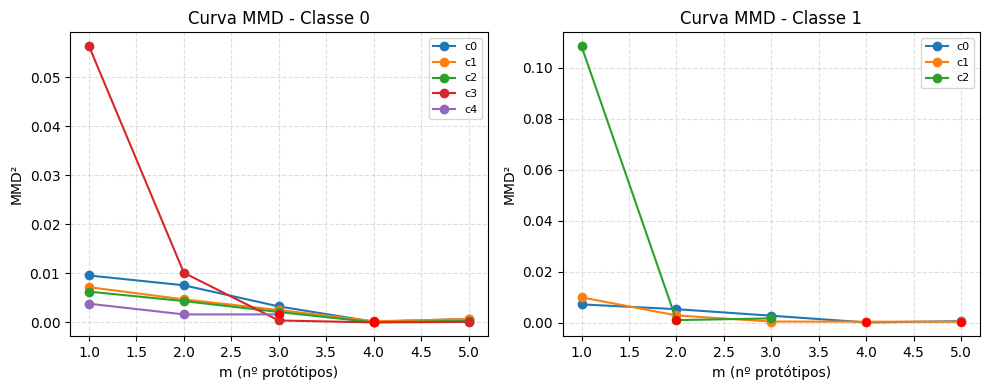

📈 Figura curvas MMD salva em: ../clusters_reports/xgboost/images/protodash_MMD_curvas_por_cluster.png
✅ ProtoDash+MMD concluído. Protos: 15 | Arquivos:
 - Prototipos:       ../clusters_reports/xgboost/csv/protodash_MMD_prototipos_por_classe_e_cluster.csv
 - Dataset sel.:     ../clusters_reports/xgboost/csv/protodash_MMD_dataset_selecionado_completo_classe_cluster.csv
 - Curvas MMD CSV:   ../clusters_reports/xgboost/csv/protodash_MMD_curve_por_cluster.csv
 - Curvas MMD PNG:   ../clusters_reports/xgboost/images/protodash_MMD_curvas_por_cluster.png
Prévia protótipos:
 classe  cluster  rank_no_cluster  idx_global_no_X_test  peso_protodash  mu_witness_cluster  dist_ao_medoid  dist_ao_medoid_pct  lof_outlier_score  mu_q10_cluster  lof_q90_cluster  rare_candidate          rare_reason kernel  gamma_value  m_selected_cluster  mmd2_cluster protodash_backend  weights_recomputed_nnls  sim_thinning_tau  rank_na_classe
      0        0                1                   429        0.931946          

,classe,cluster,rank_no_cluster,peso_protodash,rare_candidate,dist_ao_medoid_pct,mu_witness_cluster,kernel,gamma_value,m_selected_cluster,...,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,y,y_pred,y_proba,__cls_tmp__
429,0,0,1,0.931946,False,69.014085,0.931946,rbf,9.097826e-17,2,...,0.704777,1.384715,0.955891,0.727518,1.048961,1.038833,0,0,0.062867,0
345,0,0,2,0.014085,True,100.000000,0.014085,rbf,9.097826e-17,2,...,0.999217,1.135492,1.150568,-0.210331,0.744807,3.306078,0,0,0.007129,0
398,0,1,1,0.934090,False,86.274510,0.934090,rbf,6.119088e-17,2,...,-1.094440,-0.503368,-0.410944,-0.466478,-0.758160,-0.526532,0,0,0.000159,0
237,0,1,2,0.019608,True,99.019608,0.019608,rbf,6.119088e-17,2,...,0.097103,-0.160881,-0.160060,-0.168642,0.578635,-0.069223,0,0,0.000515,0
275,0,2,1,0.943066,False,75.409836,0.943066,rbf,7.459481e-17,2,...,-0.322631,-0.136010,-0.178299,-0.288102,-0.553412,0.090449,0,0,0.000462,0
399,0,2,2,0.016393,True,100.000000,0.016393,rbf,7.459481e-17,2,...,-1.195615,-0.873472,-0.839081,-0.846775,-0.870920,-1.198987,0,0,0.000434,0
219,0,3,1,0.815413,True,28.571429,0.815544,rbf,1.090228e-15,2,...,-0.241190,-0.298705,-0.377071,-0.344775,0.525223,0.249638,0,0,0.000147,0
224,0,3,2,0.141835,False,93.877551,0.142591,rbf,1.090228e-15,2,...,-0.604542,-0.594663,-0.572157,-0.381164,0.663205,-0.488423,0,0,0.000905,0
227,0,4,1,0.957428,False,79.220779,0.957428,rbf,5.013735e-17,2,...,0.404072,-0.179016,0.037223,0.299416,0.232938,-0.360589,0,0,0.001971,0
232,0,4,2,0.025400,True,98.701299,0.025400,rbf,5.013735e-17,2,...,-0.043853,-0.525130,-0.550456,-0.371684,0.557864,-0.758080,0,0,0.009679,0


In [14]:
# ProtoDash + MMD por (CLASSE, CLUSTER) SDFASFASDCSADF
# Ajustado para o contexto atual do notebook:
# - Usa X_test e results_by_class já produzidos anteriormente
# - Usa medoids/labels armazenados em results_by_class[cls]
# - Salva CSVs de protótipos, dataset selecionado e curvas MMD nas pastas corretas (csv / images)
# - É robusto à ausência do pacote aix360 (fallback greedy + NNLS simples)
# - Mantém exatamente 1 raro por cluster (definição híbrida)
# - Faz thinning por similaridade kernel preservando raro
# - Parâmetros podem ser sobrescritos via variáveis globais PROTO_*
# - Gera plot consolidado das curvas MMD por (classe, cluster)

import os, math, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import rbf_kernel, linear_kernel, pairwise_distances
from sklearn.neighbors import LocalOutlierFactor

# ----------------------------
# Diretórios de saída
# ----------------------------
# Convenção: se OUT_CSV / OUT_IMG já existem (definidos anteriormente no notebook) usamos; senão fallback em RESULTS_DIR
RESULTS_DIR = globals().get("RESULTS_DIR", str(globals().get('OUT_CSV', 'resultados_explainable_clustering')))
CSV_DIR = str(globals().get('OUT_CSV', RESULTS_DIR))
IMG_DIR = str(globals().get('OUT_IMG', os.path.join(RESULTS_DIR, 'images')))
os.makedirs(CSV_DIR, exist_ok=True)
os.makedirs(IMG_DIR, exist_ok=True)

# ----------------------------
# Parâmetros (personalizáveis via globals PROTO_*)
# ----------------------------
KERNEL = globals().get("PROTO_KERNEL", "rbf")           # "rbf" ou "linear"
GAMMA  = globals().get("PROTO_GAMMA", "scale")          # "scale", "auto" ou float
MMD_EPS       = globals().get("PROTO_MMD_EPS", 0.05)
MMD_PATIENCE  = globals().get("PROTO_MMD_PATIENCE", 1)
MMD_M_MAX_ABS = globals().get("PROTO_MMD_M_MAX_ABS", 6)
M_MAX_MODE    = globals().get("PROTO_M_MAX_MODE", "sqrt")  # "sqrt" ou "proportional"
M_MAX_ALPHA   = globals().get("PROTO_M_MAX_ALPHA", 0.6)
ENSURE_ONE_RARE = globals().get("PROTO_ENSURE_ONE_RARE", True)
RARE_PCT_DIST   = globals().get("PROTO_RARE_PCT_DIST", 95.0)
RARE_Q_MU       = globals().get("PROTO_RARE_Q_MU", 0.10)
RARE_Q_LOF      = globals().get("PROTO_RARE_Q_LOF", 0.90)
LOF_K_MAX       = globals().get("PROTO_LOF_K_MAX", 20)
LOF_K_MIN       = globals().get("PROTO_LOF_K_MIN", 5)
REDUNDANCY_SIM_TAU = globals().get("PROTO_REDUNDANCY_SIM_TAU", 0.85)
ID_COLS = globals().get("PROTO_ID_COLS", [])  # ex: ["patient_id"]

# Saídas (agora explícitas em CSV_DIR / IMG_DIR)
CSV_OUT       = os.path.join(CSV_DIR, "protodash_MMD_prototipos_por_classe_e_cluster.csv")
CSV_OUT_FULL  = os.path.join(CSV_DIR, "protodash_MMD_dataset_selecionado_completo_classe_cluster.csv")
CSV_MMD_CURVE = os.path.join(CSV_DIR, "protodash_MMD_curve_por_cluster.csv")
PNG_MMD_CURVE = os.path.join(IMG_DIR, "protodash_MMD_curvas_por_cluster.png")

# ----------------------------
# Pré-condições
# ----------------------------
if 'results_by_class' not in globals():
    raise RuntimeError("results_by_class não encontrado. Execute a célula de diagnóstico anterior.")
if 'X_test' not in globals():
    raise RuntimeError("X_test não encontrado no ambiente.")

# ----------------------------
# Helpers de kernel / gamma
# ----------------------------

def _resolve_gamma_value(XA):
    if KERNEL != "rbf":
        return np.nan
    if isinstance(GAMMA, (int, float)):
        return float(GAMMA)
    n_features = XA.shape[1]
    if GAMMA == "auto":
        return 1.0 / n_features
    var = np.var(XA, axis=0).mean()
    return 1.0 / (n_features * var if var > 0 else n_features)

def _compute_kernel_fixed(XA, XB, gamma_value):
    if KERNEL == "linear":
        return linear_kernel(XA, XB)
    return rbf_kernel(XA, XB, gamma=float(gamma_value))

# ----------------------------
# MMD² empírica
# ----------------------------

def _mmd2_ref_vs_weighted(X_ref, Z, alpha, gamma_value):
    if len(Z) == 0:
        return np.inf
    alpha = np.asarray(alpha, dtype=float)
    s = alpha.sum()
    if s > 1e-12:
        alpha = alpha / s
    K_xx = _compute_kernel_fixed(X_ref, X_ref, gamma_value).mean()
    K_xz = _compute_kernel_fixed(X_ref, Z, gamma_value).mean(axis=0)
    K_zz = _compute_kernel_fixed(Z, Z, gamma_value)
    return float(K_xx - 2.0 * np.dot(alpha, K_xz) + (alpha[:,None]*alpha[None,:]*K_zz).sum())

# ----------------------------
# Disponibilidade do AIX360
# ----------------------------
try:
    from aix360.algorithms.protodash import ProtodashSelection
    _AIX_AVAILABLE = True
except Exception:
    _AIX_AVAILABLE = False

# ----------------------------
# NNLS simples via gradiente projetado
# ----------------------------

def _nnls_weights_for_selected(K_cand_cand, mu_cand, selected_idx, iters=300):
    if len(selected_idx) == 0:
        return np.array([], dtype=float)
    Ks = K_cand_cand[np.ix_(selected_idx, selected_idx)] + 1e-8*np.eye(len(selected_idx))
    bs = mu_cand[selected_idx]
    w = np.zeros_like(bs)
    try:
        L = np.linalg.norm(Ks, 2)
    except Exception:
        L = np.linalg.norm(Ks) or 1.0
    lr = 0.1 / max(L,1.0)
    for _ in range(iters):
        grad = Ks @ w - bs
        w -= lr * grad
        w = np.maximum(w, 0.0)
    return w

# ----------------------------
# Fallback greedy se AIX360 indisponível
# ----------------------------

def _protodash_indices_fallback(X_ref, X_cand, m, gamma_value):
    n_cand = X_cand.shape[0]
    m = min(int(m), n_cand)
    if m <= 0:
        return np.array([], dtype=int), np.array([], dtype=float)
    K_ref_cand = _compute_kernel_fixed(X_ref, X_cand, gamma_value)
    K_cand_cand = _compute_kernel_fixed(X_cand, X_cand, gamma_value)
    mu = K_ref_cand.mean(axis=0)
    selected = []
    gains = mu.copy()
    for _ in range(m):
        gm = gains.copy()
        if selected:
            gm[selected] = -np.inf
        j = int(np.argmax(gm))
        if not np.isfinite(gm[j]):
            break
        selected.append(j)
        gains = mu - np.maximum.reduce([K_cand_cand[:, s] for s in selected])
    selected = np.array(selected, dtype=int)
    weights = _nnls_weights_for_selected(K_cand_cand, mu, selected)
    return selected, weights

# ----------------------------
# Wrapper ProtoDash
# ----------------------------

def _run_protodash_block(X_block, m, gamma_value):
    if m <= 0 or X_block.shape[0] == 0:
        return np.array([], dtype=int), np.array([], dtype=float), "fallback"
    if _AIX_AVAILABLE:
        proto = ProtodashSelection()
        S, W = proto.learn_prototypes(X_block, X_block, m)
        return np.array(S, dtype=int), np.array(W, dtype=float), "aix360"
    idx, w = _protodash_indices_fallback(X_block, X_block, m, gamma_value)
    return idx, w, "fallback"

# ----------------------------
# Teto m_max
# ----------------------------

def _cluster_m_cap(n_c):
    base = math.ceil(math.sqrt(n_c)) if M_MAX_MODE == "sqrt" else math.ceil(M_MAX_ALPHA * n_c)
    return max(1, min(base, n_c, MMD_M_MAX_ABS))

# ----------------------------
# Escolha de m por curva MMD
# ----------------------------

def _choose_m_by_mmd(X_block, gamma_value, eps=MMD_EPS, patience=MMD_PATIENCE):
    n = X_block.shape[0]
    m_cap = _cluster_m_cap(n)
    best = (None, None, None, np.inf, None)
    prev_mmd = None
    stalls = 0
    curve = []
    for m in range(1, m_cap + 1):
        sel, w, backend = _run_protodash_block(X_block, m, gamma_value)
        Z = X_block[sel]
        mmd = _mmd2_ref_vs_weighted(X_block, Z, w, gamma_value)
        curve.append((m, mmd))
        if best[0] is None or mmd < best[3]:
            best = (m, sel.copy(), w.copy(), mmd, backend)
        if prev_mmd is not None:
            rel = (prev_mmd - mmd) / max(prev_mmd, 1e-12)
            stalls = stalls + 1 if rel < eps else 0
            if stalls >= patience:
                break
        prev_mmd = mmd
    return best[0], best[1], best[2], best[3], best[4], curve

# ----------------------------
# Estatísticas locais + raridade
# ----------------------------

def _cluster_local_stats_and_rare(X_c, res_cls, idxs_loc_c, gamma_value):
    K_cc = _compute_kernel_fixed(X_c, X_c, gamma_value)
    mu = K_cc.mean(axis=0)
    dist_medoid_all = np.full(X_c.shape[0], np.nan)
    dist_pct_all = np.full(X_c.shape[0], np.nan)
    try:
        labels_loc = np.asarray(res_cls["labels"], dtype=int)
        c = int(np.unique(labels_loc[idxs_loc_c])[0])
        med_loc_in_cls = int(res_cls["medoids_local"][c])
        pos_in_cluster = np.where(idxs_loc_c == med_loc_in_cls)[0]
        if pos_in_cluster.size:
            med_pos = int(pos_in_cluster[0])
            D_c = pairwise_distances(X_c)
            dist_medoid_all = D_c[:, med_pos]
            dist_pct_all = np.array([(dist_medoid_all <= d).mean()*100.0 for d in dist_medoid_all])
        else:
            raise RuntimeError
    except Exception:
        D_c = pairwise_distances(X_c)
        med_pos = int(np.argmin(D_c.sum(axis=1)))
        dist_medoid_all = D_c[:, med_pos]
        dist_pct_all = np.array([(dist_medoid_all <= d).mean()*100.0 for d in dist_medoid_all])
    n = X_c.shape[0]
    if n >= LOF_K_MIN + 1:
        k = min(max(LOF_K_MIN, min(LOF_K_MAX, n - 1)), LOF_K_MAX)
        lof = LocalOutlierFactor(n_neighbors=k)
        lof.fit(X_c)
        lof_out_all = -lof.negative_outlier_factor_
    else:
        lof_out_all = np.full(n, np.nan)
    mu_q10  = float(np.nanquantile(mu, RARE_Q_MU))
    lof_q90 = float(np.nanquantile(lof_out_all, RARE_Q_LOF)) if np.isfinite(lof_out_all).any() else np.nan
    rare_mask_all = (
        (dist_pct_all >= RARE_PCT_DIST) |
        (mu <= mu_q10) |
        (np.where(np.isnan(lof_out_all), -np.inf, lof_out_all) >= (lof_q90 if np.isfinite(lof_q90) else np.inf))
    )
    return dict(mu=mu, dist_medoid_all=dist_medoid_all, dist_pct_all=dist_pct_all,
                lof_all=lof_out_all, mu_q10=mu_q10, lof_q90=lof_q90, rare_mask_all=rare_mask_all)

# ----------------------------
# Thinning por similaridade
# ----------------------------

def _thin_by_similarity(X_c, selected_idxs, gamma_value, sim_tau=REDUNDANCY_SIM_TAU, keep_rare_idx=None):
    if len(selected_idxs) <= 1:
        return np.asarray(selected_idxs, dtype=int)
    Z = X_c[selected_idxs]
    K_sel = _compute_kernel_fixed(Z, Z, gamma_value)
    keep = []
    order = list(range(len(selected_idxs)))
    if keep_rare_idx is not None:
        try:
            pos_rare = selected_idxs.tolist().index(int(keep_rare_idx))
            order.insert(0, order.pop(pos_rare))
        except Exception:
            pass
    for pos in order:
        if pos in keep:
            continue
        if not keep:
            keep.append(pos); continue
        sim_to_kept = np.max(K_sel[pos, keep])
        if sim_to_kept > sim_tau:
            continue
        keep.append(pos)
    keep = np.array(sorted(keep), dtype=int)
    return selected_idxs[keep]

# ----------------------------
# Loop principal (classe, cluster)
# ----------------------------
rows = []
mmd_curve_rows = []
for cls in sorted(results_by_class.keys()):
    res = results_by_class[cls]
    idx_global_cls = np.asarray(res["idx_global"], dtype=int)
    labels_loc = np.asarray(res["labels"], dtype=int)
    X_cls = X_test.iloc[idx_global_cls].values
    clusters = np.sort(np.unique(labels_loc))
    for c in clusters:
        idxs_loc_c = np.where(labels_loc == c)[0]
        if idxs_loc_c.size == 0: continue
        X_c = X_cls[idxs_loc_c]
        n_c = X_c.shape[0]
        if n_c == 0: continue
        gamma_value = _resolve_gamma_value(X_c)
        m_star, sel_loc_c, w_sel, mmd_star, backend, curve = _choose_m_by_mmd(X_c, gamma_value, eps=MMD_EPS, patience=MMD_PATIENCE)
        for m_val, mmd_val in curve:
            mmd_curve_rows.append({
                "classe": int(cls), "cluster": int(c), "m": int(m_val), "mmd2": float(mmd_val),
                "kernel": KERNEL, "gamma_value": float(gamma_value) if np.isfinite(gamma_value) else np.nan,
                "protodash_backend": backend
            })
        stats = _cluster_local_stats_and_rare(X_c, res, idxs_loc_c, gamma_value)
        weights_recomputed = False
        if ENSURE_ONE_RARE and sel_loc_c.size > 0:
            rare_mask_sel = stats["rare_mask_all"][sel_loc_c]
            rare_selected = np.where(rare_mask_sel)[0]
            if rare_selected.size == 0:
                rare_candidates = np.where(stats["rare_mask_all"])[0]
                if rare_candidates.size > 0:
                    def _rare_score(i):
                        return (float(stats["dist_pct_all"][i]), float(stats["lof_all"][i]) if np.isfinite(stats["lof_all"][i]) else -np.inf, float(-stats["mu"][i]))
                    add_idx = max(rare_candidates.tolist(), key=_rare_score)
                    if add_idx not in sel_loc_c.tolist():
                        sel_loc_c = np.append(sel_loc_c, add_idx)
                        K_cc = _compute_kernel_fixed(X_c, X_c, gamma_value)
                        mu_all = K_cc.mean(axis=0)
                        w_sel = _nnls_weights_for_selected(K_cc, mu_all, sel_loc_c)
                        weights_recomputed = True
                keep_rare_idx = add_idx if rare_candidates.size > 0 else None
            else:
                rare_global_idxs = sel_loc_c[rare_selected]
                def _rare_score(i):
                    return (float(stats["dist_pct_all"][i]), float(stats["lof_all"][i]) if np.isfinite(stats["lof_all"][i]) else -np.inf, float(-stats["mu"][i]))
                keep_rare_idx = max(rare_global_idxs.tolist(), key=_rare_score)
                to_keep = [i for i in sel_loc_c.tolist() if not stats["rare_mask_all"][i] or i == keep_rare_idx]
                if len(to_keep) != len(sel_loc_c):
                    sel_loc_c = np.array(to_keep, dtype=int)
                    K_cc = _compute_kernel_fixed(X_c, X_c, gamma_value)
                    mu_all = K_cc.mean(axis=0)
                    w_sel = _nnls_weights_for_selected(K_cc, mu_all, sel_loc_c)
                    weights_recomputed = True
        else:
            keep_rare_idx = None
        if w_sel.size:
            order = np.argsort(-w_sel); sel_loc_c = sel_loc_c[order]; w_sel = w_sel[order]
        sel_before = sel_loc_c.copy()
        sel_loc_c = _thin_by_similarity(X_c, sel_loc_c, gamma_value, sim_tau=REDUNDANCY_SIM_TAU, keep_rare_idx=keep_rare_idx)
        if sel_loc_c.shape[0] != sel_before.shape[0]:
            K_cc = _compute_kernel_fixed(X_c, X_c, gamma_value)
            mu_all = K_cc.mean(axis=0)
            w_sel = _nnls_weights_for_selected(K_cc, mu_all, sel_loc_c)
            weights_recomputed = True
        if w_sel.size:
            order = np.argsort(-w_sel); sel_loc_c = sel_loc_c[order]; w_sel = w_sel[order]
        Z_final = X_c[sel_loc_c]
        mmd_final = _mmd2_ref_vs_weighted(X_c, Z_final, w_sel, gamma_value)
        m_final = int(len(sel_loc_c))
        sel_loc_in_class = idxs_loc_c[sel_loc_c] if sel_loc_c.size else np.array([], dtype=int)
        sel_global = idx_global_cls[sel_loc_in_class] if sel_loc_in_class.size else np.array([], dtype=int)
        for rk, (loc_c_i, g, w) in enumerate(zip(sel_loc_c, sel_global, w_sel), start=1):
            is_rare = bool(stats["rare_mask_all"][loc_c_i])
            reasons = []
            if stats["dist_pct_all"][loc_c_i] >= RARE_PCT_DIST: reasons.append("dist_pct>=95")
            if stats["mu"][loc_c_i] <= stats["mu_q10"]: reasons.append("mu<=Q10")
            lof_q90 = stats["lof_q90"]; lof_val = stats["lof_all"][loc_c_i]
            if np.isfinite(lof_q90) and np.isfinite(lof_val) and (lof_val >= lof_q90): reasons.append("LOF>=Q90")
            rows.append({
                "classe": int(cls), "cluster": int(c), "rank_no_cluster": int(rk),
                "idx_global_no_X_test": int(g), "peso_protodash": float(w),
                "mu_witness_cluster": float(stats["mu"][loc_c_i]),
                "dist_ao_medoid": float(stats["dist_medoid_all"][loc_c_i]),
                "dist_ao_medoid_pct": float(stats["dist_pct_all"][loc_c_i]),
                "lof_outlier_score": float(lof_val) if np.isfinite(lof_val) else np.nan,
                "mu_q10_cluster": float(stats["mu_q10"]),
                "lof_q90_cluster": float(lof_q90) if np.isfinite(lof_q90) else np.nan,
                "rare_candidate": bool(is_rare),
                "rare_reason": "|".join(reasons),
                "kernel": KERNEL, "gamma_value": float(gamma_value) if np.isfinite(gamma_value) else np.nan,
                "m_selected_cluster": int(m_final), "mmd2_cluster": float(mmd_final),
                "protodash_backend": backend, "weights_recomputed_nnls": bool(weights_recomputed),
                "sim_thinning_tau": float(REDUNDANCY_SIM_TAU)
            })

# ----------------------------
# Consolidação
# ----------------------------
df_protos = pd.DataFrame(rows).sort_values(["classe","cluster","rank_no_cluster"]).reset_index(drop=True)
# Preencher ENTRADAS_SELECIONADAS_PROTODASH como dict {(classe, cluster): [iloc]} (iloc global do dataset completo)
if not df_protos.empty and 'classe' in df_protos.columns and 'cluster' in df_protos.columns and 'idx_global_no_X_test' in df_protos.columns:
    entradas_protodash = {}
    for (cls, clu), subdf in df_protos.groupby(['classe','cluster']):
        entradas_protodash[(int(cls), int(clu))] = subdf['idx_global_no_X_test'].astype(int).tolist()
    globals()['ENTRADAS_SELECIONADAS_PROTODASH'] = entradas_protodash
    print(f'ENTRADAS_SELECIONADAS_PROTODASH preenchida: {len(entradas_protodash)} chaves.')
else:
    print('⚠️ Não foi possível preencher ENTRADAS_SELECIONADAS_PROTODASH (faltam colunas esperadas em df_protos).')
if not df_protos.empty:
    df_protos["rank_na_classe"] = (
        df_protos.groupby("classe")["peso_protodash"].rank(ascending=False, method="first").astype(int)
    )
if ID_COLS and not df_protos.empty:
    try:
        ids_df = X_test.loc[df_protos["idx_global_no_X_test"], ID_COLS].reset_index(drop=True)
        df_protos = pd.concat([df_protos, ids_df], axis=1)
    except Exception as e:
        print(f"[Aviso] Falha ao anexar ID_COLS: {e}")

if not df_protos.empty:
    X_selected = X_test.iloc[df_protos["idx_global_no_X_test"].values].copy()
    meta_cols = ["classe","cluster","rank_no_cluster","peso_protodash","rare_candidate","dist_ao_medoid_pct",
                 "mu_witness_cluster","kernel","gamma_value","m_selected_cluster","mmd2_cluster",
                 "protodash_backend","weights_recomputed_nnls","sim_thinning_tau"]
    for i,col in enumerate(meta_cols):
        X_selected.insert(i, col, df_protos[col].values)
else:
    X_selected = pd.DataFrame()

# ----------------------------
# Salva CSVs
# ----------------------------
pd.DataFrame(mmd_curve_rows).to_csv(CSV_MMD_CURVE, index=False)
df_protos.to_csv(CSV_OUT, index=False)
X_selected.to_csv(CSV_OUT_FULL, index=False)

# ----------------------------
# Plot consolidado das curvas MMD (cada subfig = classe)
# ----------------------------
try:
    if mmd_curve_rows:
        df_curve = pd.DataFrame(mmd_curve_rows)
        classes = sorted(df_curve['classe'].unique())
        n_cls = len(classes)
        fig, axes = plt.subplots(1, n_cls, figsize=(5*n_cls,4), squeeze=False)
        axes = axes[0]
        for ax, cls in zip(axes, classes):
            sub = df_curve[df_curve['classe']==cls].copy()
            for cluster_id, g in sub.groupby('cluster'):
                g_sorted = g.sort_values('m')
                ax.plot(g_sorted['m'], g_sorted['mmd2'], marker='o', label=f"c{cluster_id}")
                # marca m* escolhido (menor mmd2 na curva daquele cluster)
                best_row = g_sorted.loc[g_sorted['mmd2'].idxmin()]
                ax.scatter([best_row['m']], [best_row['mmd2']], color='red', zorder=5, s=30)
            ax.set_title(f"Curva MMD - Classe {cls}")
            ax.set_xlabel('m (nº protótipos)')
            ax.set_ylabel('MMD²')
            ax.grid(True, ls='--', alpha=0.4)
            ax.legend(fontsize=8)
        plt.tight_layout()
        plt.savefig(PNG_MMD_CURVE, dpi=120, bbox_inches='tight')
        plt.show()
        print(f"📈 Figura curvas MMD salva em: {PNG_MMD_CURVE}")
except Exception as e:
    print(f"[Aviso] Falha ao gerar figura de curvas MMD: {e}")

print(f"✅ ProtoDash+MMD concluído. Protos: {len(df_protos)} | Arquivos:")
print(" - Prototipos:      ", CSV_OUT)
print(" - Dataset sel.:    ", CSV_OUT_FULL)
print(" - Curvas MMD CSV:  ", CSV_MMD_CURVE)
print(" - Curvas MMD PNG:  ", PNG_MMD_CURVE if os.path.exists(PNG_MMD_CURVE) else '(não gerado)')
print("Prévia protótipos:")
print(df_protos.head().to_string(index=False))
X_selected

In [15]:
# ProtoDash + MMD por (CLASSE, CLUSTER)
# - EPS=6%, PATIENCE=0 (cotovelo agressivo)
# - m_max = ceil(sqrt(n_c)) (com opção proporcional)
# - Garante exatamente 1 "raro" por cluster
# - Thinning por similaridade (kernel) mantendo o raro
# - Salva CSVs com kernel, gamma, MMD², backend, etc.
# ============================================

import os
import math
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import rbf_kernel, linear_kernel, pairwise_distances
from sklearn.neighbors import LocalOutlierFactor

# ----------------------------
# Parâmetros
# ----------------------------
RESULTS_DIR = globals().get("RESULTS_DIR", "resultados_explainable_clustering")
os.makedirs(RESULTS_DIR, exist_ok=True)



# Kernel do ProtoDash/MMD
KERNEL = "rbf"            # "rbf" ou "linear"
GAMMA  = "scale"          # "scale", "auto" ou float (para RBF)

# MMD: parada por cotovelo (por cluster)
MMD_EPS       = 0.05       # 6% de ganho relativo mínimo para continuar (5–8% sugerido)
MMD_PATIENCE  = 1        # para no primeiro passo com ganho < EPS
MMD_M_MAX_ABS = 6         # teto absoluto adicional de segurança

# Teto por cluster
M_MAX_MODE    = "sqrt"     # "sqrt" ou "proportional"
M_MAX_ALPHA   = 0.6        # usado se M_MAX_MODE == "proportional" -> teto = ceil(alpha * n_c)

# Raro (fenótipo periférico): garantir exatamente 1 por cluster
ENSURE_ONE_RARE    = True
RARE_PCT_DIST      = 95.0   # dist_ao_medoid_pct >= 95
RARE_Q_MU          = 0.10   # μ <= Q10
RARE_Q_LOF         = 0.90   # LOF >= Q90
LOF_K_MAX          = 20
LOF_K_MIN          = 5




# Thinning por similaridade (mantém raro)
REDUNDANCY_SIM_TAU = 0.85   # τ para kernel-similarity (RBF: 0.8–0.9 costuma funcionar)
# Observação: quanto maior τ, mais agressivo o corte (só remove muito parecidos)

# Colunas de ID opcionais do X_test (se existirem)
ID_COLS = []  # ex.: ["subject_id","hadm_id"]

# Saídas
CSV_OUT          = os.path.join(RESULTS_DIR, "protodash_MMD_prototipos_por_classe_e_cluster.csv")
CSV_OUT_FULL     = os.path.join(RESULTS_DIR, "protodash_MMD_dataset_selecionado_completo_classe_cluster.csv")
CSV_MMD_CURVE    = os.path.join(RESULTS_DIR, "protodash_MMD_curve_por_cluster.csv")

# ----------------------------
# Helpers de kernel
# ----------------------------
def _resolve_gamma_value(XA):
    """Devolve o gamma numérico a usar neste bloco (ou np.nan se KERNEL != 'rbf')."""
    if KERNEL != "rbf":
        return np.nan
    if isinstance(GAMMA, (int, float)):
        return float(GAMMA)
    n_features = XA.shape[1]
    if GAMMA == "auto":
        return 1.0 / n_features
    # "scale"
    var = np.var(XA, axis=0).mean()
    return 1.0 / (n_features * var if var > 0 else n_features)

def _compute_kernel_fixed(XA, XB, gamma_value):
    if KERNEL == "linear":
        return linear_kernel(XA, XB)
    return rbf_kernel(XA, XB, gamma=float(gamma_value))

# ----------------------------
# MMD empírica (normaliza alpha para somar 1)
# ----------------------------
def _mmd2_ref_vs_weighted(X_ref, Z, alpha, gamma_value):
    if len(Z) == 0:
        return np.inf
    alpha = np.asarray(alpha, dtype=float)
    s = float(alpha.sum())
    if s > 1e-12:
        alpha = alpha / s
    K_xx = _compute_kernel_fixed(X_ref, X_ref, gamma_value).mean()
    K_xz = _compute_kernel_fixed(X_ref, Z, gamma_value).mean(axis=0)   # (m,)
    K_zz = _compute_kernel_fixed(Z, Z, gamma_value)                    # (m,m)
    return float(K_xx - 2.0 * np.dot(alpha, K_xz) + (alpha[:,None]*alpha[None,:]*K_zz).sum())

# ----------------------------
# ProtoDash: AIX360 se disponível
# ----------------------------
_AIX_AVAILABLE = False
try:
    from aix360.algorithms.protodash import ProtodashSelection
    _AIX_AVAILABLE = True
except Exception:
    _AIX_AVAILABLE = False

# ----------------------------
# NNLS (pesos não-negativos) para selecionados
# ----------------------------
def _nnls_weights_for_selected(K_cand_cand, mu_cand, selected_idx, iters=300):
    if len(selected_idx) == 0:
        return np.array([], dtype=float)
    Ks = K_cand_cand[np.ix_(selected_idx, selected_idx)] + 1e-8 * np.eye(len(selected_idx))
    bs = mu_cand[selected_idx]
    w = np.zeros_like(bs, dtype=float)
    try:
        L = np.linalg.norm(Ks, 2)
    except Exception:
        L = np.linalg.norm(Ks) or 1.0
    lr = 0.1 / max(L, 1.0)
    for _ in range(iters):
        grad = Ks @ w - bs
        w -= lr * grad
        w = np.maximum(w, 0.0)
    return w

# ----------------------------
# Fallback de índices (greedy anti-redundância)
# ----------------------------
def _protodash_indices_fallback(X_ref, X_cand, m, gamma_value):
    n_cand = X_cand.shape[0]
    m = min(int(m), n_cand)
    if m <= 0:
        return np.array([], dtype=int), np.array([], dtype=float)
    K_ref_cand = _compute_kernel_fixed(X_ref, X_cand, gamma_value)   # (n_ref, n_cand)
    K_cand_cand = _compute_kernel_fixed(X_cand, X_cand, gamma_value) # (n_cand, n_cand)
    mu = K_ref_cand.mean(axis=0)                                     # (n_cand,)
    selected = []
    gains = mu.copy()
    for _ in range(m):
        gm = gains.copy()
        if selected:
            gm[selected] = -np.inf
        j = int(np.argmax(gm))
        if not np.isfinite(gm[j]):
            break
        selected.append(j)
        gains = mu - np.maximum.reduce([K_cand_cand[:, s] for s in selected])
    selected = np.array(selected, dtype=int)
    weights = _nnls_weights_for_selected(K_cand_cand, mu, selected)
    return selected, weights

# ----------------------------
# Wrapper ProtoDash (retorna índices, pesos, backend)
# ----------------------------
def _run_protodash_block(X_block, m, gamma_value):
    if m <= 0 or X_block.shape[0] == 0:
        return np.array([], dtype=int), np.array([], dtype=float), "fallback"
    if _AIX_AVAILABLE:
        proto = ProtodashSelection()
        S, W = proto.learn_prototypes(X_block, X_block, m)
        return np.array(S, dtype=int), np.array(W, dtype=float), "aix360"
    idx, w = _protodash_indices_fallback(X_block, X_block, m, gamma_value)
    return idx, w, "fallback"

# ----------------------------
# Teto m_max por cluster
# ----------------------------
def _cluster_m_cap(n_c):
    base = math.ceil(math.sqrt(n_c)) if M_MAX_MODE == "sqrt" else math.ceil(M_MAX_ALPHA * n_c)
    return max(1, min(base, n_c, MMD_M_MAX_ABS))

# ----------------------------
# Escolha de m por MMD (cotovelo) — por cluster
# ----------------------------
def _choose_m_by_mmd(X_block, gamma_value, eps=MMD_EPS, patience=MMD_PATIENCE):
    n = X_block.shape[0]
    m_cap = _cluster_m_cap(n)
    best = (None, None, None, np.inf, None)  # (m, sel_idx, w, mmd, backend)
    prev_mmd = None
    stalls = 0
    curve = []
    for m in range(1, m_cap + 1):
        sel, w, backend = _run_protodash_block(X_block, m, gamma_value)
        Z = X_block[sel]
        mmd = _mmd2_ref_vs_weighted(X_block, Z, w, gamma_value)
        curve.append((m, mmd))
        if best[0] is None or mmd < best[3]:
            best = (m, sel.copy(), w.copy(), mmd, backend)
        if prev_mmd is not None:
            rel = (prev_mmd - mmd) / max(prev_mmd, 1e-12)
            stalls = stalls + 1 if rel < eps else 0
            if stalls >= patience:
                break
        prev_mmd = mmd
    return best[0], best[1], best[2], best[3], best[4], curve

# ----------------------------
# Métricas locais + raridade por cluster
# ----------------------------
def _cluster_local_stats_and_rare(X_c, res_cls, idxs_loc_c, gamma_value):
    K_cc = _compute_kernel_fixed(X_c, X_c, gamma_value)
    mu = K_cc.mean(axis=0)

    # distância ao medoid (percentil)
    dist_medoid_all = np.full(X_c.shape[0], np.nan, dtype=float)
    dist_pct_all    = np.full(X_c.shape[0], np.nan, dtype=float)
    try:
        labels_loc = np.asarray(res_cls["labels"], dtype=int)
        c = int(np.unique(labels_loc[idxs_loc_c])[0])
        med_loc_in_cls = int(res_cls["medoids_local"][c])
        pos_in_cluster = np.where(idxs_loc_c == med_loc_in_cls)[0]
        if pos_in_cluster.size:
            med_pos = int(pos_in_cluster[0])
            D_c = pairwise_distances(X_c, metric="euclidean")
            dist_medoid_all = D_c[:, med_pos]
            dist_pct_all = np.array([(dist_medoid_all <= d).mean() * 100.0 for d in dist_medoid_all], dtype=float)
        else:
            raise RuntimeError("Medoid não mapeável ao cluster; fallback.")
    except Exception:
        D_c = pairwise_distances(X_c, metric="euclidean")
        med_pos = int(np.argmin(D_c.sum(axis=1)))
        dist_medoid_all = D_c[:, med_pos]
        dist_pct_all = np.array([(dist_medoid_all <= d).mean() * 100.0 for d in dist_medoid_all], dtype=float)

    # LOF
    n = X_c.shape[0]
    if n >= LOF_K_MIN + 1:
        k = min(max(LOF_K_MIN, min(LOF_K_MAX, n - 1)), LOF_K_MAX)
        lof = LocalOutlierFactor(n_neighbors=k, novelty=False)
        lof.fit(X_c)
        lof_out_all = -lof.negative_outlier_factor_
    else:
        lof_out_all = np.full(n, np.nan, dtype=float)

    mu_q10  = float(np.nanquantile(mu, RARE_Q_MU))
    lof_q90 = float(np.nanquantile(lof_out_all, RARE_Q_LOF)) if np.isfinite(lof_out_all).any() else np.nan
    rare_mask_all = (
        (dist_pct_all >= RARE_PCT_DIST) |
        (mu <= mu_q10) |
        (np.where(np.isnan(lof_out_all), -np.inf, lof_out_all) >= (lof_q90 if np.isfinite(lof_q90) else np.inf))
    )
    return dict(
        mu=mu, dist_medoid_all=dist_medoid_all, dist_pct_all=dist_pct_all,
        lof_all=lof_out_all, mu_q10=mu_q10, lof_q90=lof_q90, rare_mask_all=rare_mask_all
    )

# ----------------------------
# Thinning por similaridade (kernel), preservando o raro
# selected_idxs: array de índices locais no cluster (ordenados por peso desc)
# keep_rare_idx: índice local no cluster do raro a preservar (ou None)
# ----------------------------
def _thin_by_similarity(X_c, selected_idxs, gamma_value, sim_tau=REDUNDANCY_SIM_TAU, keep_rare_idx=None):
    if len(selected_idxs) <= 1:
        return np.asarray(selected_idxs, dtype=int)
    # matriz de similaridade kernel entre selecionados
    Z = X_c[selected_idxs]
    K_sel = _compute_kernel_fixed(Z, Z, gamma_value)
    keep = []
    # garanta que o raro, se existir, entre primeiro
    order = list(range(len(selected_idxs)))
    if keep_rare_idx is not None:
        try:
            pos_rare = selected_idxs.tolist().index(int(keep_rare_idx))
            # coloca o raro na frente
            order.insert(0, order.pop(pos_rare))
        except Exception:
            pass
    for pos in order:
        if pos in keep:
            continue
        # similaridade com os já mantidos
        if not keep:
            keep.append(pos)
            continue
        sim_to_kept = np.max(K_sel[pos, keep])
        if sim_to_kept > sim_tau:
            # muito parecido com algo já mantido -> descarta
            continue
        keep.append(pos)
    keep = np.array(sorted(keep), dtype=int)
    return selected_idxs[keep]

# ----------------------------
# Loop principal por (classe, cluster)
# ----------------------------
rows = []
mmd_curve_rows = []

for cls in sorted(results_by_class.keys()):
    res = results_by_class[cls]
    idx_global_cls = np.asarray(res["idx_global"], dtype=int)
    labels_loc = np.asarray(res["labels"], dtype=int)
    X_cls = X_test.iloc[idx_global_cls].values
    clusters = np.sort(np.unique(labels_loc))

    for c in clusters:
        idxs_loc_c = np.where(labels_loc == c)[0]
        if idxs_loc_c.size == 0:
            continue

        X_c = X_cls[idxs_loc_c]
        n_c = X_c.shape[0]
        if n_c == 0:
            continue

        gamma_value = _resolve_gamma_value(X_c)

        # 1) MMD (cotovelo) escolhe m* e seleção base
        m_star, sel_loc_c, w_sel, mmd_star, backend, curve = _choose_m_by_mmd(
            X_c, gamma_value, eps=MMD_EPS, patience=MMD_PATIENCE
        )

        # curva MMD para auditoria
        for m_val, mmd_val in curve:
            mmd_curve_rows.append({
                "classe": int(cls), "cluster": int(c),
                "m": int(m_val), "mmd2": float(mmd_val),
                "kernel": KERNEL, "gamma_value": float(gamma_value) if np.isfinite(gamma_value) else np.nan,
                "protodash_backend": backend
            })

        # 2) Métricas locais + raridade
        stats = _cluster_local_stats_and_rare(X_c, res, idxs_loc_c, gamma_value)

        # 3) Garantir exatamente 1 raro
        weights_recomputed = False
        if ENSURE_ONE_RARE and sel_loc_c.size > 0:
            rare_mask_sel = stats["rare_mask_all"][sel_loc_c]
            rare_selected = np.where(rare_mask_sel)[0]  # posições dentro de sel_loc_c
            if rare_selected.size == 0:
                # adicionar um raro (o mais "raro": maior dist_pct, depois LOF, depois menor μ)
                rare_candidates = np.where(stats["rare_mask_all"])[0]
                if rare_candidates.size > 0:
                    def _rare_score(i):
                        d = stats["dist_pct_all"][i]
                        l = stats["lof_all"][i] if np.isfinite(stats["lof_all"][i]) else -np.inf
                        mu_i = stats["mu"][i]
                        return (float(d), float(l), float(-mu_i))
                    add_idx = max(rare_candidates.tolist(), key=_rare_score)
                    if add_idx not in sel_loc_c.tolist():
                        sel_loc_c = np.append(sel_loc_c, add_idx)
                        # repondera com NNLS no kernel do cluster
                        K_cc = _compute_kernel_fixed(X_c, X_c, gamma_value)
                        mu_all = _compute_kernel_fixed(X_c, X_c, gamma_value).mean(axis=0)
                        w_sel = _nnls_weights_for_selected(K_cc, mu_all, sel_loc_c)
                        weights_recomputed = True
                # define raro a preservar
                keep_rare_idx = add_idx if rare_candidates.size > 0 else None
            else:
                # já existem raros; ficar apenas com 1 (o "melhor raro")
                rare_global_idxs = sel_loc_c[rare_selected]  # índices locais no cluster
                def _rare_score(i):
                    d = stats["dist_pct_all"][i]
                    l = stats["lof_all"][i] if np.isfinite(stats["lof_all"][i]) else -np.inf
                    mu_i = stats["mu"][i]
                    return (float(d), float(l), float(-mu_i))
                keep_rare_idx = max(rare_global_idxs.tolist(), key=_rare_score)
                # filtra: remove outros raros
                to_keep = [i for i in sel_loc_c.tolist() if not stats["rare_mask_all"][i] or i == keep_rare_idx]
                if len(to_keep) != len(sel_loc_c):
                    sel_loc_c = np.array(to_keep, dtype=int)
                    # repondera
                    K_cc = _compute_kernel_fixed(X_c, X_c, gamma_value)
                    mu_all = K_cc.mean(axis=0)
                    w_sel = _nnls_weights_for_selected(K_cc, mu_all, sel_loc_c)
                    weights_recomputed = True
        else:
            keep_rare_idx = None

        # 4) Ordena por peso desc antes do thinning
        if w_sel.size:
            order = np.argsort(-w_sel)
            sel_loc_c = sel_loc_c[order]
            w_sel = w_sel[order]

        # 5) Thinning por similaridade, preservando raro
        sel_before = sel_loc_c.copy()
        sel_loc_c = _thin_by_similarity(X_c, sel_loc_c, gamma_value,
                                        sim_tau=REDUNDANCY_SIM_TAU,
                                        keep_rare_idx=keep_rare_idx)
        if sel_loc_c.shape[0] != sel_before.shape[0]:
            # repondera pesos e recalcula MMD do conjunto final
            K_cc = _compute_kernel_fixed(X_c, X_c, gamma_value)
            mu_all = K_cc.mean(axis=0)
            w_sel = _nnls_weights_for_selected(K_cc, mu_all, sel_loc_c)
            weights_recomputed = True

        # 6) Ordena por peso desc após thinning
        if w_sel.size:
            order = np.argsort(-w_sel)
            sel_loc_c = sel_loc_c[order]
            w_sel = w_sel[order]

        # 7) MMD final do cluster com o conjunto definitivo
        Z_final = X_c[sel_loc_c]
        mmd_final = _mmd2_ref_vs_weighted(X_c, Z_final, w_sel, gamma_value)
        m_final = int(len(sel_loc_c))

        # 8) Map para índices globais
        sel_loc_in_class = idxs_loc_c[sel_loc_c] if sel_loc_c.size else np.array([], dtype=int)
        sel_global = idx_global_cls[sel_loc_in_class] if sel_loc_in_class.size else np.array([], dtype=int)

        # 9) Registrar linhas
        for rk, (loc_c, g, w) in enumerate(zip(sel_loc_c, sel_global, w_sel), start=1):
            is_rare = bool(stats["rare_mask_all"][loc_c])
            reasons = []
            if stats["dist_pct_all"][loc_c] >= RARE_PCT_DIST: reasons.append("dist_pct>=95")
            if stats["mu"][loc_c] <= stats["mu_q10"]: reasons.append("mu<=Q10")
            lof_q90 = stats["lof_q90"]; lof_val = stats["lof_all"][loc_c]
            if np.isfinite(lof_q90) and np.isfinite(lof_val) and (lof_val >= lof_q90): reasons.append("LOF>=Q90")
            rows.append({
                "classe": int(cls),
                "cluster": int(c),
                "rank_no_cluster": int(rk),
                "idx_global_no_X_test": int(g),
                "peso_protodash": float(w),
                # métricas locais
                "mu_witness_cluster": float(stats["mu"][loc_c]),
                "dist_ao_medoid": float(stats["dist_medoid_all"][loc_c]),
                "dist_ao_medoid_pct": float(stats["dist_pct_all"][loc_c]),
                "lof_outlier_score": float(lof_val) if np.isfinite(lof_val) else np.nan,
                "mu_q10_cluster": float(stats["mu_q10"]),
                "lof_q90_cluster": float(lof_q90) if np.isfinite(lof_q90) else np.nan,
                "rare_candidate": bool(is_rare),
                "rare_reason": "|".join(reasons),
                # infos do bloco
                "kernel": KERNEL,
                "gamma_value": float(gamma_value) if np.isfinite(gamma_value) else np.nan,
                "m_selected_cluster": int(m_final),
                "mmd2_cluster": float(mmd_final),
                "protodash_backend": backend,
                "weights_recomputed_nnls": bool(weights_recomputed),
                "sim_thinning_tau": float(REDUNDANCY_SIM_TAU)
            })

# ----------------------------
# Consolida DataFrame + ranks por classe + IDs
# ----------------------------
df_protos = pd.DataFrame(rows).sort_values(
    ["classe", "cluster", "rank_no_cluster"]
).reset_index(drop=True)

if not df_protos.empty:
    df_protos["rank_na_classe"] = (
        df_protos.groupby("classe")["peso_protodash"]
        .rank(ascending=False, method="first")
        .astype(int)
    )

if ID_COLS:
    ids_df = X_test.loc[df_protos["idx_global_no_X_test"], ID_COLS].reset_index(drop=True)
    df_protos = pd.concat([df_protos, ids_df], axis=1)

# ----------------------------
# Dataset completo das instâncias selecionadas
# ----------------------------
if not df_protos.empty:
    X_selected = X_test.iloc[df_protos["idx_global_no_X_test"].values].copy()
    X_selected.insert(0, "classe", df_protos["classe"].values)
    X_selected.insert(1, "cluster", df_protos["cluster"].values)
    X_selected.insert(2, "rank_no_cluster", df_protos["rank_no_cluster"].values)
    X_selected.insert(3, "peso_protodash", df_protos["peso_protodash"].values)
    X_selected.insert(4, "rare_candidate", df_protos["rare_candidate"].values)
    X_selected.insert(5, "dist_ao_medoid_pct", df_protos["dist_ao_medoid_pct"].values)
    X_selected.insert(6, "mu_witness_cluster", df_protos["mu_witness_cluster"].values)
    X_selected.insert(7, "kernel", df_protos["kernel"].values)
    X_selected.insert(8, "gamma_value", df_protos["gamma_value"].values)
    X_selected.insert(9, "m_selected_cluster", df_protos["m_selected_cluster"].values)
    X_selected.insert(10, "mmd2_cluster", df_protos["mmd2_cluster"].values)
    X_selected.insert(11, "protodash_backend", df_protos["protodash_backend"].values)
    X_selected.insert(12, "weights_recomputed_nnls", df_protos["weights_recomputed_nnls"].values)
    X_selected.insert(13, "sim_thinning_tau", df_protos["sim_thinning_tau"].values)
else:
    X_selected = pd.DataFrame()

# ----------------------------
# Salva CSVs
# ----------------------------
df_protos.to_csv(CSV_OUT, index=False)
print(f"✅ ProtoDash + MMD (classe+cluster) com thinning concluído. CSV salvo em:\n{CSV_OUT}")

X_selected.to_csv(CSV_OUT_FULL, index=False)
print(f"✅ Dataset das instâncias selecionadas salvo em:\n{CSV_OUT_FULL}")

# Curva MMD por cluster
pd.DataFrame(mmd_curve_rows).to_csv(CSV_MMD_CURVE, index=False)
print(f"📈 Curvas MMD por cluster salvas em:\n{CSV_MMD_CURVE}")
X_selected


✅ ProtoDash + MMD (classe+cluster) com thinning concluído. CSV salvo em:
../clusters_reports/xgboost/csv/protodash_MMD_prototipos_por_classe_e_cluster.csv
✅ Dataset das instâncias selecionadas salvo em:
../clusters_reports/xgboost/csv/protodash_MMD_dataset_selecionado_completo_classe_cluster.csv
📈 Curvas MMD por cluster salvas em:
../clusters_reports/xgboost/csv/protodash_MMD_curve_por_cluster.csv


,classe,cluster,rank_no_cluster,peso_protodash,rare_candidate,dist_ao_medoid_pct,mu_witness_cluster,kernel,gamma_value,m_selected_cluster,...,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,y,y_pred,y_proba,__cls_tmp__
429,0,0,1,0.931946,False,69.014085,0.931946,rbf,9.097826e-17,2,...,0.704777,1.384715,0.955891,0.727518,1.048961,1.038833,0,0,0.062867,0
345,0,0,2,0.014085,True,100.000000,0.014085,rbf,9.097826e-17,2,...,0.999217,1.135492,1.150568,-0.210331,0.744807,3.306078,0,0,0.007129,0
398,0,1,1,0.934090,False,86.274510,0.934090,rbf,6.119088e-17,2,...,-1.094440,-0.503368,-0.410944,-0.466478,-0.758160,-0.526532,0,0,0.000159,0
237,0,1,2,0.019608,True,99.019608,0.019608,rbf,6.119088e-17,2,...,0.097103,-0.160881,-0.160060,-0.168642,0.578635,-0.069223,0,0,0.000515,0
275,0,2,1,0.943066,False,75.409836,0.943066,rbf,7.459481e-17,2,...,-0.322631,-0.136010,-0.178299,-0.288102,-0.553412,0.090449,0,0,0.000462,0
399,0,2,2,0.016393,True,100.000000,0.016393,rbf,7.459481e-17,2,...,-1.195615,-0.873472,-0.839081,-0.846775,-0.870920,-1.198987,0,0,0.000434,0
219,0,3,1,0.815413,True,28.571429,0.815544,rbf,1.090228e-15,2,...,-0.241190,-0.298705,-0.377071,-0.344775,0.525223,0.249638,0,0,0.000147,0
224,0,3,2,0.141835,False,93.877551,0.142591,rbf,1.090228e-15,2,...,-0.604542,-0.594663,-0.572157,-0.381164,0.663205,-0.488423,0,0,0.000905,0
227,0,4,1,0.957428,False,79.220779,0.957428,rbf,5.013735e-17,2,...,0.404072,-0.179016,0.037223,0.299416,0.232938,-0.360589,0,0,0.001971,0
232,0,4,2,0.025400,True,98.701299,0.025400,rbf,5.013735e-17,2,...,-0.043853,-0.525130,-0.550456,-0.371684,0.557864,-0.758080,0,0,0.009679,0


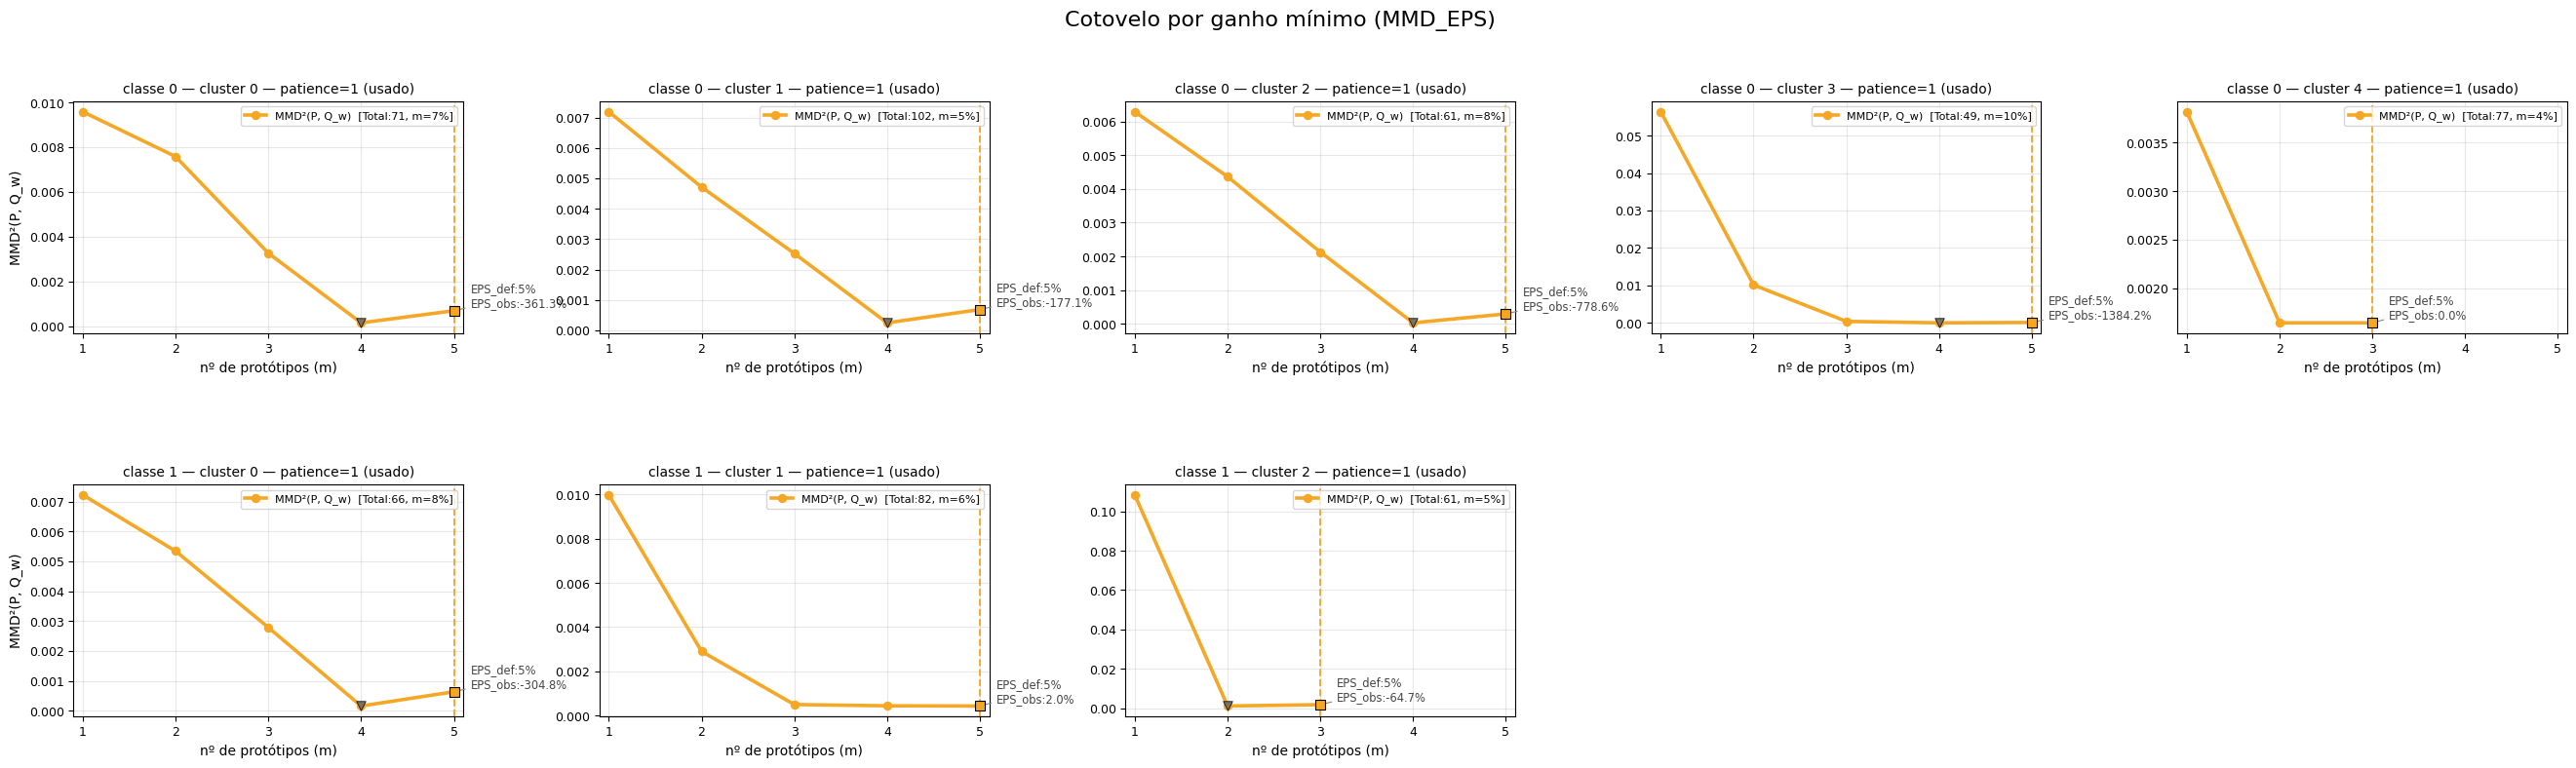

📈 Figura salva em: ../clusters_reports/xgboost/images/cotovelo_grid_eps_obs_vs_def.png | EPS_def: 0.05 | patience: 1
✅ Resumo cotovelo salvo em: ../clusters_reports/xgboost/csv/cotovelo_resumo_m_stop_eps_obs.csv
Prévia:
 classe  cluster  m_stop    eps_obs  EPS_def  patience  N_cluster  pct_m_stop_%
      0        0       5  -3.613430     0.05         1         71      7.042254
      0        1       5  -1.771409     0.05         1        102      4.901961
      0        2       5  -7.786006     0.05         1         61      8.196721
      0        3       5 -13.842209     0.05         1         49     10.204082
      0        4       3   0.000004     0.05         1         77      3.896104


In [16]:
# COTOVELO (por cluster) — mostra EPS_def e EPS_obs na anotação + salva CSV/PNG nos diretórios padronizados
# Ajustes:
# - Usa MMD_EPS, MMD_PATIENCE (ou defaults) já definidos
# - Salva figura em OUT_IMG (se existir) ou RESULTS_DIR/images
# - Salva CSV com resumo de m_stop, eps_obs, N_cluster, pct_m_stop
# - Anota EPS_def e EPS_obs no gráfico
# ============================================================
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt

# --- Carrega curvas ---
if "CSV_MMD_CURVE" in globals() and os.path.exists(CSV_MMD_CURVE):
    df_curve = pd.read_csv(CSV_MMD_CURVE)
elif "mmd_curve_rows" in globals():
    df_curve = pd.DataFrame(mmd_curve_rows)
else:
    raise RuntimeError("Não encontrei CSV_MMD_CURVE nem mmd_curve_rows.")

need = {"classe","cluster","m","mmd2"}
if not need.issubset(df_curve.columns):
    raise ValueError(f"Esperava colunas {need}, recebi {df_curve.columns.tolist()}")

# --- Parâmetros ---
EPS = float(globals().get("MMD_EPS", 0.06))
PATIENCE = int(globals().get("MMD_PATIENCE", 0))
RESULTS_DIR = globals().get("RESULTS_DIR", ".")
CSV_DIR = str(globals().get('OUT_CSV', RESULTS_DIR))
IMG_DIR = str(globals().get('OUT_IMG', os.path.join(RESULTS_DIR, 'images')))
os.makedirs(CSV_DIR, exist_ok=True)
os.makedirs(IMG_DIR, exist_ok=True)

# --- Helpers ---
def stop_by_eps_with_obs(m_list, y_list, eps=0.06, patience=0):
    prev, stalls = None, 0
    eps_obs_at_stop = None
    for i, cur in enumerate(y_list):
        if i == 0:
            prev = cur
            continue
        rel = (prev - cur) / max(prev, 1e-12)
        if rel < eps:
            stalls += 1
        else:
            stalls = 0
        if stalls >= patience:
            return int(m_list[i]), float(rel), bool(patience > 0)
        prev = cur
    last_rel = float((y_list[-2]-y_list[-1]) / max(y_list[-2], 1e-12)) if len(y_list) >= 2 else np.nan
    return int(m_list[-1]), last_rel, False

def local_minima_idx(y, tol=1e-12):
    idx=[]
    for i in range(1,len(y)-1):
        if (y[i] < y[i-1]-tol) and (y[i] <= y[i+1]+tol):
            idx.append(i)
    return idx

def cluster_size_from_results(cls, c):
    if "results_by_class" in globals():
        res = results_by_class.get(cls)
        if res is not None and "labels" in res:
            labels = np.asarray(res["labels"], dtype=int)
            return int(np.sum(labels == c))
    return None

# --- Estética ---
plt.rcParams.update({
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})
line_color = "#f5a623"
line_w, marker_size = 2.6, 5.8
square_size, tri_size = 58, 46

MAX_M_PLOT = int(df_curve['m'].max()) if df_curve['m'].max() <= 15 else 15  # limite razoável
XTICKS = np.arange(1, MAX_M_PLOT + 1, 1)
X_LIM   = (0.9, MAX_M_PLOT + 0.1)

# --- clusters por classe (dinâmico) ---
clusters_by_class = {
    cls: sorted(df_curve.loc[df_curve["classe"]==cls, "cluster"].unique().tolist())
    for cls in sorted(df_curve['classe'].unique())
}
classes_sorted = sorted(clusters_by_class.keys())
rows_fig = len(classes_sorted)
cols_fig = max(len(v) for v in clusters_by_class.values())

fig, axes = plt.subplots(rows_fig, cols_fig, figsize=(6.6*cols_fig, 4.1*rows_fig), constrained_layout=False, sharey=False)
if rows_fig == 1 and cols_fig == 1:
    axes = np.array([[axes]])
elif rows_fig == 1:
    axes = np.array([axes])
elif cols_fig == 1:
    axes = np.array([[ax] for ax in axes])

summary_rows = []

for r, cls in enumerate(classes_sorted):
    cls_clusters = clusters_by_class[cls]
    for c_idx in range(cols_fig):
        ax = axes[r, c_idx]
        if c_idx >= len(cls_clusters):
            ax.axis("off"); continue
        c = cls_clusters[c_idx]
        sub = df_curve[(df_curve["classe"] == cls) & (df_curve["cluster"] == c)].sort_values("m")
        sub = sub[sub["m"] <= MAX_M_PLOT]
        if sub.empty:
            ax.axis("off"); continue
        m_vals = sub["m"].to_numpy(); y_vals = sub["mmd2"].to_numpy()
        m_stop, eps_obs, used_pat = stop_by_eps_with_obs(m_vals, y_vals, eps=EPS, patience=PATIENCE)
        y_stop = float(y_vals[np.where(m_vals == m_stop)][0])
        N_c = cluster_size_from_results(cls, c)
        legend_suffix = ""
        pct_m = np.nan
        if N_c and N_c > 0:
            pct_m = 100.0 * m_stop / N_c
            legend_suffix = f"  [Total:{N_c}, m={int(round(pct_m))}%]"
        # curva
        ax.plot(m_vals, y_vals, color=line_color, linewidth=line_w, marker="o", markersize=marker_size,
                alpha=0.98, label=f"MMD²(P, Q_w){legend_suffix}")
        # mínimos locais
        mins = local_minima_idx(y_vals)
        if mins:
            ax.scatter(m_vals[mins], y_vals[mins], marker="v", s=tri_size, c="#6d6d6d", edgecolors="k", linewidths=0.6, alpha=0.9, zorder=3)
        # parada
        ax.scatter([m_stop], [y_stop], marker="s", s=square_size, c=line_color, edgecolors="k", linewidths=0.8, zorder=4)
        ax.axvline(m_stop, linestyle="--", linewidth=1.4, color=line_color, alpha=0.95)
        # anotação
        eps_def_pct = int(round(EPS*100))
        eps_obs_pct = (np.nan if not np.isfinite(eps_obs) else round(100.0*eps_obs, 1))
        ax.annotate(f"EPS_def:{eps_def_pct}%\nEPS_obs:{eps_obs_pct}%", xy=(m_stop, y_stop),
                    xytext=(m_stop+0.18, y_stop + 0.02*(y_vals.max()-y_vals.min()+1e-12)), fontsize=8.3, color="#444444",
                    arrowprops=dict(arrowstyle="-", color="#888888", lw=0.8))
        # eixos
        ax.set_xticks(XTICKS); ax.set_xlim(*X_LIM)
        ax.set_xlabel("nº de protótipos (m)")
        if c_idx == 0:
            ax.set_ylabel("MMD²(P, Q_w)")
        usado = "usado" if PATIENCE > 0 else "não usado"
        ax.set_title(f"classe {cls} — cluster {c} — patience={PATIENCE} ({usado})")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper right", frameon=True, fontsize=8)
        summary_rows.append({
            "classe": int(cls), "cluster": int(c), "m_stop": int(m_stop), "eps_obs": float(eps_obs),
            "EPS_def": float(EPS), "patience": int(PATIENCE), "N_cluster": int(N_c) if N_c else np.nan,
            "pct_m_stop_%": float(pct_m) if np.isfinite(pct_m) else np.nan
        })

fig.subplots_adjust(wspace=0.35, hspace=0.65)
fig.suptitle("Cotovelo por ganho mínimo (MMD_EPS)", y=0.995, fontsize=16)

# --- Salva figura e CSV resumo ---
out_png = os.path.join(IMG_DIR, "cotovelo_grid_eps_obs_vs_def.png")
fig.savefig(out_png, dpi=150, bbox_inches="tight")
plt.show()
print("📈 Figura salva em:", out_png, "| EPS_def:", EPS, "| patience:", PATIENCE)

cotovelo_summary_df = pd.DataFrame(summary_rows).sort_values(["classe","cluster"]).reset_index(drop=True)
out_csv = os.path.join(CSV_DIR, "cotovelo_resumo_m_stop_eps_obs.csv")
cotovelo_summary_df.to_csv(out_csv, index=False)
print("✅ Resumo cotovelo salvo em:", out_csv)
print("Prévia:")
print(cotovelo_summary_df.head().to_string(index=False))

In [17]:
# MÉTRICAS ENXUTAS + AVALIAÇÃO COM FOLGA (SLACK)
# Gera df_protos_metrics e df_cluster_metrics (+ CSVs) nos diretórios padronizados
# ============================================================
import numpy as np
import pandas as pd
import os
from sklearn.metrics.pairwise import pairwise_distances

# ---------- Parâmetros ----------
RANDOM_BASELINE_REPEATS = 21
SEED = 42
rng = np.random.default_rng(SEED)

# Folga global (ex.: 0.05 = 5%, 0.10 = 10%)
SLACK = globals().get('SLACK', 0.01)

RESULTS_DIR = globals().get("RESULTS_DIR", ".")
CSV_DIR = str(globals().get('OUT_CSV', RESULTS_DIR))
os.makedirs(CSV_DIR, exist_ok=True)

CSV_PROTOS  = os.path.join(CSV_DIR, "protodash_repr_por_prototipo.csv")
CSV_CLUSTER = os.path.join(CSV_DIR, "protodash_repr_por_cluster.csv")

def _neff(p):
    p = np.asarray(p, dtype=float)
    s = p.sum()
    if s <= 0 or p.size == 0:
        return np.nan
    p = p / s
    return float(1.0 / np.sum(p * p))

def _mmd2_random_baseline(X_group, m, gamma_value, repeats=21, rng=None):
    if m <= 0 or X_group.shape[0] == 0:
        return np.nan
    if rng is None:
        rng = np.random.default_rng(SEED)
    n = X_group.shape[0]
    K_cc = _compute_kernel_fixed(X_group, X_group, gamma_value)
    mu_all = K_cc.mean(axis=0)
    vals = []
    for _ in range(repeats):
        sel = np.sort(rng.choice(n, size=min(m, n), replace=False))
        w   = _nnls_weights_for_selected(K_cc, mu_all, sel)
        Z   = X_group[sel]
        vals.append(_mmd2_ref_vs_weighted(X_group, Z, w, gamma_value))
    return float(np.median(vals))

# ----------------------------
# Montagem das métricas (cluster e proto)
# ----------------------------
rows_cluster = []
rows_protos  = []

for cls in sorted(results_by_class.keys()):
    res = results_by_class[cls]
    idx_global_cls = np.asarray(res["idx_global"], dtype=int)
    labels_loc     = np.asarray(res["labels"], dtype=int)
    X_cls = X_test.iloc[idx_global_cls].values
    clusters = np.sort(np.unique(labels_loc))
    for c in clusters:
        idxs_loc_c = np.where(labels_loc == c)[0]
        if idxs_loc_c.size == 0:
            continue
        X_c = X_cls[idxs_loc_c]
        n_c = int(X_c.shape[0])
        gamma_value = _resolve_gamma_value(X_c)
        df_g = df_protos[(df_protos["classe"] == int(cls)) & (df_protos["cluster"] == int(c))]
        if df_g.empty:
            rows_cluster.append({
                "classe": int(cls), "cluster": int(c), "n_grupo": n_c, "m_protos": 0,
                "gamma_value": float(gamma_value) if np.isfinite(gamma_value) else np.nan,
                "(i) self-P (constante do grupo)": np.nan,
                "(ii) cross P↔Z (↑ melhor)": np.nan,
                "(iii) self-Q (↓ melhor)": np.nan,
                "MMD2 (↓)": np.nan,
                "MMD2_self_norm (↓)": np.nan,
                "MMD2_rel_random (↓)": np.nan,
                "nn_dist_mean (↓)": np.nan,
                "nn_dist_p90 (↓)": np.nan,
                "nn_dist_p95 (↓)": np.nan,
                "N_eff (↑)": np.nan
            })
            continue
        sel_globals = df_g["idx_global_no_X_test"].astype(int).values
        w_sel       = df_g["peso_protodash"].astype(float).values
        m_final     = int(len(sel_globals))
        Z = X_test.iloc[sel_globals].values
        K_xx_mean = _compute_kernel_fixed(X_c, X_c, gamma_value).mean()
        K_xz = _compute_kernel_fixed(X_c, Z, gamma_value)
        mu_z = K_xz.mean(axis=0)
        w_norm = w_sel / max(w_sel.sum(), 1e-12)
        cross_PZ = float(np.dot(w_norm, mu_z))
        K_zz = _compute_kernel_fixed(Z, Z, gamma_value)
        self_Q = float(w_norm @ K_zz @ w_norm)
        mmd2 = float(K_xx_mean - 2.0 * cross_PZ + self_Q)
        mmd2_self_norm  = float(mmd2 / max(K_xx_mean, 1e-12))
        mmd2_rand_med   = _mmd2_random_baseline(X_c, m_final, gamma_value, repeats=RANDOM_BASELINE_REPEATS, rng=rng)
        mmd2_rel_random = float(mmd2 / max(mmd2_rand_med, 1e-12)) if np.isfinite(mmd2_rand_med) else np.nan
        D = pairwise_distances(X_c, Z, metric="euclidean")
        dmin = D.min(axis=1)
        nn_dist_mean = float(np.mean(dmin))
        nn_dist_p90  = float(np.quantile(dmin, 0.90))
        nn_dist_p95  = float(np.quantile(dmin, 0.95))
        Neff = _neff(w_sel)
        cluster_row = {
            "classe": int(cls), "cluster": int(c), "n_grupo": n_c, "m_protos": m_final,
            "gamma_value": float(gamma_value) if np.isfinite(gamma_value) else np.nan,
            "(i) self-P (constante do grupo)": float(K_xx_mean),
            "(ii) cross P↔Z (↑ melhor)": float(cross_PZ),
            "(iii) self-Q (↓ melhor)": float(self_Q),
            "MMD2 (↓)": float(mmd2),
            "MMD2_self_norm (↓)": float(mmd2_self_norm),
            "MMD2_rel_random (↓)": float(mmd2_rel_random),
            "nn_dist_mean (↓)": nn_dist_mean,
            "nn_dist_p90 (↓)": nn_dist_p90,
            "nn_dist_p95 (↓)": nn_dist_p95,
            "N_eff (↑)": float(Neff)
        }
        rows_cluster.append(cluster_row)
        for idx_g in sel_globals:
            rows_protos.append({
                "idx_global": int(idx_g), "classe": int(cls), "cluster": int(c),
                "(i) self-P (constante do grupo)": cluster_row["(i) self-P (constante do grupo)"],
                "(ii) cross P↔Z (↑ melhor)": cluster_row["(ii) cross P↔Z (↑ melhor)"],
                "(iii) self-Q (↓ melhor)": cluster_row["(iii) self-Q (↓ melhor)"],
                "MMD2 (↓)": cluster_row["MMD2 (↓)"],
                "MMD2_self_norm (↓)": cluster_row["MMD2_self_norm (↓)"],
                "MMD2_rel_random (↓)": cluster_row["MMD2_rel_random (↓)"],
                "nn_dist_mean (↓)": cluster_row["nn_dist_mean (↓)"],
                "nn_dist_p90 (↓)": cluster_row["nn_dist_p90 (↓)"],
                "nn_dist_p95 (↓)": cluster_row["nn_dist_p95 (↓)"],
                "N_eff (↑)": cluster_row["N_eff (↑)"]
            })

# ----------------------------
# DataFrames base
# ----------------------------
df_cluster_metrics = pd.DataFrame(rows_cluster).sort_values(["classe","cluster"]).reset_index(drop=True)
df_protos_metrics  = pd.DataFrame(rows_protos).sort_values(["classe","cluster","idx_global"]).reset_index(drop=True)

# ============================================================
# AVALIAÇÃO: rótulo BOM/OK/RUIM com FOLGA e 2+ problemas => RUIM
# ============================================================
BASE_TH_MMD_REL_GOOD = 0.80
BASE_TH_MMD_REL_OK   = 0.90
BASE_TH_MMD_REL_BAD  = 1.00
BASE_TH_SELF_GOOD    = 0.60
BASE_TH_SELF_OK      = 0.90
BASE_TH_SELF_BAD     = 1.10
BASE_TH_NEFF_OK      = 0.60
BASE_TAIL_PCTL       = 0.75
TH_MMD_REL_GOOD = BASE_TH_MMD_REL_GOOD * (1 + SLACK)
TH_MMD_REL_OK   = BASE_TH_MMD_REL_OK   * (1 + SLACK)
TH_MMD_REL_BAD  = BASE_TH_MMD_REL_BAD  * (1 + SLACK)
TH_SELF_GOOD    = BASE_TH_SELF_GOOD    * (1 + SLACK)
TH_SELF_OK      = BASE_TH_SELF_OK      * (1 + SLACK)
TH_SELF_BAD     = BASE_TH_SELF_BAD     * (1 + SLACK)
TH_NEFF_OK      = BASE_TH_NEFF_OK      * (1 - SLACK)
TAIL_PCTL       = BASE_TAIL_PCTL
TAIL_MARGIN     = (1 + SLACK)
COL_MMD_REL = "MMD2_rel_random (↓)"
COL_SELF    = "MMD2_self_norm (↓)"
COL_P95     = "nn_dist_p95 (↓)"
COL_NEFF    = "N_eff (↑)"
COL_M       = "m_protos"
df_eval = df_cluster_metrics.copy()
p75_by_cls = df_eval.groupby("classe")[COL_P95].transform(lambda s: s.quantile(TAIL_PCTL))
df_eval["tail_high"] = df_eval[COL_P95] > (p75_by_cls * TAIL_MARGIN)
df_eval["neff_ratio"] = df_eval[COL_NEFF] / df_eval[COL_M].clip(lower=1)
def _avaliar(row):
    v_rel  = row[COL_MMD_REL]
    v_self = row[COL_SELF]
    tail   = bool(row["tail_high"])
    r_eff  = row["neff_ratio"]
    motivos_pos, motivos_neg = [], []
    problems = 0
    if np.isfinite(v_rel):
        if v_rel < TH_MMD_REL_GOOD:
            motivos_pos.append(f"MMD² melhor que aleatório (<{TH_MMD_REL_GOOD:.2f})")
        elif v_rel < TH_MMD_REL_OK:
            motivos_pos.append(f"MMD² melhor que aleatório (<{TH_MMD_REL_OK:.2f})")
        elif v_rel >= TH_MMD_REL_BAD:
            motivos_neg.append(f"MMD² ≥ aleatório (≥{TH_MMD_REL_BAD:.2f})")
            problems += 1
        else:
            motivos_neg.append(f"MMD² ~ aleatório ({TH_MMD_REL_OK:.2f}–{TH_MMD_REL_BAD:.2f})")
    if np.isfinite(v_self):
        if v_self < TH_SELF_GOOD:
            motivos_pos.append(f"MMD² baixa vs coesão (<{TH_SELF_GOOD:.2f})")
        elif v_self < TH_SELF_OK:
            motivos_pos.append(f"MMD² moderada vs coesão ({TH_SELF_GOOD:.2f}–{TH_SELF_OK:.2f})")
        elif v_self >= TH_SELF_BAD:
            motivos_neg.append(f"MMD² alta vs coesão (≥{TH_SELF_BAD:.2f})")
            problems += 1
        else:
            motivos_neg.append(f"MMD² um pouco alta vs coesão ({TH_SELF_OK:.2f}–{TH_SELF_BAD:.2f})")
    if tail:
        motivos_neg.append(f"cauda distante (p95 > p{int(TAIL_PCTL*100)}·{TAIL_MARGIN:.2f})")
        problems += 1
    else:
        motivos_pos.append("cauda controlada (p95 ok)")
    if np.isfinite(r_eff) and r_eff >= TH_NEFF_OK:
        motivos_pos.append(f"pesos bem distribuídos (N_eff/m ≥ {TH_NEFF_OK:.2f})")
    else:
        motivos_neg.append(f"pesos concentrados (N_eff/m < {TH_NEFF_OK:.2f})")
        problems += 1
    if (np.isfinite(v_rel) and v_rel < TH_MMD_REL_GOOD) and (np.isfinite(v_self) and v_self < TH_SELF_OK) and (not tail) and (r_eff >= TH_NEFF_OK):
        label = "BOM"
    elif problems >= 2:
        label = "RUIM"
    else:
        label = "OK"
    texto = "; ".join(motivos_pos + (["Problemas: " + ", ".join(motivos_neg)] if motivos_neg else []))
    return pd.Series({"avaliacao": label, "analise": texto})
df_aux = df_eval.apply(_avaliar, axis=1)
df_eval["avaliacao"] = df_aux["avaliacao"]
df_eval["analise"]   = df_aux["analise"]
df_cluster_metrics = df_eval.sort_values(["classe","cluster"]).reset_index(drop=True)
df_protos_metrics = (
    df_protos_metrics
    .merge(df_cluster_metrics[["classe","cluster","avaliacao","analise"]], on=["classe","cluster"], how="left")
    .sort_values(["classe","cluster","idx_global"])
    .reset_index(drop=True)
)
df_protos_metrics.to_csv(CSV_PROTOS, index=False, float_format="%.6f")
df_cluster_metrics.to_csv(CSV_CLUSTER, index=False, float_format="%.6f")
df_cluster_metrics_view = df_cluster_metrics.drop(columns=["gamma_value"], errors="ignore")
print(f"✅ SLACK aplicado: {SLACK:.2%}")
print(f"   TH_MMD_REL_GOOD={TH_MMD_REL_GOOD:.2f}, TH_MMD_REL_OK={TH_MMD_REL_OK:.2f}, TH_MMD_REL_BAD={TH_MMD_REL_BAD:.2f}")
print(f"   TH_SELF_GOOD={TH_SELF_GOOD:.2f}, TH_SELF_OK={TH_SELF_OK:.2f}, TH_SELF_BAD={TH_SELF_BAD:.2f}")
print(f"   TH_NEFF_OK={TH_NEFF_OK:.2f}, TAIL_MARGIN={TAIL_MARGIN:.2f}x p75")
print("\n=== df_protos_metrics (head) ===")
display(df_protos_metrics)
print("\n=== df_cluster_metrics (head) ===")
display(df_cluster_metrics_view)


✅ SLACK aplicado: 1.00%
   TH_MMD_REL_GOOD=0.81, TH_MMD_REL_OK=0.91, TH_MMD_REL_BAD=1.01
   TH_SELF_GOOD=0.61, TH_SELF_OK=0.91, TH_SELF_BAD=1.11
   TH_NEFF_OK=0.59, TAIL_MARGIN=1.01x p75

=== df_protos_metrics (head) ===


,idx_global,classe,cluster,(i) self-P (constante do grupo),(ii) cross P↔Z (↑ melhor),(iii) self-Q (↓ melhor),MMD2 (↓),MMD2_self_norm (↓),MMD2_rel_random (↓),nn_dist_mean (↓),nn_dist_p90 (↓),nn_dist_p95 (↓),N_eff (↑),avaliacao,analise
0,345,0,0,0.873475,0.918281,0.970667,0.007580,0.008678,0.679342,1.441524e+07,7.836254e+07,8.003419e+07,1.030219,OK,MMD² melhor que aleatório (<0.81); MMD² baixa ...
1,429,0,0,0.873475,0.918281,0.970667,0.007580,0.008678,0.679342,1.441524e+07,7.836254e+07,8.003419e+07,1.030219,OK,MMD² melhor que aleatório (<0.81); MMD² baixa ...
2,237,0,1,0.884373,0.915289,0.959726,0.013521,0.015289,0.929501,1.209568e+07,8.813828e+07,8.950259e+07,1.041964,RUIM,MMD² baixa vs coesão (<0.61); Problemas: MMD² ...
3,398,0,1,0.884373,0.915289,0.959726,0.013521,0.015289,0.929501,1.209568e+07,8.813828e+07,8.950259e+07,1.041964,RUIM,MMD² baixa vs coesão (<0.61); Problemas: MMD² ...
4,275,0,2,0.892418,0.927233,0.966412,0.004364,0.004890,0.543912,1.280748e+07,9.021552e+06,7.929986e+07,1.034756,OK,MMD² melhor que aleatório (<0.81); MMD² baixa ...
5,399,0,2,0.892418,0.927233,0.966412,0.004364,0.004890,0.543912,1.280748e+07,9.021552e+06,7.929986e+07,1.034756,OK,MMD² melhor que aleatório (<0.81); MMD² baixa ...
6,219,0,3,0.732301,0.715833,0.747804,0.048438,0.066145,1.202408,5.055167e+06,8.247104e+06,9.023559e+06,1.337668,OK,MMD² baixa vs coesão (<0.61); cauda controlada...
7,224,0,3,0.732301,0.715833,0.747804,0.048438,0.066145,1.202408,5.055167e+06,8.247104e+06,9.023559e+06,1.337668,OK,MMD² baixa vs coesão (<0.61); cauda controlada...
8,227,0,4,0.918674,0.933341,0.949649,0.001642,0.001787,0.346205,1.058922e+07,8.419592e+06,3.947614e+07,1.053021,OK,MMD² melhor que aleatório (<0.81); MMD² baixa ...
9,232,0,4,0.918674,0.933341,0.949649,0.001642,0.001787,0.346205,1.058922e+07,8.419592e+06,3.947614e+07,1.053021,OK,MMD² melhor que aleatório (<0.81); MMD² baixa ...



=== df_cluster_metrics (head) ===


,classe,cluster,n_grupo,m_protos,(i) self-P (constante do grupo),(ii) cross P↔Z (↑ melhor),(iii) self-Q (↓ melhor),MMD2 (↓),MMD2_self_norm (↓),MMD2_rel_random (↓),nn_dist_mean (↓),nn_dist_p90 (↓),nn_dist_p95 (↓),N_eff (↑),tail_high,neff_ratio,avaliacao,analise
0,0,0,71,2,0.873475,0.918281,0.970667,0.007580,0.008678,0.679342,1.441524e+07,7.836254e+07,8.003419e+07,1.030219,False,0.515110,OK,MMD² melhor que aleatório (<0.81); MMD² baixa ...
1,0,1,102,2,0.884373,0.915289,0.959726,0.013521,0.015289,0.929501,1.209568e+07,8.813828e+07,8.950259e+07,1.041964,True,0.520982,RUIM,MMD² baixa vs coesão (<0.61); Problemas: MMD² ...
2,0,2,61,2,0.892418,0.927233,0.966412,0.004364,0.004890,0.543912,1.280748e+07,9.021552e+06,7.929986e+07,1.034756,False,0.517378,OK,MMD² melhor que aleatório (<0.81); MMD² baixa ...
3,0,3,49,2,0.732301,0.715833,0.747804,0.048438,0.066145,1.202408,5.055167e+06,8.247104e+06,9.023559e+06,1.337668,False,0.668834,OK,MMD² baixa vs coesão (<0.61); cauda controlada...
4,0,4,77,2,0.918674,0.933341,0.949649,0.001642,0.001787,0.346205,1.058922e+07,8.419592e+06,3.947614e+07,1.053021,False,0.526511,OK,MMD² melhor que aleatório (<0.81); MMD² baixa ...
5,1,0,66,2,0.887223,0.925329,0.968777,0.005343,0.006022,0.366611,1.404202e+07,4.306342e+07,7.922680e+07,1.032229,False,0.516114,OK,MMD² melhor que aleatório (<0.81); MMD² baixa ...
6,1,1,82,1,0.864217,0.048185,1.000000,1.767847,2.045607,101.269608,8.236137e+08,8.802454e+08,8.810044e+08,1.000000,True,1.000000,RUIM,pesos bem distribuídos (N_eff/m ≥ 0.59); Probl...
7,1,2,61,2,0.639778,0.642589,0.646457,0.001056,0.001651,0.009729,1.417373e+06,7.585511e+06,7.887255e+06,1.549745,False,0.774872,BOM,MMD² melhor que aleatório (<0.81); MMD² baixa ...


[Salvo] ../clusters_reports/xgboost/images/barras_ic95_classe_0.png


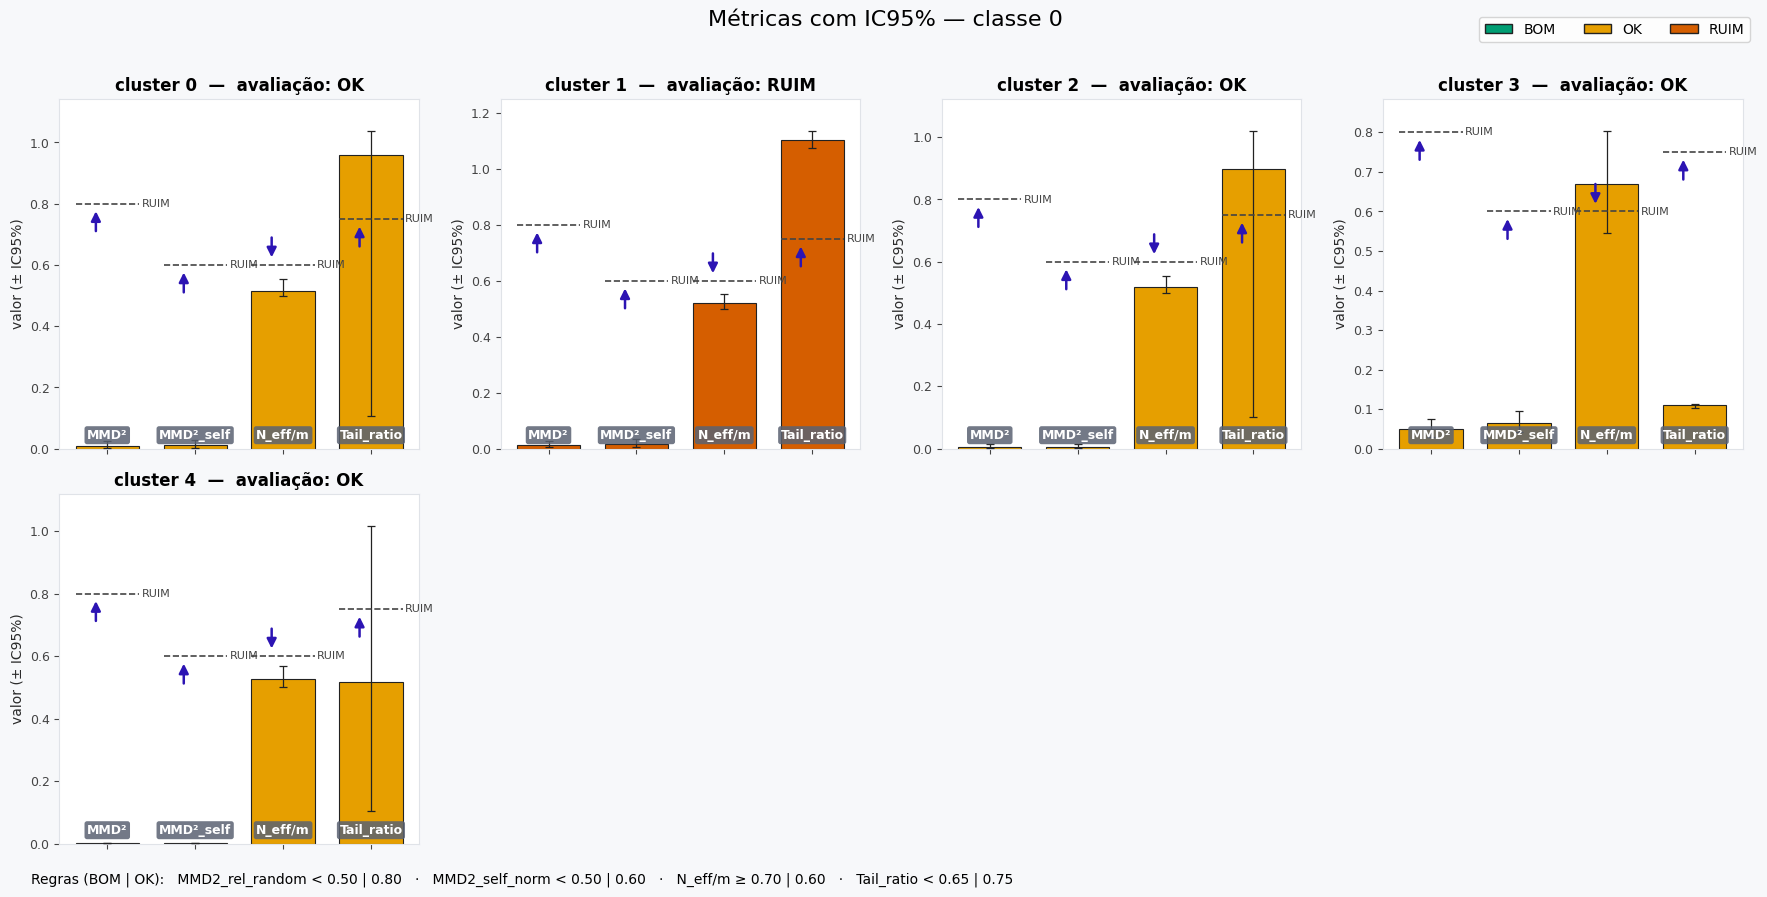

[Salvo] ../clusters_reports/xgboost/images/barras_ic95_classe_1.png


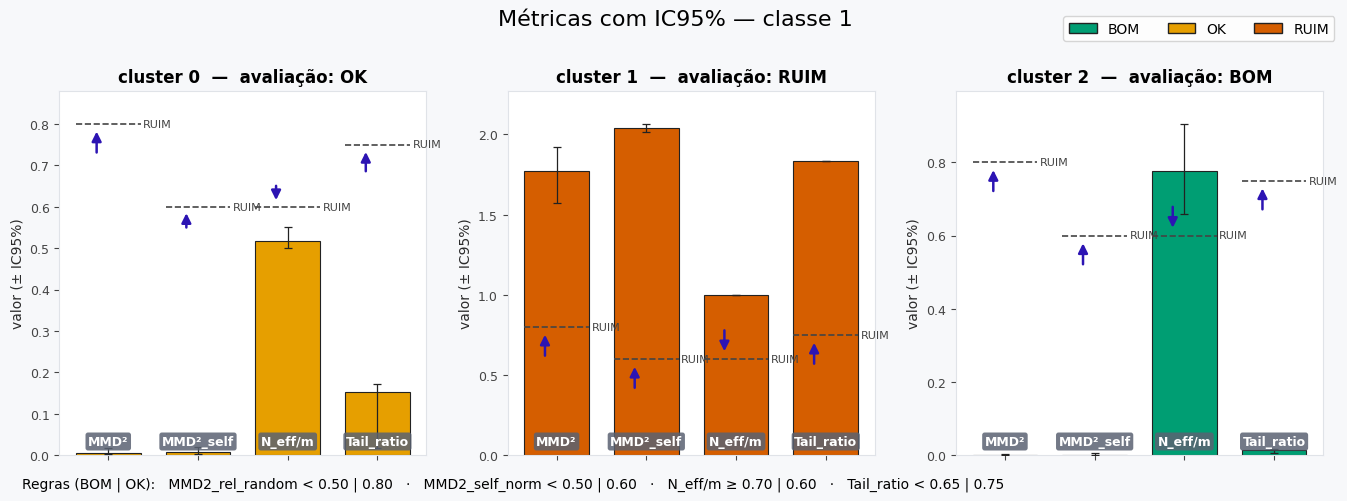

[Aviso] Não foi possível salvar arquivos ENTRADAS_SELECIONADAS_PROTODASH_IDDF/ILOC (variáveis não encontradas)


In [18]:
# Gráfico estilizado: barras com IC95% por (classe, cluster) 
# ============================================================
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.metrics import pairwise_distances
import os

# ---------------------- Aparência global (sem seaborn) ----------------------
plt.rcParams.update({
    "figure.facecolor": "#f7f8fa",
    "axes.facecolor":   "#ffffff",
    "axes.edgecolor":   "#e0e3e8",
    "axes.labelcolor":  "#2a2a2a",
    "axes.grid": True,
    "grid.color": "#e9ecf2",
    "grid.linestyle": "-",
    "grid.linewidth": 0.7,
    "axes.titleweight": "bold",
    "xtick.color": "#444",
    "ytick.color": "#444",
})

# ---------------------- Paleta e regras ----------------------
COLOR_BY_LABEL = {
    "BOM" : "#009E73",
    "OK"  : "#E69F00",
    "RUIM": "#D55E00",
}
N_BOOT   = 300
SEED_BOOT = 123
rng_boot  = np.random.default_rng(SEED_BOOT)
MAX_COLS_PER_ROW = 4  # até 4 gráficos por linha

TH = {
    "mmd_rel":    (0.80, 0.50),   # MMD2_rel_random < 0.80 | 0.50
    "mmd_self":   (0.50, 0.60),   # MMD2_self_norm  < 0.50 | 0.60
    "neff_ratio": (0.60, 0.70),   # N_eff/m ≥ 0.60 | 0.70
    "tail_ratio": (0.75, 0.65),   # Tail_ratio < 0.75 | 0.65
}

# ---- threshold(OK) por rótulo de métrica (menor valor) ----
TH_OK_BY_LABEL = {
    "MMD²":       min(TH["mmd_rel"]),
    "MMD²_self":  min(TH["mmd_self"]),
    "N_eff/m":    min(TH["neff_ratio"]),
    "Tail_ratio": min(TH["tail_ratio"]),
}

# ---- threshold(RUIM) por rótulo de métrica (menor valor) ----
TH_RUIM_BY_LABEL = {
    "MMD²":       max(TH["mmd_rel"]),     # ↓ melhor → RUIM é o maior limiar
    "MMD²_self":  max(TH["mmd_self"]),    # ↓ melhor
    "N_eff/m":    min(TH["neff_ratio"]),  # ↑ melhor → RUIM é o menor limiar
    "Tail_ratio": min(TH["tail_ratio"]) if max(TH["tail_ratio"]) < min(TH["tail_ratio"]) else max(TH["tail_ratio"])
    # (equivalente a: max(TH["tail_ratio"])) para seu TH atual
}

# ---- direção “melhor é” por métrica (para a seta) ----
BEST_DIR_BY_LABEL = {
    "MMD²": "down",
    "MMD²_self": "down",
    "N_eff/m": "up",
    "Tail_ratio": "down",
}

# Ordem das métricas (coluna_media, col_lo, col_hi, rótulo curto)
metrics_order = [
    ("mmd2_mu",   "mmd2_lo",   "mmd2_hi",   "MMD²"),
    ("mmd2sn_mu", "mmd2sn_lo", "mmd2sn_hi", "MMD²_self"),
    ("neffr_mu",  "neffr_lo",  "neffr_hi",  "N_eff/m"),
    ("tail_mu",   "tail_lo",   "tail_hi",   "Tail_ratio"),
]

# ---------------------- helpers métricas (bootstrap) ----------------------
def _weights_nnls_from_boot(K_zz, mu_z):
    m = len(mu_z)
    if m == 0: return np.array([])
    w = _nnls_weights_for_selected(K_zz, mu_z, np.arange(m))
    s = w.sum()
    return (w/s) if s > 0 else np.full_like(w, 1.0/m)

def _metrics_from_sample(X_s, Z, gamma):
    K_xx = _compute_kernel_fixed(X_s, X_s, gamma)
    Kxx_mean = float(K_xx.mean()) if K_xx.size else np.nan

    if len(Z):
        K_xz = _compute_kernel_fixed(X_s, Z, gamma)
        K_zz = _compute_kernel_fixed(Z, Z, gamma)
        mu_z = K_xz.mean(axis=0)
        w    = _weights_nnls_from_boot(K_zz, mu_z)
        cross = float(np.dot(w, mu_z))
        selfQ = float(w @ K_zz @ w)
        mmd2  = float(Kxx_mean - 2*cross + selfQ)
        mmd2_self = float(mmd2 / max(Kxx_mean, 1e-12))
        D = pairwise_distances(X_s, Z, metric="euclidean")
        p95 = float(np.quantile(D.min(axis=1), 0.95))
        neff_ratio = float(1.0 / np.sum((w / max(w.sum(),1e-12))**2)) / max(len(Z),1)
    else:
        mmd2 = mmd2_self = p95 = neff_ratio = np.nan

    return dict(mmd2=mmd2, mmd2_self=mmd2_self, p95=p95, neff_ratio=neff_ratio)

def _bootstrap_cluster(X_c, Z, gamma, n_boot=N_BOOT, rng=rng_boot):
    if len(X_c)==0 or len(Z)==0:
        return {k:(np.nan,np.nan,np.nan) for k in ["mmd2","mmd2_self","p95","neff_ratio"]}
    vals = {"mmd2":[], "mmd2_self":[], "p95":[], "neff_ratio":[]}
    n = len(X_c)
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        out = _metrics_from_sample(X_c[idx], Z, gamma)
        for k in vals: vals[k].append(out[k])
    out = {}
    for k, v in vals.items():
        a  = np.asarray(v, float)
        mu = float(np.nanmean(a))
        lo, hi = np.quantile(a, [0.025, 0.975])
        out[k] = (mu, float(lo), float(hi))
    return out

# ---------------------- Tail baseline p/ classe (p75 dos p95) ----------------------
p75_p95_by_cls = {}
for cls, res in results_by_class.items():
    idx_global_cls = np.asarray(res["idx_global"], int)
    labels_loc     = np.asarray(res["labels"], int)
    X_cls = X_test.iloc[idx_global_cls].values
    p95s = []
    for c in np.sort(np.unique(labels_loc)):
        idxs = np.where(labels_loc == c)[0]
        X_c  = X_cls[idxs]
        df_g = df_protos[(df_protos["classe"]==int(cls)) & (df_protos["cluster"]==int(c))]
        if df_g.empty: continue
        sel_g = df_g["idx_global_no_X_test"].astype(int).values
        gids  = idx_global_cls[idxs]
        loc   = [int(np.where(gids==g)[0][0]) for g in sel_g if g in gids]
        if not loc: continue
        Z = X_c[loc]
        D = pairwise_distances(X_c, Z, metric="euclidean")
        p95s.append(float(np.quantile(D.min(axis=1), 0.95)))
    p75_p95_by_cls[int(cls)] = (np.quantile(p95s, 0.75) if p95s else np.nan)

# ---------------------- Computa médias/IC por cluster ----------------------
rows = []
for cls, res in results_by_class.items():
    idx_global_cls = np.asarray(res["idx_global"], int)
    labels_loc     = np.asarray(res["labels"], int)
    X_cls = X_test.iloc[idx_global_cls].values
    for c in np.sort(np.unique(labels_loc)):
        idxs = np.where(labels_loc == c)[0]
        X_c  = X_cls[idxs]
        df_g = df_protos[(df_protos["classe"]==int(cls)) & (df_protos["cluster"]==int(c))]
        if df_g.empty: continue
        sel_g = df_g["idx_global_no_X_test"].astype(int).values
        gids  = idx_global_cls[idxs]
        loc   = [int(np.where(gids==g)[0][0]) for g in sel_g if g in gids]
        if not loc: continue
        Z = X_c[loc]
        gamma = _resolve_gamma_value(X_c)

        boot = _bootstrap_cluster(X_c, Z, gamma)
        base = p75_p95_by_cls.get(int(cls), np.nan)

        def _ratio(ci):
            mu, lo, hi = ci
            if not np.isfinite(base) or base<=0: return (np.nan,np.nan,np.nan)
            return (mu/base, lo/base, hi/base)

        tail_mu, tail_lo, tail_hi = _ratio(boot["p95"])
        rows.append({
            "classe": int(cls), "cluster": int(c),
            "mmd2_mu": boot["mmd2"][0],    "mmd2_lo": boot["mmd2"][1],    "mmd2_hi": boot["mmd2"][2],
            "mmd2sn_mu": boot["mmd2_self"][0],"mmd2sn_lo": boot["mmd2_self"][1],"mmd2sn_hi": boot["mmd2_self"][2],
            "neffr_mu": boot["neff_ratio"][0],"neffr_lo": boot["neff_ratio"][1],"neffr_hi": boot["neff_ratio"][2],
            "tail_mu": tail_mu, "tail_lo": tail_lo, "tail_hi": tail_hi,
        })
df_boot = pd.DataFrame(rows).sort_values(["classe","cluster"]).reset_index(drop=True)

# Salva CSV com as métricas bootstrap
IMG_DIR = str(globals().get('OUT_IMG', globals().get('IMG_DIR', 'images')))
os.makedirs(IMG_DIR, exist_ok=True)
CSV_DIR = str(globals().get('OUT_CSV', globals().get('CSV_DIR', 'csv')))
os.makedirs(CSV_DIR, exist_ok=True)
CSV_BOOT = os.path.join(CSV_DIR, "bootstrap_metrics_por_cluster.csv")
df_boot.to_csv(CSV_BOOT, index=False, float_format="%.6f")

# ---------------------- Função de plot — 1 figura por classe (N subplots) ----------------------
def plot_class_panels_pretty(clsid: int, savefig=True):
    dfc = df_boot[df_boot["classe"] == clsid].copy()
    if dfc.empty:
        print(f"(classe {clsid}) — sem dados.")
        return

    clusts = sorted(dfc["cluster"].tolist())
    nC = len(clusts)

    ncols = min(MAX_COLS_PER_ROW, nC)
    nrows = int(math.ceil(nC / ncols))

    fig_w = 4.2 * ncols + 1.0
    fig_h = 3.8 * nrows + 0.8
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), squeeze=False)
    fig.suptitle(f"Métricas com IC95% — classe {clsid}", fontsize=16, y=1.02)

    patches = [Patch(facecolor=COLOR_BY_LABEL[k], edgecolor="#222", label=k)
               for k in ["BOM", "OK", "RUIM"]]
    fig.legend(handles=patches,
               labels=[p.get_label() for p in patches],
               loc="upper right", bbox_to_anchor=(0.99, 1.02),
               ncol=3, frameon=True)

    eval_map = {(int(r.classe), int(r.cluster)): r.avaliacao
                for r in df_cluster_metrics.itertuples(index=False)}

    for ax, c in zip(axes.ravel(), clusts):
        row = dfc[dfc["cluster"] == c].iloc[0]
        cat = eval_map.get((int(clsid), int(c)), "OK")
        col = COLOR_BY_LABEL.get(cat, "#999999")

        xs   = np.arange(len(metrics_order))
        barw = 0.72

        mu = [row[m[0]] for m in metrics_order]
        lo = [row[m[1]] for m in metrics_order]
        hi = [row[m[2]] for m in metrics_order]
        err = np.vstack([np.array(mu) - np.array(lo), np.array(hi) - np.array(mu)])

        # desenha barras + IC
        ax.bar(xs, mu, width=barw, color=col, edgecolor="#222", linewidth=0.8, zorder=2)
        ax.errorbar(xs, mu, yerr=err, fmt="none", ecolor="#222",
                    elinewidth=0.9, capsize=3, capthick=0.9, zorder=3)

        # ---- linhas pontilhadas + SETA laranja indicando o melhor sentido ----
        thr_list = []
        arrow_tops = []
        for i, (_, _, _, lab) in enumerate(metrics_order):
            thr = TH_RUIM_BY_LABEL.get(lab, None)
            thr_list.append(thr)
            if thr is None or not np.isfinite(thr):
                continue

            # linha pontilhada sobre a largura da barra
            x0 = xs[i] - barw/2.0
            x1 = xs[i] + barw/2.0
            ax.hlines(thr, x0, x1, linestyles="dashed", linewidth=1.2,
                      colors="#444", zorder=4)
            ax.text(x1 + 0.03, thr, "RUIM", va="center", ha="left",
                    fontsize=8, color="#444")

            # seta laranja
            y_ref = max([h for h in hi if np.isfinite(h)] + [thr, 1e-6])
            dy = 0.08 * y_ref   # comprimento da seta (~8% do topo atual)
            off = 0.015 * y_ref # folga em relação à linha

            if BEST_DIR_BY_LABEL.get(lab, "down") == "down":
                y_start = max(thr - (dy + off), 0.0)  # começa abaixo
                y_end   = max(thr - off, 0.0)         # aponta para cima
            else:  # "up" era o lado bom → RUIM = para baixo
                y_start = thr + (dy + off)            # começa acima
                y_end   = thr + off                   # aponta para baixo

            x_arrow = xs[i] - barw * 0.18  # desloca a seta um pouco para a esquerda
            ax.annotate(
                "", xy=(x_arrow, y_end), xytext=(x_arrow, y_start),
                arrowprops=dict(arrowstyle="-|>", lw=1.8, color="#2C14B3", mutation_scale=14),
                zorder=5
            )
            arrow_tops.append(max(y_start, y_end))

        # garante que o y-lim inclua thresholds e setas
        y_top = max([h for h in hi if np.isfinite(h)] +
                    [t for t in thr_list if t is not None and np.isfinite(t)] +
                    arrow_tops + [0])
        ax.set_ylim(0, y_top * 1.10)

        # nomes das métricas na base
        for i, (_, _, _, lab) in enumerate(metrics_order):
            ax.text(i, 0.02, lab, ha="center", va="bottom",
                    fontsize=9, fontweight="bold", color="white",
                    bbox=dict(boxstyle="round,pad=0.2", fc="#5a6272", ec="none", alpha=0.85),
                    transform=ax.get_xaxis_transform())

        ax.set_xticks(xs)
        ax.set_xticklabels([""] * len(xs))
        ax.set_ylabel("valor (± IC95%)", fontsize=10)
        ax.set_title(f"cluster {c}  —  avaliação: {cat}", fontsize=12, pad=6)
        ax.grid(False)

    total_axes = nrows * ncols
    for ax in axes.ravel()[nC:total_axes]:
        ax.axis("off")

    fig.text(0.02, -0.02,
             ("Regras (BOM | OK):   "
              f"MMD2_rel_random < {TH['mmd_rel'][1]:.2f} | {TH['mmd_rel'][0]:.2f}   ·   "
              f"MMD2_self_norm < {TH['mmd_self'][0]:.2f} | {TH['mmd_self'][1]:.2f}   ·   "
              f"N_eff/m ≥ {TH['neff_ratio'][1]:.2f} | {TH['neff_ratio'][0]:.2f}   ·   "
              f"Tail_ratio < {TH['tail_ratio'][1]:.2f} | {TH['tail_ratio'][0]:.2f}"),
             fontsize=10)

    fig.tight_layout()
    if savefig:
        fname = os.path.join(IMG_DIR, f"barras_ic95_classe_{clsid}.png")
        fig.savefig(fname, dpi=180, bbox_inches="tight")
        print(f"[Salvo] {fname}")
    plt.show()

# ---------------------- Executa para cada classe ----------------------
for clsid in sorted(df_boot["classe"].unique()):
    plot_class_panels_pretty(clsid, savefig=True)
    
if 'ENTRADAS_SELECIONADAS_PROTODASH' in globals() and 'DF_GLOBAL' in globals() and 'ID_COL' in globals():
    ilocs = []
    for v in ENTRADAS_SELECIONADAS_PROTODASH.values():
        ilocs.extend(v)
    ilocs = sorted(set(ilocs))
    ids = DF_GLOBAL.iloc[ilocs][ID_COL].tolist() if len(ilocs) > 0 else []
    pd.DataFrame({'id': ids}).to_csv(os.path.join(CSV_DIR, 'ENTRADAS_SELECIONADAS_PROTODASH_IDDF.csv'), index=False)
    pd.DataFrame({'iloc': ilocs}).to_csv(os.path.join(CSV_DIR, 'ENTRADAS_SELECIONADAS_PROTODASH_ILOC.csv'), index=False)
    print('[Salvo] ENTRADAS_SELECIONADAS_PROTODASH_IDDF.csv e ENTRADAS_SELECIONADAS_PROTODASH_ILOC.csv')
else:
    print('[Aviso] Não foi possível salvar arquivos ENTRADAS_SELECIONADAS_PROTODASH_IDDF/ILOC (variáveis não encontradas)')
 


In [19]:
# Seleção Aleatória por (classe, cluster), sem sobrepor KCenter/ProtoDash
# Cria ENTRADAS_SELECIONADAS_ALEATORIO + df_selecao_aleatorio (DataFrame)
# Também exporta ENTRADAS_SELECIONADAS_PROTODASH_ID e ENTRADAS_SELECIONADAS_ALEATORIAS_ID
# ============================================================
import math
import numpy as np
import pandas as pd
import os

# ---------- PARÂMETROS ----------
SEED_RANDOM = 123
rng = np.random.default_rng(SEED_RANDOM)

# Quantidade alvo de aleatórios por cluster (escolha UM modo):
RANDOM_PER_CLUSTER = 2       # inteiro fixo (mínimo desejado por cluster)
RANDOM_FRAC_PER_CLUSTER = None  # fração do tamanho do cluster (ex.: 0.10 = 10%)
MIN_RANDOM_PER_CLUSTER = 2   # nunca escolher menos que isso (se houver candidatos)
MAX_RANDOM_PER_CLUSTER = None  # opcional: teto por cluster (None = sem teto)

# Diretórios de saída
RESULTS_DIR = str(globals().get('RESULTS_DIR', '.'))
CSV_DIR = str(globals().get('OUT_CSV', globals().get('CSV_DIR', RESULTS_DIR)))
os.makedirs(CSV_DIR, exist_ok=True)

# (opcional) salvar CSV com a seleção aleatória
CSV_RANDOM_OUT = os.path.join(CSV_DIR, "selecionados_aleatorio_por_classe_cluster.csv")
CSV_PROTODASH_ID = os.path.join(CSV_DIR, "selecionados_protodash_id_por_classe_cluster.csv")
CSV_ALEATORIAS_ID = os.path.join(CSV_DIR, "selecionados_aleatorios_id_por_classe_cluster.csv")

# ---------- HELPERS ----------
def _normalize_selection_to_map(selection):
    """
    Converte uma seleção em dict { (classe, cluster) : set(indices_globais) }.
    Aceita:
      - dict com chaves (classe, cluster) -> iterável de ids
      - DataFrame com colunas ['classe','cluster', id_col], onde id_col pode ser:
           'idx_global', 'idx_global_no_X_test', 'index_global', 'id_global'
    Se 'selection' for None/desconhecido, retorna dict vazio.
    """
    m = {}
    if selection is None:
        return m

    if isinstance(selection, dict):
        for k, v in selection.items():
            if isinstance(k, tuple) and len(k) == 2:
                cls, c = int(k[0]), int(k[1])
                m[(cls, c)] = set(int(x) for x in v)
        return m

    if isinstance(selection, pd.DataFrame):
        id_cols_try = ["idx_global", "idx_global_no_X_test", "index_global", "id_global"]
        id_col = next((col for col in id_cols_try if col in selection.columns), None)
        if id_col is None:
            return m
        for (cls, c), grp in selection.groupby(["classe", "cluster"]):
            m[(int(cls), int(c))] = set(int(x) for x in grp[id_col].tolist())
        return m

    # outro tipo: ignora
    return m

def _target_random_count(n_c):
    """Decide k alvo por cluster, combinando inteiro fixo / fração / mínimos / máximos."""
    if RANDOM_FRAC_PER_CLUSTER is not None:
        base = math.ceil(float(RANDOM_FRAC_PER_CLUSTER) * n_c)
    else:
        base = int(RANDOM_PER_CLUSTER)

    base = max(base, int(MIN_RANDOM_PER_CLUSTER))
    if MAX_RANDOM_PER_CLUSTER is not None:
        base = min(base, int(MAX_RANDOM_PER_CLUSTER))
    return max(base, 0)

# ---------- ENTRADAS de referência ----------
KSEL = _normalize_selection_to_map(globals().get("ENTRADAS_SELECIONADAS_KCENTER", None))
PSEL = _normalize_selection_to_map(globals().get("ENTRADAS_SELECIONADAS_PROTODASH", None))

# Fallback: se não vieram, tenta montar PROTODASH a partir de df_protos (se existir)
if not PSEL and "df_protos" in globals():
    try:
        PSEL = _normalize_selection_to_map(
            df_protos.rename(columns={"idx_global_no_X_test":"idx_global"})[["classe","cluster","idx_global"]]
        )
    except Exception:
        pass

# ---------- LOOP por (classe, cluster) ----------
ENTRADAS_SELECIONADAS_ALEATORIO = {}  # dict {(classe, cluster): [idx_global, ...]}
# Também expor alias ENTRADAS_SELECIONADAS_ALEATORIAS (mesmo formato solicitado)
ENTRADAS_SELECIONADAS_ALEATORIAS = ENTRADAS_SELECIONADAS_ALEATORIO
rows_random = []

for cls in sorted(results_by_class.keys()):
    res = results_by_class[cls]
    idx_global_cls = np.asarray(res["idx_global"], dtype=int)
    labels_loc     = np.asarray(res["labels"], dtype=int)
    clusters = np.sort(np.unique(labels_loc))

    for c in clusters:
        idxs_loc_c = np.where(labels_loc == c)[0]
        if idxs_loc_c.size == 0:
            continue

        # universo de candidatos desse cluster (em índices globais no X_test)
        global_ids_c = idx_global_cls[idxs_loc_c]
        cand_set = set(int(g) for g in global_ids_c.tolist())

        # excluir já selecionados por KCenter e ProtoDash
        already = set()
        already |= KSEL.get((int(cls), int(c)), set())
        already |= PSEL.get((int(cls), int(c)), set())

        candidates = list(cand_set - already)
        n_c = len(global_ids_c)
        k_target = _target_random_count(n_c)

        if len(candidates) == 0:
            picked = []
        else:
            k = min(k_target, len(candidates))
            picked = rng.choice(candidates, size=k, replace=False).tolist()

        ENTRADAS_SELECIONADAS_ALEATORIO[(int(cls), int(c))] = picked
        for gid in picked:
            rows_random.append({"classe": int(cls), "cluster": int(c), "idx_global": int(gid)})

# salva alias atualizado
ENTRADAS_SELECIONADAS_ALEATORIAS = ENTRADAS_SELECIONADAS_ALEATORIO

# ---------- DataFrame e CSV ----------
df_selecao_aleatorio = pd.DataFrame(rows_random).sort_values(["classe","cluster","idx_global"]).reset_index(drop=True)
df_selecao_aleatorio.to_csv(CSV_RANDOM_OUT, index=False)

# ---------- Exporta IDs por cluster para ProtoDash e Aleatório ----------
def _export_ids_map_to_csv(sel_map, fname):
    rows = []
    for (cls, c), ids in sel_map.items():
        for gid in ids:
            rows.append({"classe": int(cls), "cluster": int(c), "idx_global": int(gid)})
    df = pd.DataFrame(rows).sort_values(["classe","cluster","idx_global"]).reset_index(drop=True)
    df.to_csv(fname, index=False)

_export_ids_map_to_csv(PSEL, CSV_PROTODASH_ID)
_export_ids_map_to_csv(ENTRADAS_SELECIONADAS_ALEATORIO, CSV_ALEATORIAS_ID)

# ---------- Variáveis globais ----------
globals()["ENTRADAS_SELECIONADAS_PROTODASH_ID"] = PSEL
globals()["ENTRADAS_SELECIONADAS_ALEATORIAS_ID"] = ENTRADAS_SELECIONADAS_ALEATORIO
globals()["ENTRADAS_SELECIONADAS_ALEATORIAS"] = ENTRADAS_SELECIONADAS_ALEATORIO

print(f"✅ Seleção aleatória criada em ENTRADAS_SELECIONADAS_ALEATORIO.")
print(f"📄 CSV salvo em: {CSV_RANDOM_OUT}")
print(f"📄 CSV IDs ProtoDash: {CSV_PROTODASH_ID}")
print(f"📄 CSV IDs Aleatórias: {CSV_ALEATORIAS_ID}")
print(f"Resumo: clusters com seleção aleatória > 0 = {sum(len(v)>0 for v in ENTRADAS_SELECIONADAS_ALEATORIO.values())}")

# --- CSV completo com entradas ProtoDash (classe, cluster) ---
CSV_PROTODASH_COMPLETO = os.path.join(CSV_DIR, "entradas_selecionadas_protodash_completo.csv")
protodash_full_rows = []
csv_path_value = globals().get("CSV_TEST_PATH", "N/A")

medoid_lookup = {}
if 'results_by_class' in globals():
    for cls_key, res in results_by_class.items():
        idx_global_cls = np.asarray(res.get("idx_global", []), dtype=int)
        for clus_key, centers_loc in res.get("centers_by_cluster", {}).items():
            if not centers_loc:
                continue
            loc0 = int(centers_loc[0])
            if 0 <= loc0 < len(idx_global_cls):
                medoid_lookup[(int(cls_key), int(clus_key))] = int(idx_global_cls[loc0])

if PSEL:
    for (cls_key, clus_key), ids in PSEL.items():
        ids_sorted = sorted(int(gid) for gid in ids)
        medoid_global = medoid_lookup.get((int(cls_key), int(clus_key)))
        for iloc_val in ids_sorted:
            # if 0 <= iloc_val < len(X_test):
            #     id_real = X_test['id'].values
            # else:
            #     id_real = iloc_val
            is_medoid = int(medoid_global is not None and iloc_val == medoid_global)
            protodash_full_rows.append({
                'ID':  int(X_test.iloc[iloc_val]['id']),
                'ILOC': iloc_val,
                'CLASSE': int(cls_key),
                'CLUSTER': int(clus_key),
                'CSV_PATH': csv_path_value,
                'IS_MEDOID': is_medoid
            })

if protodash_full_rows:
    df_protodash_full = (
        pd.DataFrame(protodash_full_rows)
        .sort_values(["CLASSE", "CLUSTER", "ILOC"])
        .reset_index(drop=True)
    )
    df_protodash_full['IS_MEDOID'] = df_protodash_full['IS_MEDOID'].astype(int)
    df_protodash_full.to_csv(CSV_PROTODASH_COMPLETO, index=False)
    print(f"📄 CSV ProtoDash completo salvo em: {CSV_PROTODASH_COMPLETO}")
else:
    print("[Aviso] Não há entradas ProtoDash para salvar em entradas_selecionadas_protodash_completo.csv")

# --- CSV completo com entradas aleatórias (classe, cluster) ---
CSV_ALEATORIAS_COMPLETO = os.path.join(CSV_DIR, "entradas_aleatorias_completo.csv")
aleatorias_full_rows = []

for (cls_key, clus_key), ids in ENTRADAS_SELECIONADAS_ALEATORIO.items():
    ids_sorted = sorted(int(gid) for gid in ids)
    medoid_global = medoid_lookup.get((int(cls_key), int(clus_key)))
    for iloc_val in ids_sorted:
        if not 0 <= iloc_val < len(X_test):
            continue
        aleatorias_full_rows.append({
            'ID': int(X_test.iloc[iloc_val]['id']),
            'ILOC': iloc_val,
            'CLASSE': int(cls_key),
            'CLUSTER': int(clus_key),
            'CSV_PATH': csv_path_value,
            'IS_MEDOID': int(medoid_global is not None and iloc_val == medoid_global)
        })

if aleatorias_full_rows:
    df_aleatorias_full = (
        pd.DataFrame(aleatorias_full_rows)
        .sort_values(["CLASSE", "CLUSTER", "ILOC"])
        .reset_index(drop=True)
    )
    df_aleatorias_full['IS_MEDOID'] = df_aleatorias_full['IS_MEDOID'].astype(int)
    df_aleatorias_full.to_csv(CSV_ALEATORIAS_COMPLETO, index=False)
    print(f"📄 CSV Aleatório completo salvo em: {CSV_ALEATORIAS_COMPLETO}")
else:
    print("[Aviso] Não há entradas aleatórias para salvar em entradas_aleatorias_completo.csv")

# Visualização rápida
display(df_selecao_aleatorio)
ENTRADAS_SELECIONADAS_PROTODASH = []
for k, v in PSEL.items():
    print(v)
    for x in v:
        ENTRADAS_SELECIONADAS_PROTODASH.append(x)

ENTRADAS_SELECIONADAS_ALEATORIAS_tmp = []
for k, v in ENTRADAS_SELECIONADAS_ALEATORIAS.items():
    print(v)
    for x in v:
        ENTRADAS_SELECIONADAS_ALEATORIAS_tmp.append(x)
# contnuar aqui da valiavel aleatoria que esta dando problema 

ENTRADAS_SELECIONADAS_ALEATORIAS = ENTRADAS_SELECIONADAS_ALEATORIAS_tmp

✅ Seleção aleatória criada em ENTRADAS_SELECIONADAS_ALEATORIO.
📄 CSV salvo em: ../clusters_reports/xgboost/csv/selecionados_aleatorio_por_classe_cluster.csv
📄 CSV IDs ProtoDash: ../clusters_reports/xgboost/csv/selecionados_protodash_id_por_classe_cluster.csv
📄 CSV IDs Aleatórias: ../clusters_reports/xgboost/csv/selecionados_aleatorios_id_por_classe_cluster.csv
Resumo: clusters com seleção aleatória > 0 = 8
📄 CSV ProtoDash completo salvo em: ../clusters_reports/xgboost/csv/entradas_selecionadas_protodash_completo.csv
📄 CSV Aleatório completo salvo em: ../clusters_reports/xgboost/csv/entradas_aleatorias_completo.csv


,classe,cluster,idx_global
0,0,0,445
1,0,0,515
2,0,1,499
3,0,1,521
4,0,2,410
5,0,2,542
6,0,3,402
7,0,3,551
8,0,4,337
9,0,4,492


{345, 429}
{237, 398}
{275, 399}
{224, 219}
{232, 227}
{193, 111}
{2}
{177, 194}
[515, 445]
[499, 521]
[410, 542]
[402, 551]
[492, 337]
[48, 157]
[182, 174]
[30, 187]


In [20]:
# Array de repetidos entre KCENTER e PROTODASH (índices globais)
# + Unificação em estrutura única de IDs consolidados
# Cria:
#   ENTRADAS_SELECIONADAS_REPETIDAS  -> np.array([...], int)
#   ENTRADAS_SELECIONADAS            -> np.array([...], int) (KCenter ∪ ProtoDash ∪ Aleatório)
#   ENTRADAS_SELECIONADAS_ID         -> dict {(classe, cluster): sorted[list de ids únicos]}
# Também salva CSVs auxiliares para auditoria.
# ============================================================
import numpy as np
import pandas as pd
import os

RESULTS_DIR = str(globals().get('RESULTS_DIR', '.'))
CSV_DIR = str(globals().get('OUT_CSV', globals().get('CSV_DIR', RESULTS_DIR)))
os.makedirs(CSV_DIR, exist_ok=True)
CSV_REPETIDOS = os.path.join(CSV_DIR, 'repetidos_kcenter_protodash.csv')
CSV_UNIFICADO = os.path.join(CSV_DIR, 'selecionados_unificados_ids.csv')
CSV_UNIFICADO_MAP = os.path.join(CSV_DIR, 'selecionados_unificados_por_classe_cluster.csv')

def _to_id_set(selection):
    """Converte diferentes formatos de 'selection' em um set de ids (int)."""
    if selection is None:
        return set()
    if isinstance(selection, dict):
        out = set()
        for v in selection.values():
            try:
                out |= set(int(x) for x in v)
            except Exception:
                pass
        return out
    if isinstance(selection, pd.DataFrame):
        for col in ["idx_global", "idx_global_no_X_test", "index_global", "id_global"]:
            if col in selection.columns:
                return set(int(x) for x in selection[col].tolist())
        return set()
    try:
        return set(int(x) for x in list(selection))
    except Exception:
        return set()

def _to_map(selection):
    """Normaliza em dict {(classe, cluster): sorted list(ids)} para reconstruir granularidade."""
    m = {}
    if selection is None:
        return m
    if isinstance(selection, dict):
        for k, v in selection.items():
            if isinstance(k, tuple) and len(k) == 2:
                cls, c = int(k[0]), int(k[1])
                try:
                    ids = sorted({int(x) for x in v})
                    if ids:
                        m[(cls, c)] = ids
                except Exception:
                    pass
        return m
    if isinstance(selection, pd.DataFrame):
        id_col = None
        for col in ["idx_global", "idx_global_no_X_test", "index_global", "id_global"]:
            if col in selection.columns:
                id_col = col
                break
        if id_col is None or not {'classe','cluster'} <= set(selection.columns):
            return m
        for (cls, c), grp in selection.groupby(['classe','cluster']):
            ids = sorted({int(x) for x in grp[id_col].tolist()})
            if ids:
                m[(int(cls), int(c))] = ids
        return m
    # lista / array não guarda classe/cluster → retorna vazio
    return m

# ---- Conjuntos de cada seleção ----
k_ids = _to_id_set(globals().get('ENTRADAS_SELECIONADAS_KCENTER', None))
p_ids = _to_id_set(globals().get('ENTRADAS_SELECIONADAS_PROTODASH', None))
# fallback ProtoDash via df_protos
if not p_ids and 'df_protos' in globals():
    try:
        p_ids = _to_id_set(df_protos.rename(columns={'idx_global_no_X_test': 'idx_global'}))
    except Exception:
        pass

# Aleatórios (nomes possíveis)
a_random_obj = (globals().get('ENTRADAS_SELECIONADAS_ALEATORIO', None) or
                globals().get('ENTRADAS_SELECIONADAS_ALEATORIAS', None))
a_ids = _to_id_set(a_random_obj)

# ---- Repetidos ----
ENTRADAS_SELECIONADAS_REPETIDAS = np.array(sorted(k_ids & p_ids), dtype=int)

# ---- União total ----
ENTRADAS_SELECIONADAS = np.array(sorted(k_ids | p_ids | a_ids), dtype=int)

# ---- Construção do mapa unificado (classe, cluster) -> ids únicos ----
# Preferimos reconstruir a granularidade usando as estruturas mais detalhadas disponíveis:
map_k  = _to_map(globals().get('ENTRADAS_SELECIONADAS_KCENTER', None))
map_p  = _to_map(globals().get('ENTRADAS_SELECIONADAS_PROTODASH', None))
# ProtoDash via df_protos se mapa vazio
if not map_p and 'df_protos' in globals():
    try:
        map_p = _to_map(df_protos.rename(columns={'idx_global_no_X_test': 'idx_global'})[[ 'classe','cluster','idx_global']])
    except Exception:
        pass
map_a  = _to_map(a_random_obj)

# chaves combinadas
all_keys = set(map_k.keys()) | set(map_p.keys()) | set(map_a.keys())
ENTRADAS_SELECIONADAS_ID = {}
for key in sorted(all_keys):
    ids = set()
    ids |= set(map_k.get(key, []))
    ids |= set(map_p.get(key, []))
    ids |= set(map_a.get(key, []))
    if ids:
        ENTRADAS_SELECIONADAS_ID[key] = sorted(ids)

# ---- CSV repetidos ----
pd.DataFrame({'idx_global': ENTRADAS_SELECIONADAS_REPETIDAS}).to_csv(CSV_REPETIDOS, index=False)

# ---- CSV unificado (flat) ----
pd.DataFrame({'idx_global': ENTRADAS_SELECIONADAS}).to_csv(CSV_UNIFICADO, index=False)

# ---- CSV mapa por (classe, cluster) ----
rows_map = []
for (cls, c), ids in ENTRADAS_SELECIONADAS_ID.items():
    for gid in ids:
        rows_map.append({'classe': cls, 'cluster': c, 'idx_global': gid})
pd.DataFrame(rows_map).sort_values(['classe','cluster','idx_global']).to_csv(CSV_UNIFICADO_MAP, index=False)

# ---- Exposição em globals ----
globals()['ENTRADAS_SELECIONADAS_REPETIDAS'] = ENTRADAS_SELECIONADAS_REPETIDAS
globals()['ENTRADAS_SELECIONADAS'] = ENTRADAS_SELECIONADAS
globals()['ENTRADAS_SELECIONADAS_ID'] = ENTRADAS_SELECIONADAS_ID

print(f"✅ Repetidos (KCenter ∩ ProtoDash): {ENTRADAS_SELECIONADAS_REPETIDAS.size} itens → {CSV_REPETIDOS}")
print(f"✅ Unificado total: {ENTRADAS_SELECIONADAS.size} itens únicos → {CSV_UNIFICADO}")
print(f"✅ Mapa por (classe, cluster): {len(ENTRADAS_SELECIONADAS_ID)} chaves → {CSV_UNIFICADO_MAP}")
print('\nPreview repetidos:', ENTRADAS_SELECIONADAS_REPETIDAS[:20])
print('Preview unificado :', ENTRADAS_SELECIONADAS[:20])
print('Exemplo chave -> primeiros ids:')
for k,(cls,c) in zip(range(3), ENTRADAS_SELECIONADAS_ID.keys()):
    print((cls,c), ENTRADAS_SELECIONADAS_ID[(cls,c)][:10])

print('Salvando entradas_selecionadas_final.csv...')
pd.DataFrame({'idx_global': ENTRADAS_SELECIONADAS}).to_csv(os.path.join(CSV_DIR, 'entradas_selecionadas_final.csv'), index=False)


✅ Repetidos (KCenter ∩ ProtoDash): 1 itens → ../clusters_reports/xgboost/csv/repetidos_kcenter_protodash.csv
✅ Unificado total: 53 itens únicos → ../clusters_reports/xgboost/csv/selecionados_unificados_ids.csv
✅ Mapa por (classe, cluster): 8 chaves → ../clusters_reports/xgboost/csv/selecionados_unificados_por_classe_cluster.csv

Preview repetidos: [224]
Preview unificado : [  2  23  27  30  48  58  77 109 111 126 138 157 164 174 177 182 187 193
 194 202]
Exemplo chave -> primeiros ids:
(0, 0) [345, 429, 445, 515]
(0, 1) [237, 398, 499, 521]
(0, 2) [275, 399, 410, 542]
Salvando entradas_selecionadas_final.csv...


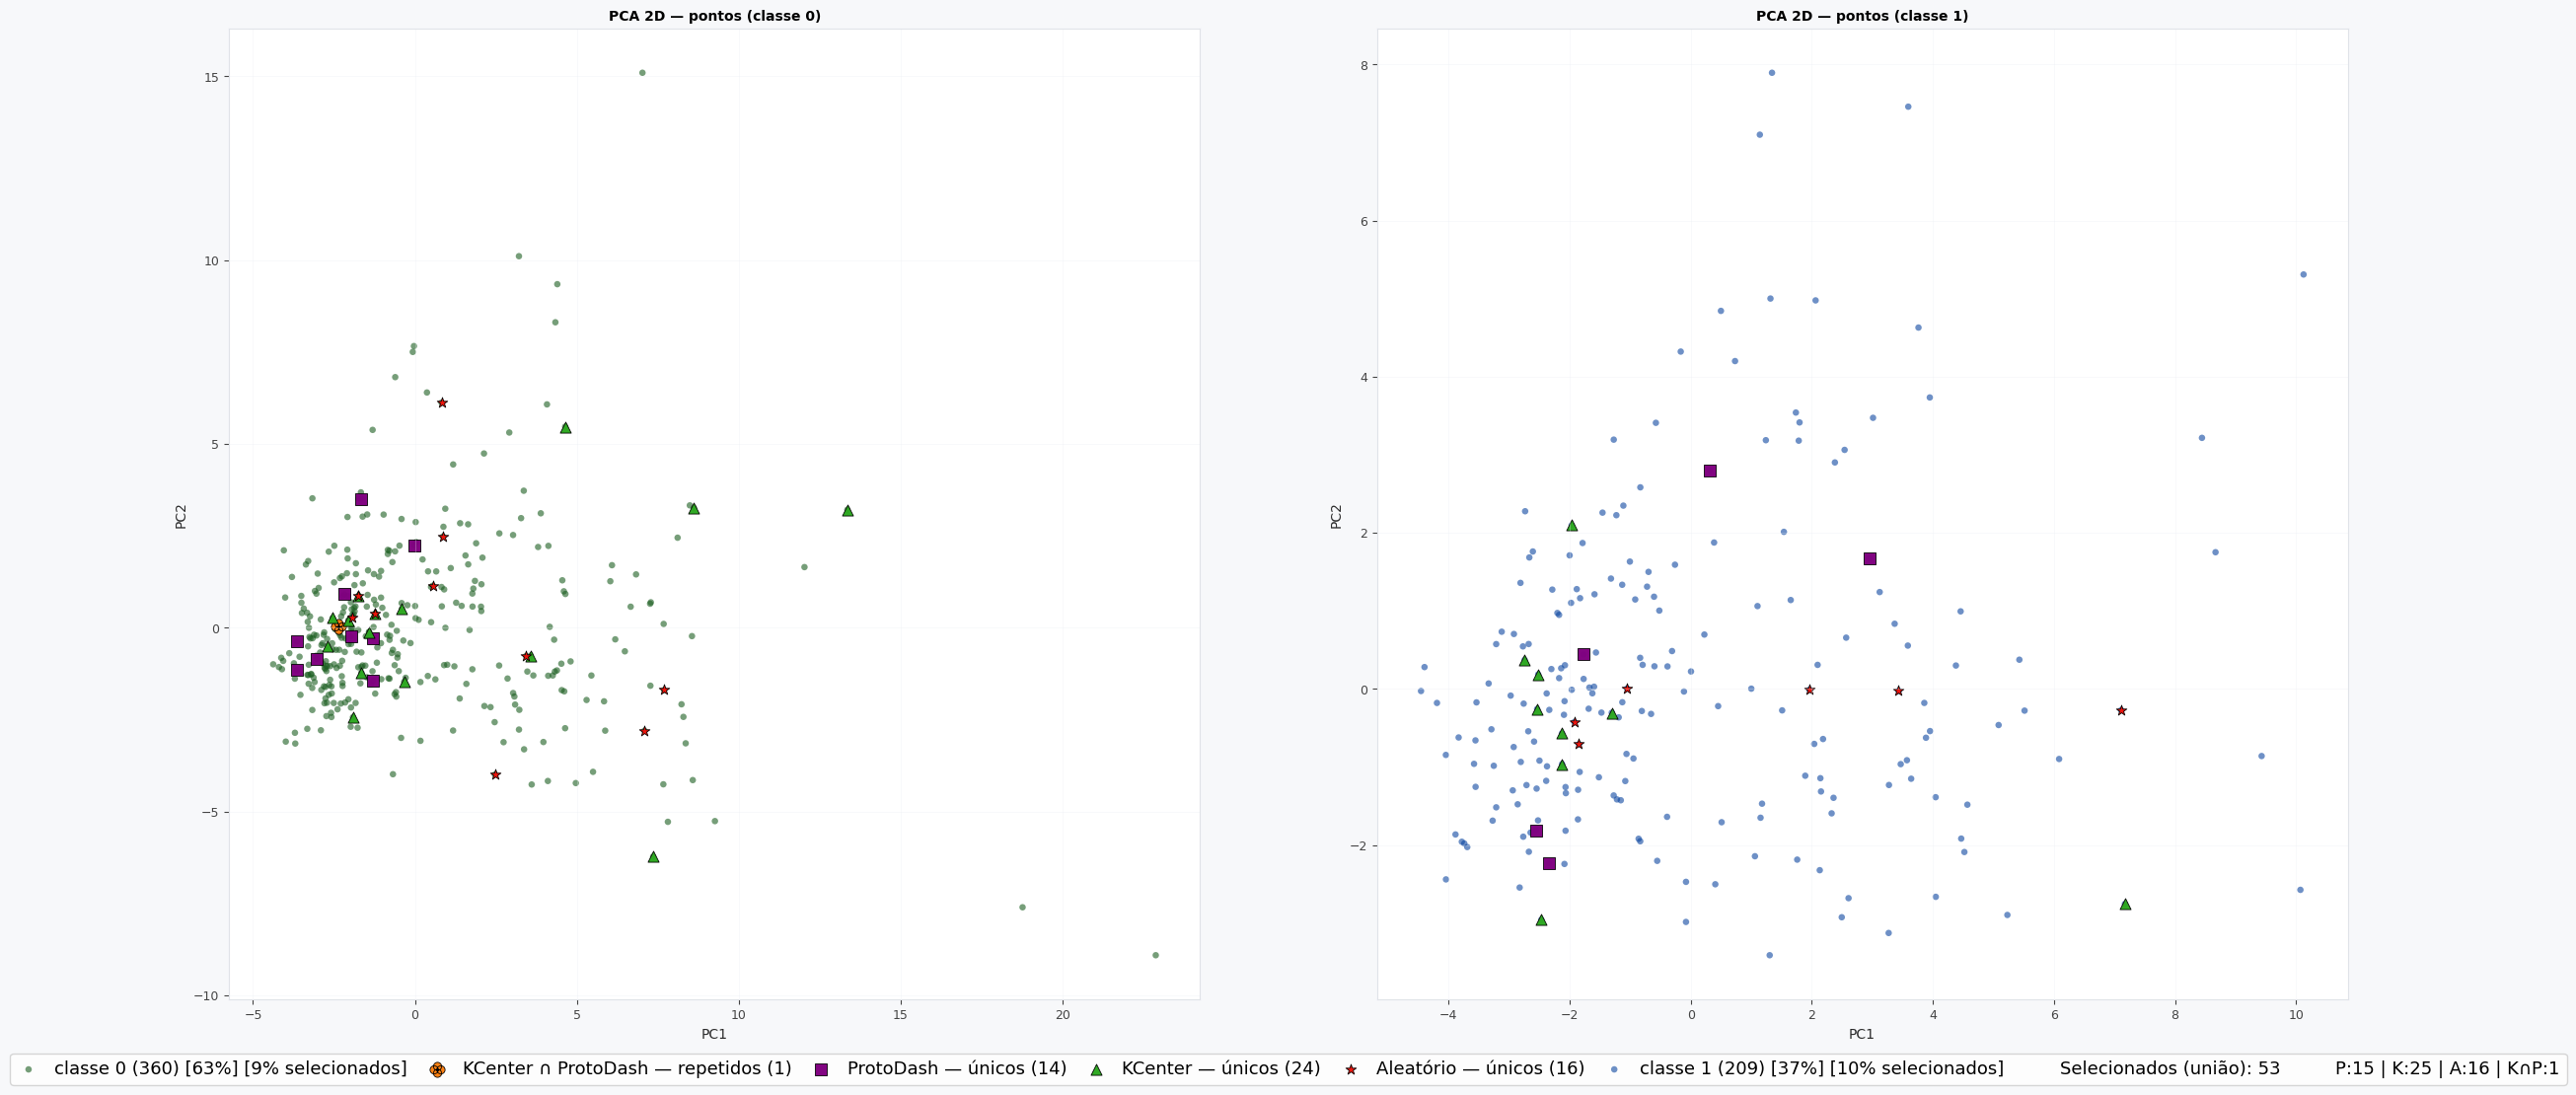

In [21]:
# PCA 2D global — classe 0 e classe 1
# Subplots QUADRADOS maiores (50%/50%) + legenda em uma única linha na base
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.path import Path as MplPath
from matplotlib.transforms import Affine2D
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D

# -------- helpers --------
def legend_totals_plugin(H, L, *, p_ids, k_ids, a_ids, repetidos_ids):
    sel_union = (set(p_ids) | set(k_ids) | set(a_ids))
    total_sel = len(sel_union)
    n_p, n_k, n_a, n_rep = len(p_ids), len(k_ids), len(a_ids), len(repetidos_ids)
    dummy1 = Line2D([], [], linestyle='none', marker=None, label="")
    dummy2 = Line2D([], [], linestyle='none', marker=None, label="")
    H = list(H) + [dummy1, dummy2]
    L = list(L) + [f"Selecionados (união): {total_sel}",
                   f"P:{n_p} | K:{n_k} | A:{n_a} | K∩P:{n_rep}"]
    return H, L

def _to_id_set(selection):
    if selection is None:
        return set()
    if isinstance(selection, dict):
        out = set()
        for v in selection.values():
            out |= set(int(x) for x in v)
        return out
    if isinstance(selection, pd.DataFrame):
        for col in ["idx_global", "idx_global_no_X_test", "index_global", "id_global"]:
            if col in selection.columns:
                return set(int(x) for x in selection[col].tolist())
        return set()
    try:
        return set(int(x) for x in list(selection))
    except Exception:
        return set()

def make_clover_marker(scale=0.65, offset=0.55):
    unit_circle = MplPath.unit_circle()
    tfs = [
        Affine2D().scale(scale).translate(0,  offset),
        Affine2D().scale(scale).translate(0, -offset),
        Affine2D().scale(scale).translate( offset, 0),
        Affine2D().scale(scale).translate(-offset, 0),
    ]
    paths = [tf.transform_path(unit_circle) for tf in tfs]
    return MplPath.make_compound_path(*paths)

# -------- coleta seleções --------
k_ids = _to_id_set(globals().get("ENTRADAS_SELECIONADAS_KCENTER", None))
p_ids = _to_id_set(globals().get("ENTRADAS_SELECIONADAS_PROTODASH", None))
a_obj = (globals().get("ENTRADAS_SELECIONADAS_ALEATORIAS", None))
a_ids = _to_id_set(a_obj)

# -------- conjuntos --------
repetidos_ids = k_ids & p_ids
k_unique = k_ids - repetidos_ids
p_unique = p_ids - repetidos_ids
a_plot = a_ids

# -------- rótulo de classe por índice global --------
# USANDO DF_GLOBAL_NORM COMO BASE E EXCLUINDO APENAS AS EXCLUDE_COLUMNS PARA O PCA
X_all_for_pca = DF_GLOBAL_NORM.drop(columns=EXCLUDE_COLUMNS, errors='ignore')
n = X_all_for_pca.shape[0]
y_cls = np.full(n, -1, dtype=int)
for cls, res in results_by_class.items():
    y_cls[np.asarray(res["idx_global"], dtype=int)] = int(cls)

# -------- PCA global --------
Z_all = PCA(n_components=2, random_state=42).fit_transform(X_all_for_pca.values)

# -------- estética --------
class_colors = {0: "#1b5e20", 1: "#0d47a1"}
alpha_bg = 0.60
color_protodash_unique = "#800080"
color_kcenter_unique   = "#2DA820"
color_random_unique    = "#EF120A"
color_repeat           = "#ff7f0e"
markers = {"protodash": "s", "kcenter": "^", "random": "*"}
clover_marker = make_clover_marker()

# -------- contagens para a legenda (globais) --------
n_p_unique   = len(p_unique)
n_k_unique   = len(k_unique)
n_a_unique   = len(a_plot)
n_repetidos  = len(repetidos_ids)

n_total = int(X_all_for_pca.shape[0])
n_cls0  = int((y_cls == 0).sum())
n_cls1  = int((y_cls == 1).sum())

pct_cls0 = 100.0 * n_cls0 / max(n_total, 1)
pct_cls1 = 100.0 * n_cls1 / max(n_total, 1)

sel_union = (p_ids | k_ids | a_ids)
sel0 = len(sel_union & set(np.where(y_cls == 0)[0]))
sel1 = len(sel_union & set(np.where(y_cls == 1)[0]))
pct_sel0 = 100.0 * sel0 / max(n_cls0, 1)
pct_sel1 = 100.0 * sel1 / max(n_cls1, 1)

labels_map = {
    ("protodash","unique"): f"ProtoDash — únicos ({n_p_unique})",
    ("kcenter","unique")  : f"KCenter — únicos ({n_k_unique})",
    ("random","unique")   : f"Aleatório — únicos ({n_a_unique})",
    ("both","repeat")     : f"KCenter ∩ ProtoDash — repetidos ({n_repetidos})",
}
labels_bg = {
    0: f"classe 0 ({n_cls0}) [{pct_cls0:.0f}%] [{pct_sel0:.0f}% selecionados]",
    1: f"classe 1 ({n_cls1}) [{pct_cls1:.0f}%] [{pct_sel1:.0f}% selecionados]",
}

def _scatter_ids(ax, ids, marker, color, label, size=64):
    if not ids:
        return
    idx = [i for i in ids if 0 <= i < n]
    if not idx:
        return
    ax.scatter(
        Z_all[idx, 0], Z_all[idx, 1],
        s=size, marker=marker, c=color, edgecolors="k", linewidths=0.6, alpha=0.98, label=label
    )

def _plot_class(ax, cls):
    mask = (y_cls == cls)
    ax.scatter(Z_all[mask, 0], Z_all[mask, 1],
               s=22, alpha=alpha_bg, c=class_colors[cls], edgecolors="none", label=labels_bg[cls])

    cls_set = set(np.where(mask)[0])
    _scatter_ids(ax, repetidos_ids & cls_set, clover_marker, color_repeat, labels_map[("both","repeat")], size=120)
    _scatter_ids(ax, p_unique & cls_set, markers["protodash"], color_protodash_unique, labels_map[("protodash","unique")])
    _scatter_ids(ax, k_unique & cls_set, markers["kcenter"],  color_kcenter_unique,   labels_map[("kcenter","unique")])
    _scatter_ids(ax, a_plot   & cls_set, markers["random"],   color_random_unique,    labels_map[("random","unique")])

    ax.set_title(f"PCA 2D — pontos (classe {cls})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.3)

# -------- figura: subplots QUADRADOS e MAIORES (50%/50%) + legenda 1 linha --------
# Aumente figsize para ampliar os quadrados; margens pequenas para maximizar área útil
fig = plt.figure(figsize=(24, 12))  # << AUMENTADO (antes ~18x7)
gs = fig.add_gridspec(
    1, 2,
    width_ratios=[1, 1],
    left=0.02, right=0.98, top=0.94, bottom=0.12,   # faixa inferior para legenda
    wspace=0.02
)
ax_left  = fig.add_subplot(gs[0, 0])
ax_right = fig.add_subplot(gs[0, 1])

# Mantém formato QUADRADO e agora maior
ax_left.set_box_aspect(1)
ax_right.set_box_aspect(1)

_plot_class(ax_left,  0)
_plot_class(ax_right, 1)

# Coleta e dedup de handles/labels
handles, labels = [], []
for ax in (ax_left, ax_right):
    h, l = ax.get_legend_handles_labels()
    handles += h; labels += l

seen = set(); H = []; L = []
for h, l in zip(handles, labels):
    if l and l not in seen:
        H.append(h); L.append(l); seen.add(l)

# Linhas de totais
H, L = legend_totals_plugin(H, L, p_ids=p_ids, k_ids=k_ids, a_ids=a_ids, repetidos_ids=repetidos_ids)

# Legenda em ÚNICA LINHA, centralizada na base
fig.legend(
    H, L,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.04),
    ncol=len(L),         # força 1 única linha
    frameon=True,
    fontsize=13,
    columnspacing=1,
    handlelength=1.3
)

plt.show()


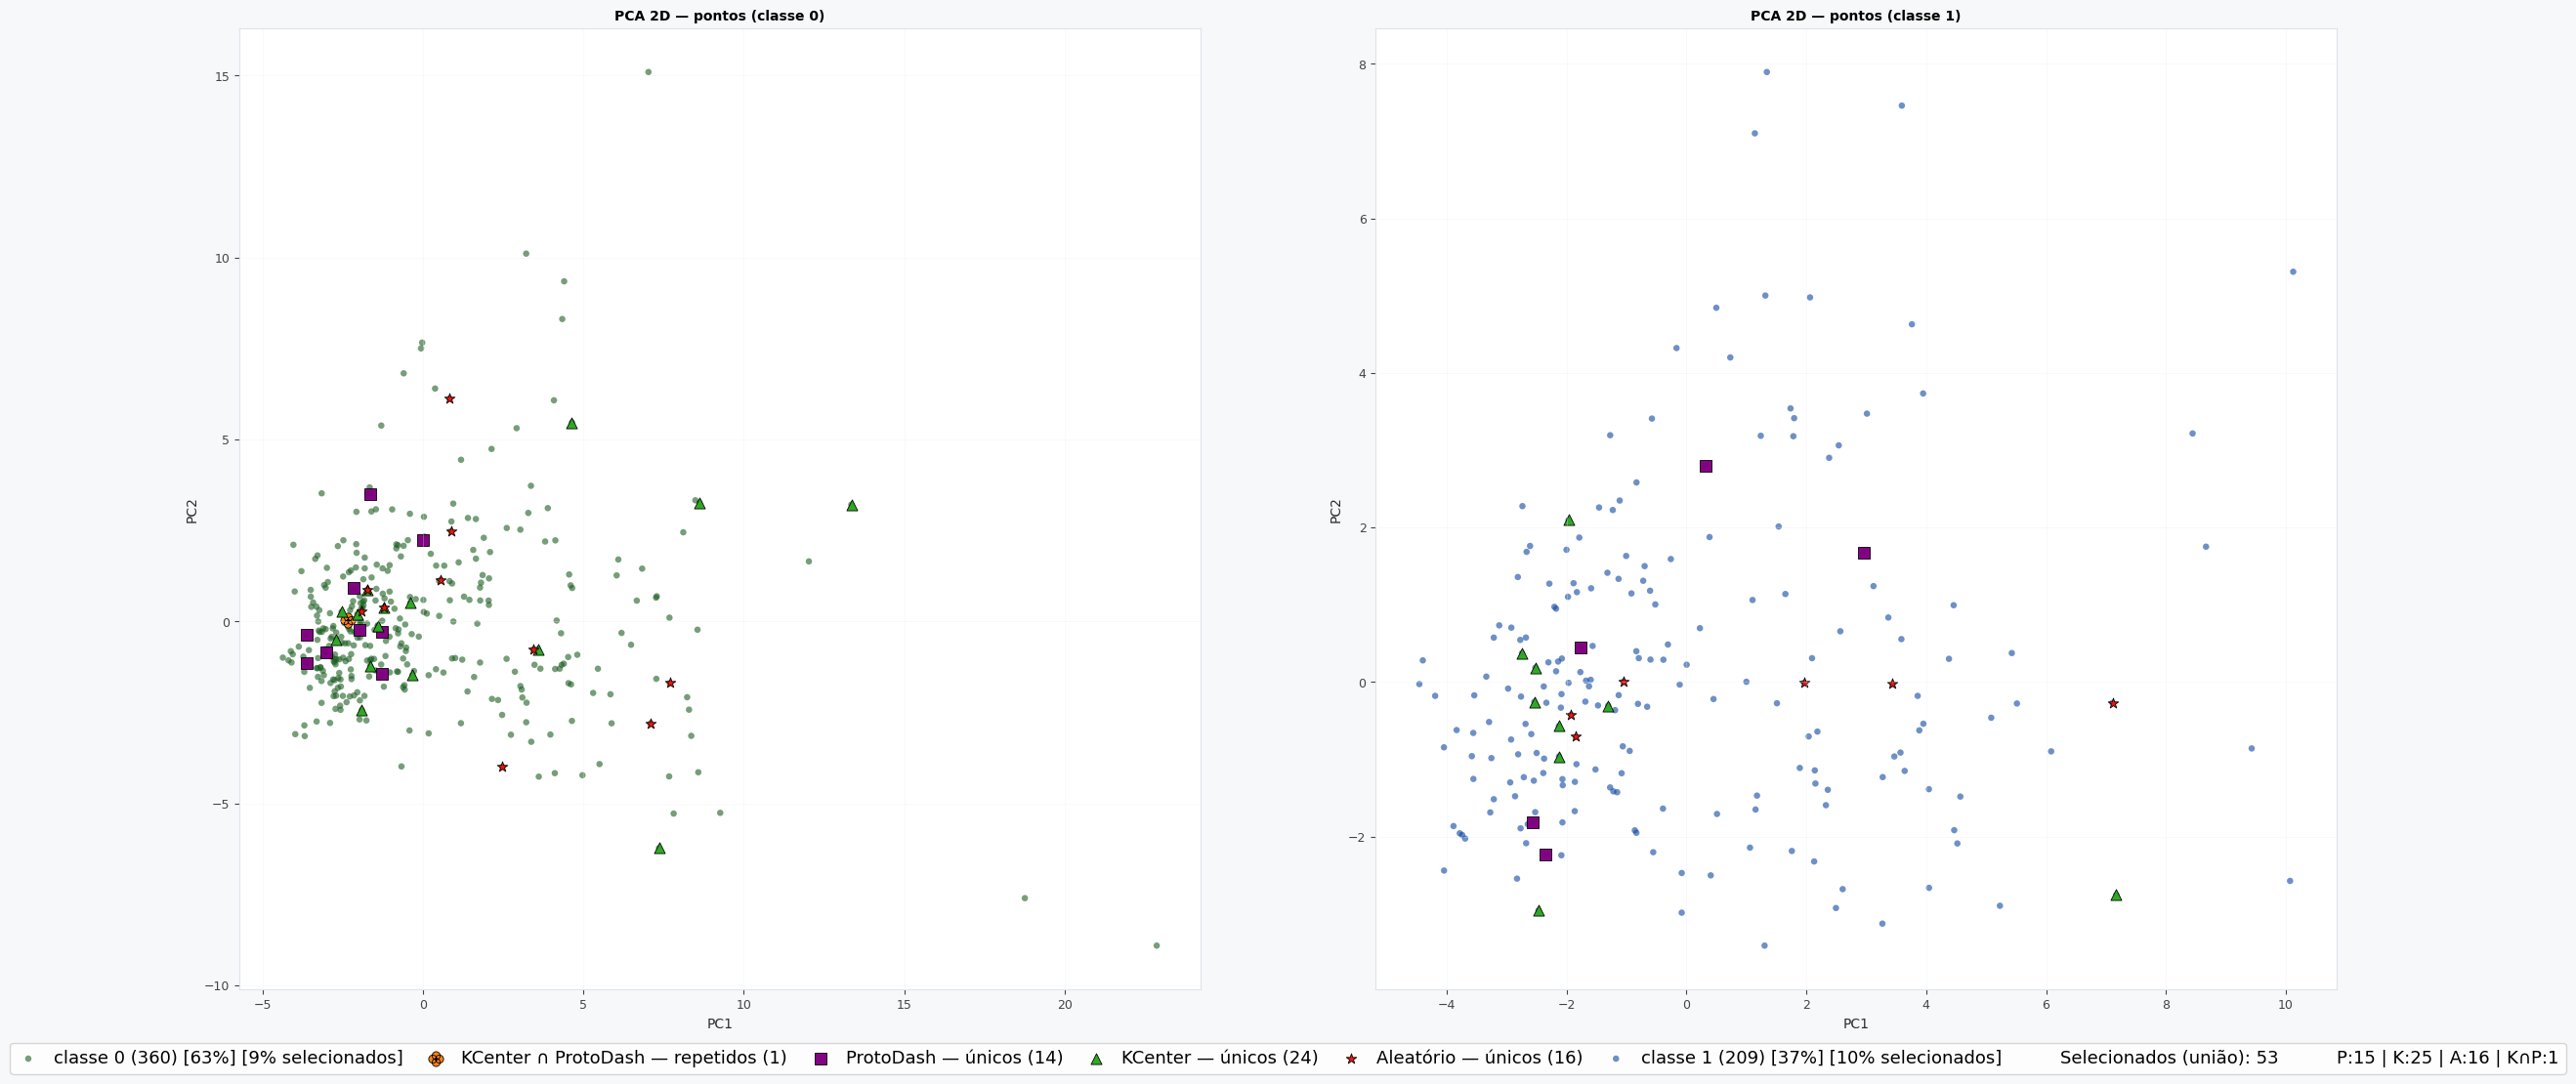

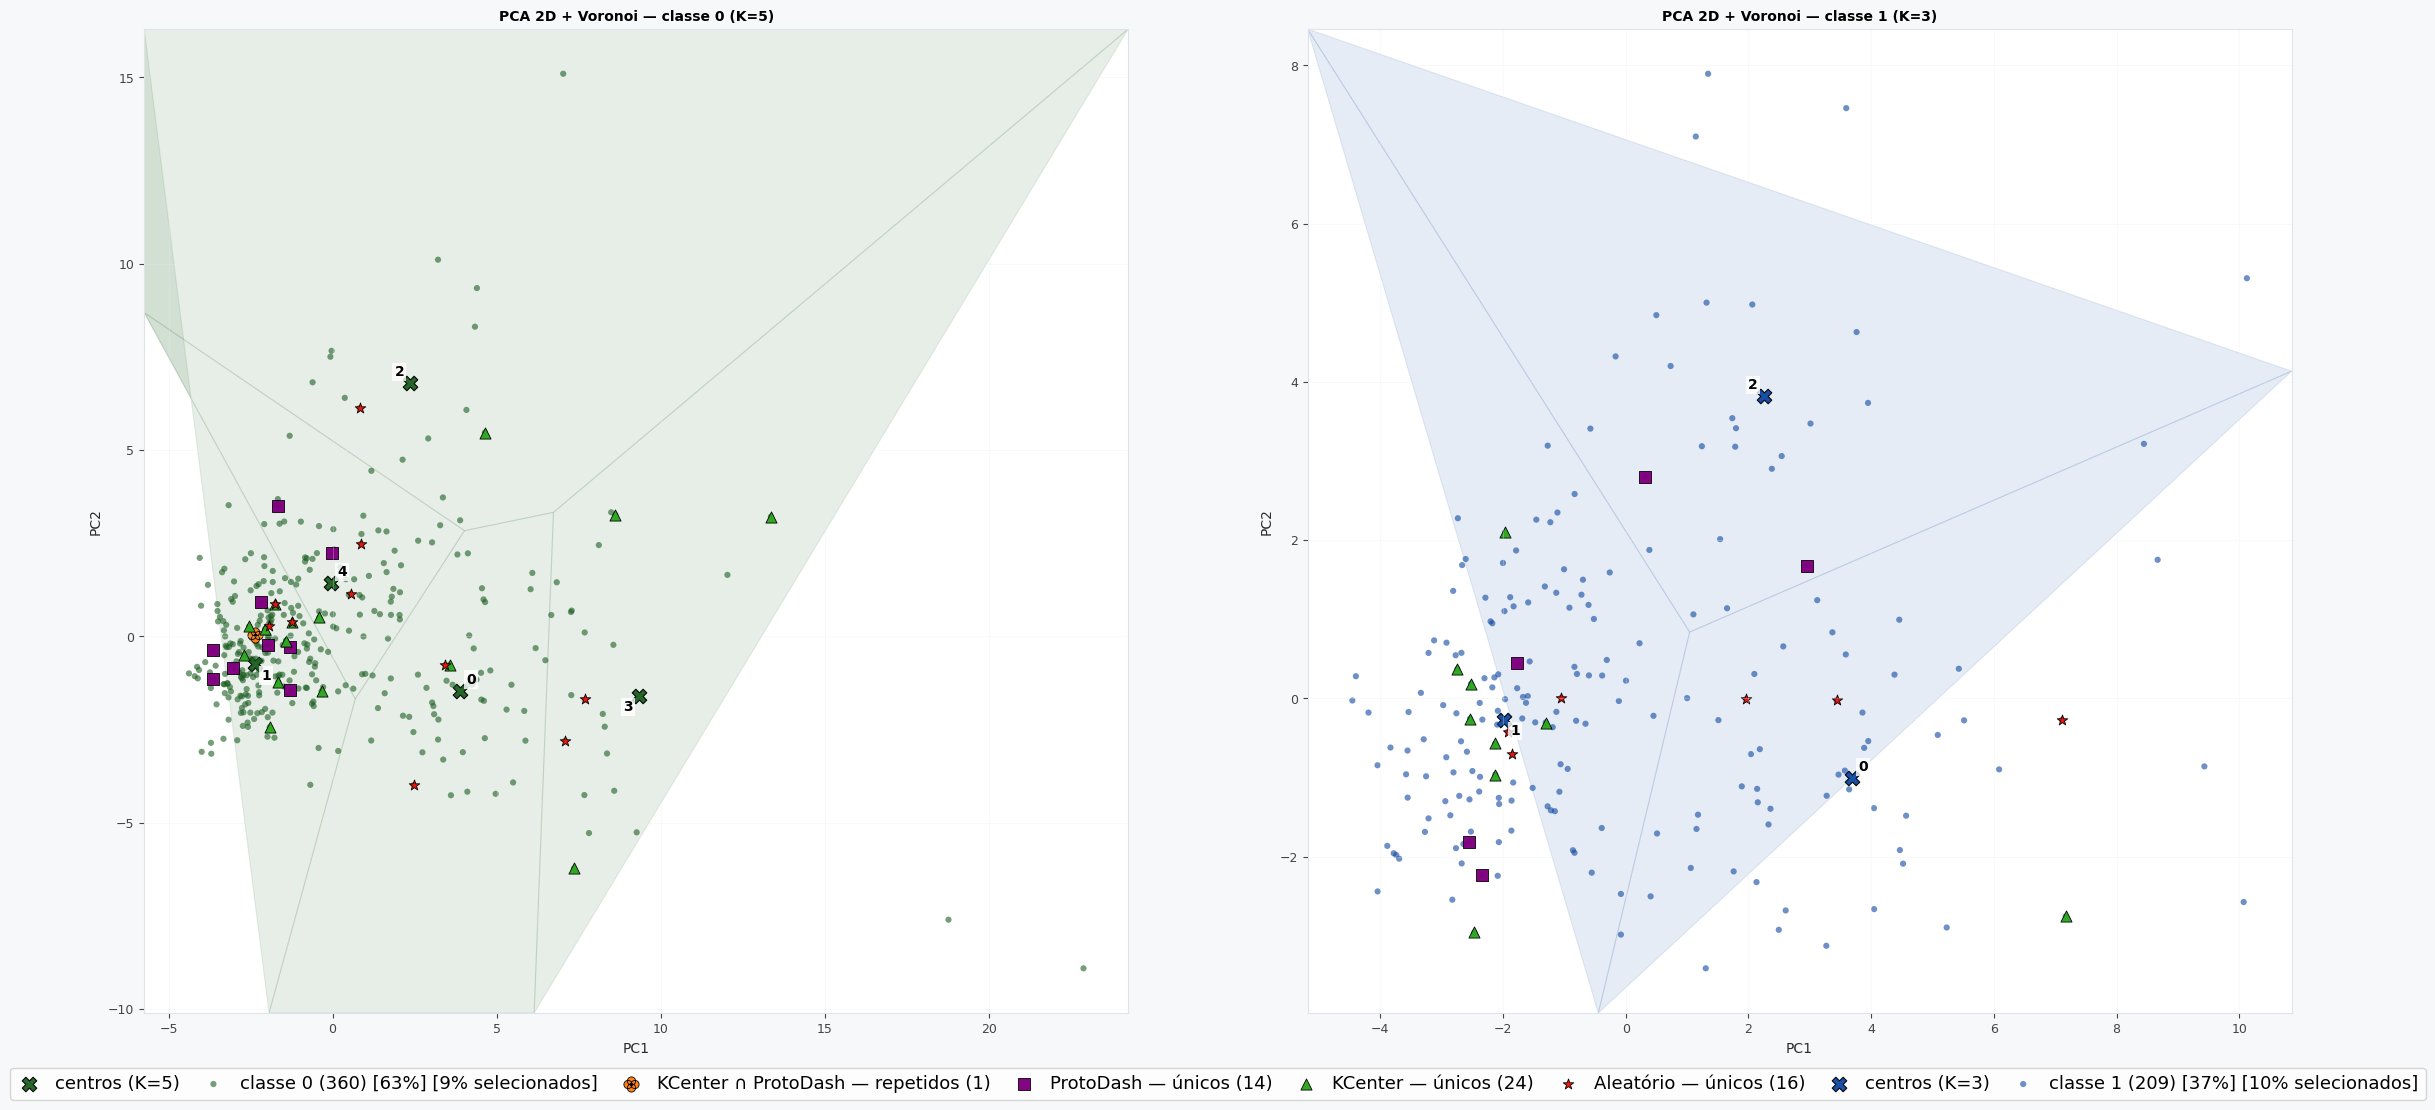

In [22]:
# =========================[ CÉLULA 1 ]=========================
# PCA 2D global — classe 0 e classe 1
# Subplots QUADRADOS maiores (50%/50%) + legenda em uma única linha na base
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.path import Path as MplPath
from matplotlib.transforms import Affine2D
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D

# -------- helpers --------
def legend_totals_plugin(H, L, *, p_ids, k_ids, a_ids, repetidos_ids):
    sel_union = (set(p_ids) | set(k_ids) | set(a_ids))
    total_sel = len(sel_union)
    n_p, n_k, n_a, n_rep = len(p_ids), len(k_ids), len(a_ids), len(repetidos_ids)
    dummy1 = Line2D([], [], linestyle='none', marker=None, label="")
    dummy2 = Line2D([], [], linestyle='none', marker=None, label="")
    H = list(H) + [dummy1, dummy2]
    L = list(L) + [f"Selecionados (união): {total_sel}",
                   f"P:{n_p} | K:{n_k} | A:{n_a} | K∩P:{n_rep}"]
    return H, L

def _to_id_set(selection):
    if selection is None:
        return set()
    if isinstance(selection, dict):
        out = set()
        for v in selection.values():
            out |= set(int(x) for x in v)
        return out
    if isinstance(selection, pd.DataFrame):
        for col in ["idx_global", "idx_global_no_X_test", "index_global", "id_global"]:
            if col in selection.columns:
                return set(int(x) for x in selection[col].tolist())
        return set()
    try:
        return set(int(x) for x in list(selection))
    except Exception:
        return set()

def make_clover_marker(scale=0.65, offset=0.55):
    unit_circle = MplPath.unit_circle()
    tfs = [
        Affine2D().scale(scale).translate(0,  offset),
        Affine2D().scale(scale).translate(0, -offset),
        Affine2D().scale(scale).translate( offset, 0),
        Affine2D().scale(scale).translate(-offset, 0),
    ]
    paths = [tf.transform_path(unit_circle) for tf in tfs]
    return MplPath.make_compound_path(*paths)

# -------- coleta seleções --------
k_ids = _to_id_set(globals().get("ENTRADAS_SELECIONADAS_KCENTER", None))
p_ids = _to_id_set(globals().get("ENTRADAS_SELECIONADAS_PROTODASH", None))
a_obj = (globals().get("ENTRADAS_SELECIONADAS_ALEATORIAS", None))
a_ids = _to_id_set(a_obj)

# -------- conjuntos --------
repetidos_ids = k_ids & p_ids
k_unique = k_ids - repetidos_ids
p_unique = p_ids - repetidos_ids
a_plot = a_ids

# -------- rótulo de classe por índice global --------
# USANDO DF_GLOBAL_NORM COMO BASE E EXCLUINDO APENAS AS EXCLUDE_COLUMNS PARA O PCA
X_all_for_pca = DF_GLOBAL_NORM.drop(columns=EXCLUDE_COLUMNS, errors='ignore')
n = X_all_for_pca.shape[0]
y_cls = np.full(n, -1, dtype=int)
for cls, res in results_by_class.items():
    y_cls[np.asarray(res["idx_global"], dtype=int)] = int(cls)

# -------- PCA global --------
Z_all = PCA(n_components=2, random_state=42).fit_transform(X_all_for_pca.values)
globals()['Z_ALL_PCA'] = Z_all       # exporta para próxima célula
globals()['Y_CLS_VEC'] = y_cls       # exporta para próxima célula

# -------- estética (exportadas p/ próxima célula também) --------
class_colors = {0: "#1b5e20", 1: "#0d47a1"}
alpha_bg = 0.60
color_protodash_unique = "#800080"
color_kcenter_unique   = "#2DA820"
color_random_unique    = "#EF120A"
color_repeat           = "#ff7f0e"
markers = {"protodash": "s", "kcenter": "^", "random": "*"}
clover_marker = make_clover_marker()

globals().update({
    'class_colors': class_colors,
    'alpha_bg': alpha_bg,
    'color_protodash_unique': color_protodash_unique,
    'color_kcenter_unique': color_kcenter_unique,
    'color_random_unique': color_random_unique,
    'color_repeat': color_repeat,
    'markers': markers,
    'clover_marker': clover_marker,
    'k_unique': k_unique,
    'p_unique': p_unique,
    'a_plot': a_plot,
    'repetidos_ids': repetidos_ids
})

# -------- contagens p/ legenda --------
n_p_unique   = len(p_unique)
n_k_unique   = len(k_unique)
n_a_unique   = len(a_plot)
n_repetidos  = len(repetidos_ids)

n_total = int(X_all_for_pca.shape[0])
n_cls0  = int((y_cls == 0).sum())
n_cls1  = int((y_cls == 1).sum())

pct_cls0 = 100.0 * n_cls0 / max(n_total, 1)
pct_cls1 = 100.0 * n_cls1 / max(n_total, 1)

sel_union = (p_ids | k_ids | a_ids)
sel0 = len(sel_union & set(np.where(y_cls == 0)[0]))
sel1 = len(sel_union & set(np.where(y_cls == 1)[0]))
pct_sel0 = 100.0 * sel0 / max(n_cls0, 1)
pct_sel1 = 100.0 * sel1 / max(n_cls1, 1)

labels_map = {
    ("protodash","unique"): f"ProtoDash — únicos ({n_p_unique})",
    ("kcenter","unique")  : f"KCenter — únicos ({n_k_unique})",
    ("random","unique")   : f"Aleatório — únicos ({n_a_unique})",
    ("both","repeat")     : f"KCenter ∩ ProtoDash — repetidos ({n_repetidos})",
}
labels_bg = {
    0: f"classe 0 ({n_cls0}) [{pct_cls0:.0f}%] [{pct_sel0:.0f}% selecionados]",
    1: f"classe 1 ({n_cls1}) [{pct_cls1:.0f}%] [{pct_sel1:.0f}% selecionados]",
}
globals().update({'labels_map': labels_map, 'labels_bg': labels_bg})

def _scatter_ids(ax, ids, marker, color, label, size=64):
    if not ids:
        return
    idx = [i for i in ids if 0 <= i < n]
    if not idx:
        return
    ax.scatter(
        Z_all[idx, 0], Z_all[idx, 1],
        s=size, marker=marker, c=color, edgecolors="k", linewidths=0.6, alpha=0.98, label=label
    )

def _plot_class(ax, cls):
    mask = (y_cls == cls)
    ax.scatter(Z_all[mask, 0], Z_all[mask, 1],
               s=22, alpha=alpha_bg, c=class_colors[cls], edgecolors="none", label=labels_bg[cls])

    cls_set = set(np.where(mask)[0])
    _scatter_ids(ax, repetidos_ids & cls_set, clover_marker, color_repeat, labels_map[("both","repeat")], size=120)
    _scatter_ids(ax, p_unique & cls_set, markers["protodash"], color_protodash_unique, labels_map[("protodash","unique")])
    _scatter_ids(ax, k_unique & cls_set, markers["kcenter"],  color_kcenter_unique,   labels_map[("kcenter","unique")])
    _scatter_ids(ax, a_plot   & cls_set, markers["random"],   color_random_unique,    labels_map[("random","unique")])

    ax.set_title(f"PCA 2D — pontos (classe {cls})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.3)

# -------- figura: subplots QUADRADOS e MAIORES (50%/50%) + legenda 1 linha --------
fig = plt.figure(figsize=(24, 12))
gs = fig.add_gridspec(
    1, 2,
    width_ratios=[1, 1],
    left=0.02, right=0.98, top=0.94, bottom=0.12,
    wspace=0.02
)
ax_left  = fig.add_subplot(gs[0, 0])
ax_right = fig.add_subplot(gs[0, 1])

ax_left.set_box_aspect(1)
ax_right.set_box_aspect(1)

_plot_class(ax_left,  0)
_plot_class(ax_right, 1)

# Guarda limites para manter consistência na próxima célula (Voronoi)
PCA_VIEW = {
    0: {'xlim': ax_left.get_xlim(),  'ylim': ax_left.get_ylim()},
    1: {'xlim': ax_right.get_xlim(), 'ylim': ax_right.get_ylim()}
}
globals()['PCA_VIEW'] = PCA_VIEW

# Coleta e dedup de handles/labels
handles, labels = [], []
for ax in (ax_left, ax_right):
    h, l = ax.get_legend_handles_labels()
    handles += h; labels += l

seen = set(); H = []; L = []
for h, l in zip(handles, labels):
    if l and l not in seen:
        H.append(h); L.append(l); seen.add(l)

# Linhas de totais
H, L = legend_totals_plugin(H, L, p_ids=p_ids, k_ids=k_ids, a_ids=a_ids, repetidos_ids=repetidos_ids)

# Legenda em ÚNICA LINHA, centralizada na base
fig.legend(
    H, L,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.04),
    ncol=len(L),
    frameon=True,
    fontsize=13,
    columnspacing=1.2,
    handlelength=1.3
)

plt.show()
 
# =========================[ CÉLULA 2 — SOMENTE ESTA ETAPA ]=========================
# PCA 2D + Regiões de Voronoi por CLASSE (clusters) + MESMAS marcações
# Usa SILHUET = {classe: k_clusters}. Ex.: {0:3, 1:12)
# Ajuste: numeração dos centros deslocada para não sobrepor o marcador 'X'
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.spatial import Voronoi

# --- util: converter regiões Voronoi infinitas em polígonos finitos (recorte em caixa) ---
def _voronoi_finite_polygons_2d(vor, radius=None):
    if vor.points.shape[1] != 2:
        raise ValueError("Apenas suporte 2D.")
    new_regions = []
    new_vertices = vor.vertices.tolist()

    center = vor.points.mean(axis=0)
    if radius is None:
        radius = vor.points.ptp().max()*2

    all_ridges = {}
    for (p1, p2), (v1, v2) in zip(vor.ridge_points, vor.ridge_vertices):
        all_ridges.setdefault(p1, []).append((p2, v1, v2))
        all_ridges.setdefault(p2, []).append((p1, v1, v2))

    for p1, region_index in enumerate(vor.point_region):
        vertices = vor.regions[region_index]
        if -1 not in vertices:
            new_regions.append(vertices)
            continue

        ridges = all_ridges[p1]
        new_region = [v for v in vertices if v >= 0]

        for p2, v1, v2 in ridges:
            if v2 < 0 or v1 < 0:
                v = v1 if v1 >= 0 else v2
                t = vor.points[p2] - vor.points[p1]
                t /= np.linalg.norm(t)
                n = np.array([-t[1], t[0]])
                midpoint = (vor.points[p1] + vor.points[p2]) / 2
                direction = np.sign(np.dot(midpoint - center, n)) * n
                far_point = vor.vertices[v] + direction * radius
                new_vertices.append(far_point.tolist())
                new_region.append(len(new_vertices) - 1)

        vs = np.asarray([new_vertices[v] for v in new_region])
        c = vs.mean(axis=0)
        ang = np.arctan2(vs[:,1] - c[1], vs[:,0] - c[0])
        new_region = np.array(new_region)[np.argsort(ang)]
        new_regions.append(new_region.tolist())

    return new_regions, np.asarray(new_vertices)

def _clip_poly_to_box(poly, xlim, ylim):
    x0, x1 = xlim; y0, y1 = ylim
    poly = np.asarray(poly).copy()
    poly[:,0] = np.clip(poly[:,0], x0, x1)
    poly[:,1] = np.clip(poly[:,1], y0, y1)
    return poly

# --- parâmetros de clusters por classe ---
SILHUET = globals().get('SILHUET', {})  # ex: {0:3, 1:12}
DEFAULT_K = 3

# --- dados exportados da etapa 1 ---
Z_all   = globals()['Z_ALL_PCA']
y_cls   = globals()['Y_CLS_VEC']
class_colors           = globals()['class_colors']
alpha_bg               = globals()['alpha_bg']
color_protodash_unique = globals()['color_protodash_unique']
color_kcenter_unique   = globals()['color_kcenter_unique']
color_random_unique    = globals()['color_random_unique']
color_repeat           = globals()['color_repeat']
markers                = globals()['markers']
clover_marker          = globals()['clover_marker']
k_unique               = globals()['k_unique']
p_unique               = globals()['p_unique']
a_plot                 = globals()['a_plot']
repetidos_ids          = globals()['repetidos_ids']
labels_map             = globals()['labels_map']
labels_bg              = globals()['labels_bg']
PCA_VIEW               = globals().get('PCA_VIEW', None)

n = Z_all.shape[0]

def _scatter_ids(ax, ids, marker, color, label, size=64):
    if not ids:
        return
    idx = [i for i in ids if 0 <= i < n]
    if not idx:
        return
    ax.scatter(
        Z_all[idx, 0], Z_all[idx, 1],
        s=size, marker=marker, c=color, edgecolors="k", linewidths=0.6, alpha=0.98, label=label
    )

def _plot_class_with_voronoi(ax, cls, xlim=None, ylim=None):
    # dados da classe
    mask = (y_cls == cls)
    pts  = Z_all[mask]
    idx_class = np.where(mask)[0]

    # define K por classe
    try:
        K = int(SILHUET.get(int(cls), DEFAULT_K))
        if K < 1: K = DEFAULT_K
    except Exception:
        K = DEFAULT_K

    # k-means em PCA para obter centros de clusters
    if len(pts) >= K:
        km = KMeans(n_clusters=K, random_state=42, n_init='auto')
        labels = km.fit_predict(pts)
        centers = km.cluster_centers_
    else:
        labels = np.zeros(len(pts), dtype=int)
        centers = pts.mean(axis=0, keepdims=True)

    # Voronoi nos centros
    if centers.shape[0] >= 2:
        vor = Voronoi(centers)
        regions, vertices = _voronoi_finite_polygons_2d(vor)
    else:
        vor = None
        regions, vertices = [], np.empty((0,2))

    # limites (mantém os mesmos da célula 1 se disponíveis)
    if xlim is None or ylim is None:
        xx = Z_all[:,0]; yy = Z_all[:,1]
        pad_x = 0.05 * (xx.max() - xx.min() + 1e-9)
        pad_y = 0.05 * (yy.max() - yy.min() + 1e-9)
        xlim = (xx.min()-pad_x, xx.max()+pad_x)
        ylim = (yy.min()-pad_y, yy.max()+pad_y)

    # desenha polígonos Voronoi preenchidos
    if vor is not None:
        for region in regions:
            polygon = vertices[region]
            polygon = _clip_poly_to_box(polygon, xlim, ylim)
            ax.fill(polygon[:,0], polygon[:,1],
                    facecolor=class_colors[cls], alpha=0.10, edgecolor=class_colors[cls], linewidth=0.8)

        # marca centros
        ax.scatter(centers[:,0], centers[:,1],
                   s=110, c=class_colors[cls], marker='X', edgecolors='k', linewidths=0.8, alpha=0.95, label=f'centros (K={K})')

        # --- rótulos NUMÉRICOS dos centros com DESLOCAMENTO para não sobrepor o 'X' ---
        # offset em pontos (pixels independentes do zoom). Alternamos quadrantes para evitar colisões.
        offsets = [(8, 8), (8, -8), (-8, 8), (-8, -8)]
        for i, (cx, cy) in enumerate(centers):
            dx, dy = offsets[i % len(offsets)]
            ax.annotate(
                f'{i}', xy=(cx, cy), xytext=(dx, dy),
                textcoords='offset points',
                ha='center', va='center',
                fontsize=10, weight='bold', color='k',
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1.5)
            )

    # pontos da classe (fundo)
    ax.scatter(pts[:,0], pts[:,1],
               s=20, alpha=alpha_bg, c=class_colors[cls], edgecolors="none", label=labels_bg[cls])

    # marcações adicionais (repetidos, protodash, kcenter, aleatórios) restringidas à classe
    cls_set = set(idx_class.tolist())
    _scatter_ids(ax, set(repetidos_ids) & cls_set, clover_marker, color_repeat, labels_map[("both","repeat")], size=120)
    _scatter_ids(ax, set(p_unique) & cls_set, markers["protodash"], color_protodash_unique, labels_map[("protodash","unique")])
    _scatter_ids(ax, set(k_unique) & cls_set, markers["kcenter"],  color_kcenter_unique,   labels_map[("kcenter","unique")])
    _scatter_ids(ax, set(a_plot)   & cls_set, markers["random"],   color_random_unique,    labels_map[("random","unique")])

    # estética
    ax.set_title(f"PCA 2D + Voronoi — classe {cls} (K={K})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_box_aspect(1)

# -------- figura (mesma largura/estilo; legenda linha única) --------
fig = plt.figure(figsize=(24, 12))
gs = fig.add_gridspec(
    1, 2,
    width_ratios=[1, 1],
    left=0.02, right=0.98, top=0.94, bottom=0.12,
    wspace=0.02
)
ax_left  = fig.add_subplot(gs[0, 0])
ax_right = fig.add_subplot(gs[0, 1])

# mantém os mesmos limites da célula anterior se existirem
xlim0 = PCA_VIEW.get(0, {}).get('xlim') if PCA_VIEW else None
ylim0 = PCA_VIEW.get(0, {}).get('ylim') if PCA_VIEW else None
xlim1 = PCA_VIEW.get(1, {}).get('xlim') if PCA_VIEW else None
ylim1 = PCA_VIEW.get(1, {}).get('ylim') if PCA_VIEW else None

_plot_class_with_voronoi(ax_left,  0, xlim0, ylim0)
_plot_class_with_voronoi(ax_right, 1, xlim1, ylim1)

# Legenda única linha (coletando de ambos)
handles, labels = [], []
for ax in (ax_left, ax_right):
    h, l = ax.get_legend_handles_labels()
    handles += h; labels += l

seen = set(); H = []; L = []
for h, l in zip(handles, labels):
    if l and l not in seen:
        H.append(h); L.append(l); seen.add(l)

fig.legend(
    H, L,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.04),
    ncol=len(L),
    frameon=True,
    fontsize=13,
    columnspacing=1.2,
    handlelength=1.3
)

plt.show()


📁 Figuras salvas em:
 - ../clusters_reports/xgboost/images/pca_voronoi_duas_classes.png
 - ../clusters_reports/xgboost/images/pca_voronoi_duas_classes.pdf


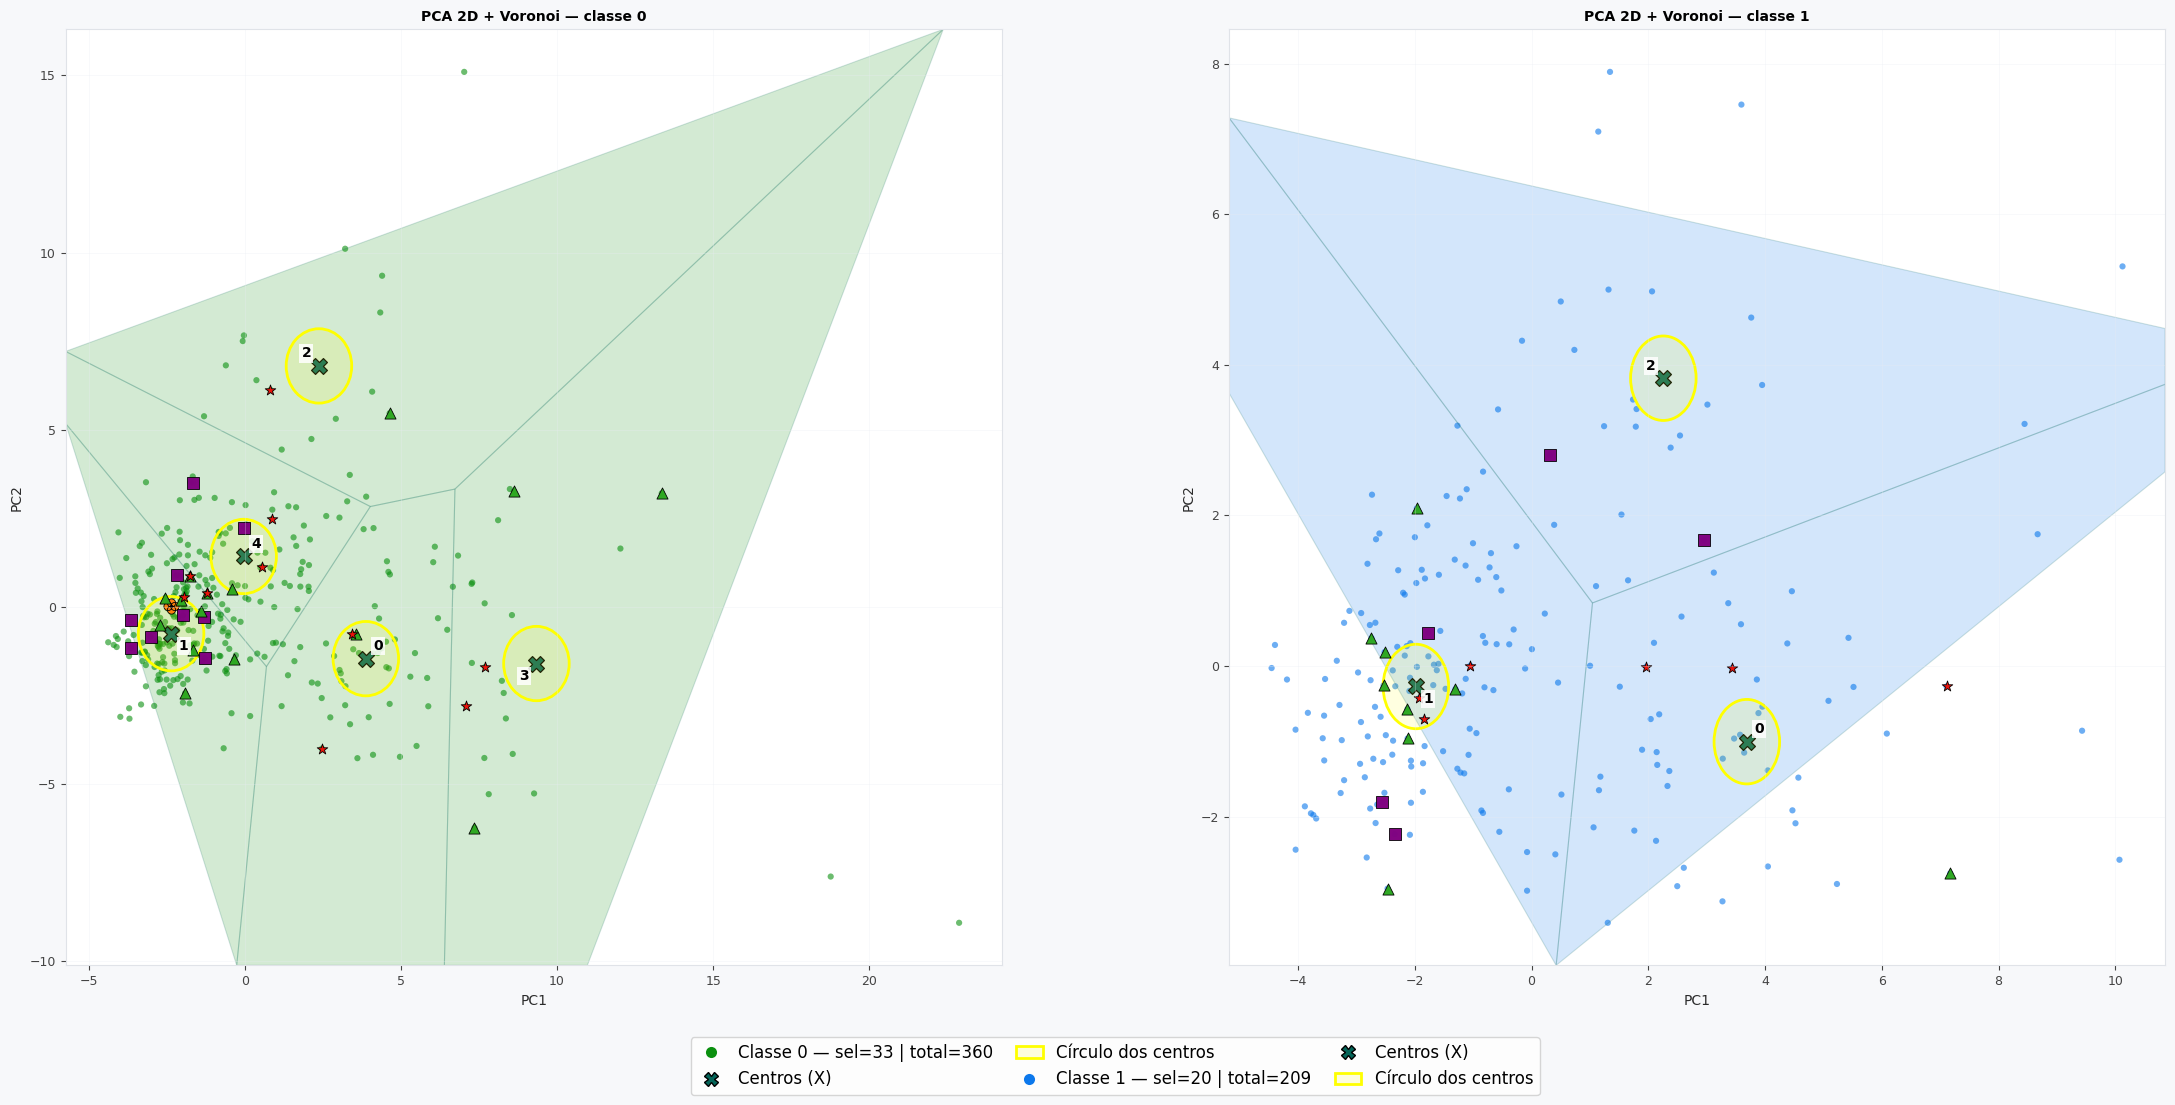

In [23]:
# =========================[ CÉLULA 2 — COMPLETA (corrigida + salva em OUT_IMG) ]=========================
# PCA 2D + Regiões de Voronoi por CLASSE (clusters) + MESMAS marcações
# Ajustes:
# 1) Legenda por CLASSE, com "selecionados" por classe e total da classe.
# 2) Círculo AMARELO translúcido contornando cada centroide (X) + item correspondente na legenda.
# 3) Regiões de cluster PREENCHENDO TODO o quadrado (sem buracos), via recorte Sutherland–Hodgman.
# 4) Usa o esquema de cores/config solicitado:
#    CLUSTER_BG_ALPHA, CLUSTER_LINE_COLOR, MEDOID_COLOR, POINT_COLORS
# 5) Salva as figuras na pasta OUT_IMG já definida no notebook.
# --------------------------------------------------------------------------------------------------------
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Patch
from matplotlib.lines import Line2D
from sklearn.cluster import KMeans
from scipy.spatial import Voronoi

# ======== Parâmetros visuais (usando os definidos globalmente se existirem) ========
CLUSTER_BG_ALPHA   = float(globals().get('CLUSTER_BG_ALPHA', 0.18))
CLUSTER_LINE_COLOR = str(globals().get('CLUSTER_LINE_COLOR', "#056559"))
MEDOID_COLOR       = str(globals().get('MEDOID_COLOR', "#056559"))
POINT_COLORS       = globals().get('POINT_COLORS', {0: "#0B900F", 1: "#0C78EC"})

# ======== Diretórios de saída (já definidos no seu notebook) ========
OUT_IMG = Path(globals().get('OUT_IMG', Path('./images')))
OUT_IMG.mkdir(parents=True, exist_ok=True)

# ======== Dados exportados da CÉLULA 1 ========
Z_all   = globals()['Z_ALL_PCA']     # matriz 2D (PCA)
y_cls   = globals()['Y_CLS_VEC']     # vetor de classes (0/1)
markers       = globals()['markers']
clover_marker = globals()['clover_marker']
k_unique      = globals()['k_unique']
p_unique      = globals()['p_unique']
a_plot        = globals()['a_plot']
repetidos_ids = globals()['repetidos_ids']
labels_map    = globals()['labels_map']
labels_bg     = globals()['labels_bg']
PCA_VIEW      = globals().get('PCA_VIEW', None)
SILHUET       = globals().get('SILHUET', {})   # ex.: {0:3, 1:12}
DEFAULT_K     = 3

# ======== Helpers robustos ========
def _to_id_set_safe(selection):
    """Converte várias formas (dict/list/np.array/DataFrame) em set[int] sem ambiguidade."""
    import pandas as pd
    if selection is None:
        return set()
    # dict de listas
    if isinstance(selection, dict):
        out = set()
        for v in selection.values():
            try:
                out |= set(int(x) for x in np.asarray(list(v)).ravel().tolist())
            except Exception:
                pass
        return out
    # DataFrame com coluna de índice global
    if 'pandas' in str(type(selection)):
        try:
            df = selection
            for col in ["idx_global", "idx_global_no_X_test", "index_global", "id_global"]:
                if col in df.columns:
                    return set(int(x) for x in df[col].tolist())
        except Exception:
            return set()
    # lista/array/iterável simples
    try:
        arr = np.asarray(list(selection)).ravel()
        return set(int(x) for x in arr.tolist())
    except Exception:
        return set()

# Conjuntos de selecionados por fonte (SEM usar "or" com arrays -> evita ValueError)
p_ids = _to_id_set_safe(globals().get("ENTRADAS_SELECIONADAS_PROTODASH", None))
k_ids = _to_id_set_safe(globals().get("ENTRADAS_SELECIONADAS_KCENTER", None))
a_ids = _to_id_set_safe(globals().get("ENTRADAS_SELECIONADAS_ALEATORIAS", None))
sel_union = p_ids | k_ids | a_ids

n = Z_all.shape[0]

def _voronoi_finite_polygons_2d(vor, radius=None):
    """Converte células Voronoi infinitas para polígonos finitos."""
    if vor.points.shape[1] != 2:
        raise ValueError("Apenas suporte 2D.")
    new_regions = []
    new_vertices = vor.vertices.tolist()
    center = vor.points.mean(axis=0)
    if radius is None:
        radius = vor.points.ptp().max() * 2

    all_ridges = {}
    for (p1, p2), (v1, v2) in zip(vor.ridge_points, vor.ridge_vertices):
        all_ridges.setdefault(p1, []).append((p2, v1, v2))
        all_ridges.setdefault(p2, []).append((p1, v1, v2))

    for p1, region_idx in enumerate(vor.point_region):
        verts = vor.regions[region_idx]
        if verts and (-1 not in verts):
            new_regions.append(verts)
            continue

        ridges = all_ridges.get(p1, [])
        new_region = [v for v in (verts or []) if v >= 0]
        for p2, v1, v2 in ridges:
            if v1 < 0 or v2 < 0:
                v = v1 if v1 >= 0 else v2
                t = vor.points[p2] - vor.points[p1]
                norm = np.linalg.norm(t)
                if norm == 0:
                    continue
                t /= norm
                nvec = np.array([-t[1], t[0]])
                midpoint = (vor.points[p1] + vor.points[p2]) / 2
                direction = np.sign(np.dot(midpoint - center, nvec)) * nvec
                far_point = vor.vertices[v] + direction * radius
                new_vertices.append(far_point.tolist())
                new_region.append(len(new_vertices) - 1)

        if len(new_region) == 0:
            continue
        vs = np.asarray([new_vertices[v] for v in new_region])
        c = vs.mean(axis=0)
        ang = np.arctan2(vs[:, 1] - c[1], vs[:, 0] - c[0])
        new_region = np.array(new_region)[np.argsort(ang)]
        new_regions.append(new_region.tolist())

    return new_regions, np.asarray(new_vertices)

# Recorte Sutherland–Hodgman (garante preenchimento total)
def _segment_intersection(a, b, x0, x1, y0, y1):
    ax, ay = a; bx, by = b
    dx, dy = bx - ax, by - ay
    inters = []

    def add_if_in_bounds(x, y):
        if (x0-1e-9) <= x <= (x1+1e-9) and (y0-1e-9) <= y <= (y1+1e-9):
            inters.append([x, y])

    if dx != 0:
        t = (x0 - ax) / dx
        if 0 <= t <= 1: add_if_in_bounds(x0, ay + t * dy)
        t = (x1 - ax) / dx
        if 0 <= t <= 1: add_if_in_bounds(x1, ay + t * dy)
    if dy != 0:
        t = (y0 - ay) / dy
        if 0 <= t <= 1: add_if_in_bounds(ax + t * dx, y0)
        t = (y1 - ay) / dy
        if 0 <= t <= 1: add_if_in_bounds(ax + t * dx, y1)

    return inters[0] if inters else None

def _clip_polygon_to_box(poly, xlim, ylim):
    x0, x1 = xlim; y0, y1 = ylim

    def clip(subjectPolygon, inside_fn):
        outputList = []
        if len(subjectPolygon) == 0:
            return outputList
        s = subjectPolygon[-1]
        for e in subjectPolygon:
            if inside_fn(e):
                if not inside_fn(s):
                    inter = _segment_intersection(s, e, x0, x1, y0, y1)
                    if inter is not None: outputList.append(inter)
                outputList.append(e)
            elif inside_fn(s):
                inter = _segment_intersection(s, e, x0, x1, y0, y1)
                if inter is not None: outputList.append(inter)
            s = e
        return outputList

    def inside_left(p):   return p[0] >= x0
    def inside_right(p):  return p[0] <= x1
    def inside_bottom(p): return p[1] >= y0
    def inside_top(p):    return p[1] <= y1

    poly = np.asarray(poly, dtype=float).tolist()
    for fn in (inside_left, inside_right, inside_bottom, inside_top):
        poly = clip(poly, fn)
        if not poly: break
    return np.asarray(poly, dtype=float)

def _scatter_ids(ax, ids, marker, color, label, size=64):
    if not ids: 
        return
    idx = [i for i in ids if 0 <= i < n]
    if not idx: 
        return
    ax.scatter(
        Z_all[idx, 0], Z_all[idx, 1],
        s=size, marker=marker, c=color,
        edgecolors="k", linewidths=0.6, alpha=0.98, label=label
    )

def _plot_class_with_voronoi(ax, cls, xlim=None, ylim=None):
    # dados da classe
    mask = (y_cls == cls)
    pts  = Z_all[mask]
    idx_class = np.where(mask)[0]
    n_cls = len(idx_class)

    # K da classe (SILHUET) com fallback
    try:
        K = int(SILHUET.get(int(cls), DEFAULT_K))
        if K < 1: K = DEFAULT_K
    except Exception:
        K = DEFAULT_K

    # KMeans para obter centros
    if len(pts) >= max(1, K):
        km = KMeans(n_clusters=max(1, K), random_state=42, n_init='auto')
        labels = km.fit_predict(pts)
        centers = km.cluster_centers_
    else:
        labels = np.zeros(len(pts), dtype=int) if len(pts) else np.array([], dtype=int)
        centers = pts.mean(axis=0, keepdims=True) if len(pts) else np.array([[0.0, 0.0]])

    # Voronoi sobre centros
    if centers.shape[0] >= 2:
        vor = Voronoi(centers)
        regions, vertices = _voronoi_finite_polygons_2d(vor)
    else:
        vor = None
        regions, vertices = [], np.empty((0, 2))

    # limites do plot
    if xlim is None or ylim is None:
        xx = Z_all[:,0]; yy = Z_all[:,1]
        pad_x = 0.05 * (xx.max() - xx.min() + 1e-9)
        pad_y = 0.05 * (yy.max() - yy.min() + 1e-9)
        xlim = (xx.min()-pad_x, xx.max()+pad_x)
        ylim = (yy.min()-pad_y, yy.max()+pad_y)

    # fundo: pontos da classe (cor da classe)
    if len(pts):
        ax.scatter(pts[:,0], pts[:,1],
                   s=20, alpha=0.60,
                   c=POINT_COLORS.get(int(cls), "#999999"),
                   edgecolors="none", label=f"classe {cls} (N={n_cls})")

    # polígonos Voronoi recortados para PREENCHER todo o quadrado
    if vor is not None and len(regions) > 0:
        for region in regions:
            polygon = vertices[region]
            polygon = _clip_polygon_to_box(polygon, xlim, ylim)
            if len(polygon) >= 3:
                ax.fill(
                    polygon[:,0], polygon[:,1],
                    facecolor=POINT_COLORS.get(int(cls), "#999999"),
                    alpha=CLUSTER_BG_ALPHA,
                    edgecolor=CLUSTER_LINE_COLOR,
                    linewidth=0.8
                )

    # centros: X + círculo amarelo translúcido + rótulo deslocado
    if centers.size:
        ax.scatter(
            centers[:,0], centers[:,1],
            s=130, c=MEDOID_COLOR, marker='X', edgecolors='k', linewidths=0.9, alpha=0.95,
            label=f'centros (K={centers.shape[0]})'
        )
        rx = (xlim[1] - xlim[0]); ry = (ylim[1] - ylim[0])
        base_r = 0.035 * max(rx, ry)
        for i, (cx, cy) in enumerate(centers):
            circ = Circle((cx, cy), base_r,
                          facecolor=(1.0, 1.0, 0.0, 0.12),
                          edgecolor='yellow', linewidth=2.0)
            ax.add_patch(circ)
        # rótulos deslocados (não sobrepor o X)
        offsets = [(9, 9), (9, -9), (-9, 9), (-9, -9)]
        for i, (cx, cy) in enumerate(centers):
            dx, dy = offsets[i % len(offsets)]
            ax.annotate(
                f'{i}', xy=(cx, cy), xytext=(dx, dy),
                textcoords='offset points', ha='center', va='center',
                fontsize=10, weight='bold', color='k',
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=1.5)
            )

    # marcações adicionais (limitadas à classe)
    cls_set = set(idx_class.tolist())
    _scatter_ids(ax, set(repetidos_ids) & cls_set, clover_marker, "#ff7f0e", labels_map[("both","repeat")], size=120)
    _scatter_ids(ax, set(p_unique) & cls_set, markers["protodash"], "#800080", labels_map[("protodash","unique")])
    _scatter_ids(ax, set(k_unique) & cls_set, markers["kcenter"],  "#2DA820",   labels_map[("kcenter","unique")])
    _scatter_ids(ax, set(a_plot)   & cls_set, markers["random"],   "#EF120A",   labels_map[("random","unique")])

    # estética final
    ax.set_title(f"PCA 2D + Voronoi — classe {cls}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_box_aspect(1)

# ======== Figura (duas classes lado a lado) ========
fig = plt.figure(figsize=(24, 12))
gs = fig.add_gridspec(
    1, 2,
    width_ratios=[1, 1],
    left=0.02, right=0.98, top=0.94, bottom=0.16,
    wspace=0.02
)
ax_left  = fig.add_subplot(gs[0, 0])
ax_right = fig.add_subplot(gs[0, 1])

# mantém limites da célula 1 (se existirem)
xlim0 = PCA_VIEW.get(0, {}).get('xlim') if PCA_VIEW else None
ylim0 = PCA_VIEW.get(0, {}).get('ylim') if PCA_VIEW else None
xlim1 = PCA_VIEW.get(1, {}).get('xlim') if PCA_VIEW else None
ylim1 = PCA_VIEW.get(1, {}).get('ylim') if PCA_VIEW else None

_plot_class_with_voronoi(ax_left,  0, xlim0, ylim0)
_plot_class_with_voronoi(ax_right, 1, xlim1, ylim1)

# ======== Legenda: UMA LINHA POR CLASSE ========
# contagens "selecionados" por classe e total por classe
sel0 = len(sel_union & set(np.where(y_cls == 0)[0]))
sel1 = len(sel_union & set(np.where(y_cls == 1)[0]))
n0   = int((y_cls == 0).sum())
n1   = int((y_cls == 1).sum())

# proxies por classe (3 colunas: pontos, X, círculo)
proxies = []
labels  = []

p0_pts  = Line2D([], [], linestyle='none', marker='o', markersize=8,
                 markerfacecolor=POINT_COLORS.get(0, "#0B900F"), markeredgecolor='none')
p0_cent = Line2D([], [], linestyle='none', marker='X', markersize=10,
                 markerfacecolor=MEDOID_COLOR, markeredgecolor='k')
p0_ring = Patch(facecolor=(1.0,1.0,0.0,0.12), edgecolor='yellow', linewidth=2.0)
proxies += [p0_pts, p0_cent, p0_ring]
labels  += [f"Classe 0 — sel={sel0} | total={n0}", "Centros (X)", "Círculo dos centros"]

p1_pts  = Line2D([], [], linestyle='none', marker='o', markersize=8,
                 markerfacecolor=POINT_COLORS.get(1, "#0C78EC"), markeredgecolor='none')
p1_cent = Line2D([], [], linestyle='none', marker='X', markersize=10,
                 markerfacecolor=MEDOID_COLOR, markeredgecolor='k')
p1_ring = Patch(facecolor=(1.0,1.0,0.0,0.12), edgecolor='yellow', linewidth=2.0)
proxies += [p1_pts, p1_cent, p1_ring]
labels  += [f"Classe 1 — sel={sel1} | total={n1}", "Centros (X)", "Círculo dos centros"]

fig.legend(
    proxies, labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.045),
    ncol=3,  # 3 itens por linha (pontos, X, círculo)
    frameon=True,
    fontsize=12,
    columnspacing=1.4,
    handlelength=1.6
)

# ======== Salvar figuras ========
fname_png = OUT_IMG / "pca_voronoi_duas_classes.png"
fname_pdf = OUT_IMG / "pca_voronoi_duas_classes.pdf"
fig.savefig(fname_png, dpi=140, bbox_inches="tight")
fig.savefig(fname_pdf, dpi=200, bbox_inches="tight")
print(f"📁 Figuras salvas em:\n - {fname_png}\n - {fname_pdf}")

plt.show()


In [24]:
# Geração de PDF resumo (folha de rosto + sumário) para os clusters gerados acima
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime
import math
import textwrap
import re

pdf_dir = Path(globals().get('OUT_PDF', Path('.')))
pdf_dir.mkdir(parents=True, exist_ok=True)
pdf_path = pdf_dir / 'RF_CLUSTERS_SUMMARY.pdf'

results_dirs = []
for key in ('RESULTS_DIR', 'OUT_CSV', 'OUT_BASE'):
    base = globals().get(key)
    if not base:
        continue
    try:
        candidate = Path(base)
    except TypeError:
        try:
            candidate = Path(str(base))
        except Exception:
            candidate = None
    if candidate and candidate not in results_dirs:
        results_dirs.append(candidate)
if 'OUT_IMG' in globals():
    try:
        candidate = Path(globals()['OUT_IMG'])
        if candidate not in results_dirs:
            results_dirs.append(candidate)
    except Exception:
        pass
parent_dir = pdf_dir.parent
if parent_dir not in results_dirs:
    results_dirs.append(parent_dir)

def _safe_df(name):
    obj = globals().get(name)
    return obj.copy() if isinstance(obj, pd.DataFrame) else pd.DataFrame()

def _load_if_empty(df, candidates):
    if not df.empty:
        return df
    for cand in candidates:
        if not cand:
            continue
        try:
            cand_path = Path(cand)
        except TypeError:
            try:
                cand_path = Path(str(cand))
            except Exception:
                continue
        search_paths = []
        if cand_path.is_absolute():
            search_paths.append(cand_path)
        else:
            search_paths.extend(base / cand_path for base in results_dirs)
        for path in search_paths:
            try:
                if path.exists() and path.is_file():
                    return pd.read_csv(path)
            except Exception:
                continue
    return df

def _collect_file_summary(extensions):
    extensions = {ext.lower().lstrip('.') for ext in extensions if ext}
    if not extensions:
        return pd.DataFrame()
    rows = []
    seen = set()
    for base in results_dirs:
        try:
            base_path = Path(base)
        except TypeError:
            continue
        if not base_path.exists():
            continue
        for path in base_path.rglob('*'):
            if not path.is_file():
                continue
            suffix = path.suffix.lower().lstrip('.')
            if suffix not in extensions:
                continue
            if path in seen:
                continue
            seen.add(path)
            try:
                stat = path.stat()
            except OSError:
                continue
            try:
                rel_parent = path.parent.relative_to(base_path)
                rel_parent_str = str(rel_parent) if str(rel_parent) != '.' else '.'
            except ValueError:
                rel_parent_str = str(path.parent)
            rows.append({
                'arquivo': path.name,
                'pasta': rel_parent_str,
                'tamanho_kb': round(stat.st_size / 1024.0, 1),
                'modificado_em': datetime.fromtimestamp(stat.st_mtime).strftime('%Y-%m-%d %H:%M'),
                'full_path': str(path)
            })
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values(['pasta', 'arquivo']).reset_index(drop=True)

def _pair_key(name):
    lower = name.lower()
    lower = re.sub(r'classe[\s_-]*0', 'classe *', lower)
    lower = re.sub(r'classe[\s_-]*1', 'classe *', lower)
    lower = re.sub(r'class[\s_-]*0', 'class *', lower)
    lower = re.sub(r'class[\s_-]*1', 'class *', lower)
    lower = re.sub(r'c[\s_-]*0', 'c *', lower)
    lower = re.sub(r'c[\s_-]*1', 'c *', lower)
    return lower

def _has_class_zero(name):
    return bool(re.search(r'classe[\s_-]*0|class[\s_-]*0|c[\s_-]*0', name))

def _has_class_one(name):
    return bool(re.search(r'classe[\s_-]*1|class[\s_-]*1|c[\s_-]*1', name))

def _group_image_entries(entries):
    pairs = []
    singles = []
    used = set()
    for idx, entry in enumerate(entries):
        if idx in used:
            continue
        name_lower = entry['name'].lower()
        if _has_class_zero(name_lower) or _has_class_one(name_lower):
            key = _pair_key(entry['name'])
            candidate = None
            for j, other in enumerate(entries):
                if j == idx or j in used:
                    continue
                if _pair_key(other['name']) != key:
                    continue
                other_lower = other['name'].lower()
                cond = (_has_class_zero(name_lower) and _has_class_one(other_lower)) or (_has_class_one(name_lower) and _has_class_zero(other_lower))
                if cond:
                    candidate = j
                    break
            if candidate is not None:
                used.update({idx, candidate})
                ordered = sorted([entry, entries[candidate]], key=lambda e: e['name'])
                pairs.append(ordered)
                continue
        used.add(idx)
        singles.append(entry)
    return pairs, singles

def _image_page(pdf, entries, title, landscape=True):
    if not entries:
        return
    cols = len(entries)
    figsize = (11.69, 8.27) if landscape else (8.27, 11.69)
    fig, axes = plt.subplots(1, cols, figsize=figsize)
    if cols == 1:
        axes = [axes]
    for ax, entry in zip(axes, entries):
        try:
            img = mpimg.imread(str(entry['path']))
            ax.imshow(img)
            ax.axis('off')
        except Exception:
            ax.text(0.5, 0.5, 'Erro ao carregar imagem', ha='center', va='center', fontsize=10)
            ax.axis('off')
        subtitle_parts = [entry.get('name', ''), entry.get('pasta', '')]
        subtitle = ' — '.join(part for part in subtitle_parts if part)
        if subtitle:
            ax.set_title(subtitle, fontsize=10)
    if title:
        fig.suptitle(title, fontsize=14, fontweight='bold')
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

def _text_page(pdf, title, lines, figsize=(8.27, 11.69), fontsize=11):
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis('off')
    ax.set_title(title, pad=20, fontsize=16, fontweight='bold')
    wrapped = []
    for line in lines:
        wrapped_lines = textwrap.wrap(str(line), width=95) or ['']
        wrapped.extend(wrapped_lines)
    ax.text(0, 1, '\n'.join(wrapped), ha='left', va='top', fontsize=fontsize, family='monospace')
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

def _table_pages(pdf, df, title, max_rows=24, landscape=True, font_size=8):
    if df.empty:
        return
    df = df.copy()
    df.replace({np.nan: ''}, inplace=True)
    total = len(df)
    pages = max(1, math.ceil(total / max_rows))
    figsize = (11.69, 8.27) if landscape else (8.27, 11.69)
    for page in range(pages):
        subset = df.iloc[page * max_rows:(page + 1) * max_rows]
        fig, ax = plt.subplots(figsize=figsize)
        ax.axis('off')
        ax.set_title(f"{title} (pagina {page + 1}/{pages})", pad=20, fontsize=14, fontweight='bold')
        table = ax.table(cellText=subset.values, colLabels=list(subset.columns), loc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(font_size)
        table.scale(1.0, 1.1 if font_size <= 8 else 1.0)
        pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig)

df_cluster = _safe_df('df_cluster_metrics')
df_cluster = _load_if_empty(df_cluster, [globals().get('CSV_CLUSTER'), 'protodash_repr_por_cluster.csv'])
df_cluster_view = _safe_df('df_cluster_metrics_view')
if df_cluster_view.empty and not df_cluster.empty:
    df_cluster_view = df_cluster.copy()
df_resumo = _safe_df('df_resumo_cobertura')
df_resumo = _load_if_empty(df_resumo, ['resumo_cobertura_requirements.csv', globals().get('df_resumo_path')])
df_diag = _safe_df('df_diag')
df_diag = _load_if_empty(df_diag, ['diagnostico_requirements.csv', globals().get('df_diag_path')])
df_resumo_sil = _safe_df('df_resumo_silhueta')
df_resumo_sil = _load_if_empty(df_resumo_sil, ['resumo_silhueta_usado_vs_sugerido.csv','resumo_silhueta_usado_vs_sugerido_recomendado.csv','resumo_silhueta_usado_vs_sugerido_usuario.csv'])
df_elbow_rec = _safe_df('df_resumo_elbow_rec')
df_elbow_rec = _load_if_empty(df_elbow_rec, ['resumo_elbow_usado_vs_sugerido_recomendado.csv'])
df_elbow_user = _safe_df('df_resumo_elbow_user')
df_elbow_user = _load_if_empty(df_elbow_user, ['resumo_elbow_usado_vs_sugerido_usuario.csv'])
df_m_needed = _safe_df('df_m_needed')
df_m_needed = _load_if_empty(df_m_needed, ['kcenter_m_necessario_por_cluster_por_meta.csv'])
csv_summary_df = _collect_file_summary({'.csv'})
img_summary_df = _collect_file_summary({'.png', '.jpg', '.jpeg', '.svg', '.webp'})

with PdfPages(pdf_path) as pdf:
    now_str = datetime.now().strftime('%Y-%m-%d %H:%M')
    cover_lines = [
        f'Data de geracao: {now_str}',
        'Notebook: RF_Cluster_from_RF_predictions.ipynb',
        f'CSV treino: {CSV_TRAIN_PATH}',
        f'CSV teste : {CSV_TEST_PATH}',
        f'Coluna alvo/base: {TARGET_COLUMN}',
        f'Clusters por classe: {N_CLUSTERS}',
        f'Threshold de decisao: {THRESHOLD}',
        f'Dados normalizados previamente?: {DATASET_NORMALIZED}',
        f'Metodo de normalizacao: {NORMALIZED_METHOD}',
        'Diretorios de saida:',
        f'  CSV : {OUT_CSV}',
        f'  IMG : {OUT_IMG}',
        f'  PDF : {OUT_PDF}',
    ]
    _text_page(pdf, 'Relatorio de Clusters - Random Forest', cover_lines)

    total_clusters = int(df_cluster.shape[0]) if not df_cluster.empty else 0
    total_protos = int(df_cluster['m_protos'].sum()) if 'm_protos' in df_cluster.columns else 0
    avaliacao_counts = df_cluster['avaliacao'].value_counts().to_dict() if 'avaliacao' in df_cluster.columns else {}
    classe_counts = df_cluster.groupby('classe')['cluster'].nunique().to_dict() if (not df_cluster.empty and 'cluster' in df_cluster.columns) else {}
    metrics_rows = []
    results_dict = globals().get('results_by_class', {})
    if isinstance(results_dict, dict):
        for cls, info in results_dict.items():
            metrics = info.get('metrics', {}) if isinstance(info, dict) else {}
            labels = info.get('labels', []) if isinstance(info, dict) else []
            metrics_rows.append({
                'classe': cls,
                'silhouette': metrics.get('silhouette'),
                'davies_bouldin': metrics.get('davies_bouldin'),
                'calinski_harabasz': metrics.get('calinski_harabasz'),
                'n_clusters_detectados': len(np.unique(labels)) if hasattr(labels, '__len__') else np.nan
            })
    metrics_df = pd.DataFrame(metrics_rows)
    summary_lines = [
        f'Total de clusters avaliados: {total_clusters}',
        f'Total de prototipos selecionados: {total_protos}',
    ]
    if classe_counts:
        summary_lines.append('Clusters unicos por classe: ' + ', '.join(f'{cls}: {cnt}' for cls, cnt in classe_counts.items()))
    if avaliacao_counts:
        summary_lines.append('Avaliacoes (BOM/OK/RUIM): ' + ', '.join(f'{k}: {v}' for k, v in avaliacao_counts.items()))
    summary_lines.append(f'PDF salvo em: {pdf_path}')
    _text_page(pdf, 'Sumario Geral', summary_lines, figsize=(11.69, 8.27), fontsize=10)

    if not metrics_df.empty:
        _table_pages(pdf, metrics_df.round(4), 'Metricas por classe', max_rows=18, landscape=True, font_size=8)
    _table_pages(pdf, df_resumo.round(3), 'Resumo de cobertura por cluster', max_rows=18, landscape=True, font_size=8)
    _table_pages(pdf, df_diag.round(3), 'Diagnostico de requisitos', max_rows=18, landscape=True, font_size=8)
    _table_pages(pdf, df_resumo_sil.round(3), 'Resumo de silhueta (recomendado vs usuario)', max_rows=18, landscape=True, font_size=8)
    _table_pages(pdf, df_elbow_rec.round(3), 'Resumo elbow recomendado', max_rows=18, landscape=True, font_size=8)
    _table_pages(pdf, df_elbow_user.round(3), 'Resumo elbow informado pelo usuario', max_rows=18, landscape=True, font_size=8)
    _table_pages(pdf, df_cluster_view.round(4), 'Metricas principais por cluster', max_rows=12, landscape=True, font_size=8)

    if not df_cluster_view.empty and 'analise' in df_cluster_view.columns:
        analise_df = df_cluster_view[['classe', 'cluster', 'avaliacao', 'analise']].copy()
        _table_pages(pdf, analise_df, 'Analises textuais por cluster', max_rows=14, landscape=True, font_size=8)

    if not df_resumo.empty:
        if 'ganho_compactacao_%' not in df_resumo.columns and 'r_percent_%' in df_resumo.columns:
            try:
                df_resumo['ganho_compactacao_%'] = 100.0 - df_resumo['r_percent_%']
            except Exception:
                df_resumo['ganho_compactacao_%'] = np.nan
        destaque_cols = ['classe', 'cluster', 'percentual_selecionados_%', 'ganho_compactacao_%', 'observacao']
        disponiveis = [c for c in destaque_cols if c in df_resumo.columns]
        if disponiveis:
            destaques = df_resumo[disponiveis].copy()
            for col in destaque_cols:
                if col not in destaques.columns:
                    destaques[col] = np.nan
            destaques = destaques[destaque_cols]
            _table_pages(pdf, destaques, 'Cobertura - destaques principais', max_rows=16, landscape=True, font_size=8)

    if not df_cluster.empty and 'avaliacao' in df_cluster.columns:
        agg_map = {'m_protos': 'sum'}
        if 'N_eff (↑)' in df_cluster.columns:
            agg_map['N_eff (↑)'] = 'mean'
        agg_df = df_cluster.groupby(['classe', 'avaliacao']).agg(agg_map).reset_index()
        if 'N_eff (↑)' in agg_df.columns:
            agg_df.rename(columns={'N_eff (↑)': 'N_eff_medio'}, inplace=True)
        _table_pages(pdf, agg_df.round(3), 'Agrupamento classe x avaliacao', max_rows=18, landscape=True, font_size=8)

    if not df_m_needed.empty:
        _table_pages(pdf, df_m_needed.round(2), 'M necessario por cluster alvo', max_rows=18, landscape=True, font_size=8)

    if not csv_summary_df.empty:
        csv_table = csv_summary_df.drop(columns=['full_path']) if 'full_path' in csv_summary_df.columns else csv_summary_df
        _table_pages(pdf, csv_table, 'Sumario de arquivos CSV', max_rows=25, landscape=True, font_size=8)
    if not img_summary_df.empty:
        img_table = img_summary_df.drop(columns=['full_path']) if 'full_path' in img_summary_df.columns else img_summary_df
        _table_pages(pdf, img_table, 'Sumario de imagens geradas', max_rows=25, landscape=True, font_size=8)
        image_entries = []
        for _, row in img_summary_df.iterrows():
            full_path = row.get('full_path')
            if not full_path:
                continue
            path = Path(full_path)
            if not path.exists():
                continue
            image_entries.append({
                'path': path,
                'name': row.get('arquivo', path.name),
                'pasta': row.get('pasta', '')
            })
        if image_entries:
            pairs, singles = _group_image_entries(image_entries)
            for pair in pairs:
                pair_title = f"Comparativo: {pair[0]['name']} vs {pair[1]['name']}"
                _image_page(pdf, pair, pair_title, landscape=True)
            for single in singles:
                single_title = single['name']
                _image_page(pdf, [single], single_title, landscape=False)

print(f'PDF resumo gerado em: {pdf_path}')

PDF resumo gerado em: ../clusters_reports/xgboost/pdf/RF_CLUSTERS_SUMMARY.pdf
